# 🧬 Multimodal Radiogenomics: MRI + Genomics for Brain Tumor Grading
**Debasish Mondal — BT23CSE108 | Yukt Goyal — BT23CSE112**  


In [1]:
# ========================================
# 1. SETUP & ENVIRONMENT (RUN AFTER RESTART)
# ========================================

!pip install nibabel SimpleITK grad-cam -q

import os
import tarfile
import random
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import nibabel as nib

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.models as models
import torchvision.transforms as transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix

# ----------------------------------------
# Device configuration
# ----------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: None")

# ----------------------------------------
# Reproducibility
# ----------------------------------------

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    import torch.backends.cudnn as cudnn

    cudnn.deterministic = True
    cudnn.benchmark = False

seed_everything()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 52.3 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
PyTorch: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4


## 🔄 Section 2: Session Recovery
> Run this every time after notebook restart. Auto re-extracts BraTS and rebuilds labels if needed.

In [2]:
#RUN THESE EVERYTHIME AFTER RESTART
import os
import tarfile

BRATS_ROOT = "/kaggle/working/brats2021"

# Re-extract BraTS if session reset
if not os.path.exists(BRATS_ROOT) or len(os.listdir(BRATS_ROOT)) < 100:
    print("BraTS data not found — re-extracting...")
    os.makedirs(BRATS_ROOT, exist_ok=True)
    tar_path = "/kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_Training_Data.tar"
    with tarfile.open(tar_path, 'r') as tar:
        tar.extractall(BRATS_ROOT)
    print("Re-extraction done!")
else:
    print(f"✅ BraTS data ready — {len(os.listdir(BRATS_ROOT))} patients found")

# Re-build labels if session reset
labels_path = "/kaggle/working/labels_full.csv"
if not os.path.exists(labels_path):
    print("Labels not found — rebuilding...")
    import pandas as pd
    brats_patients = sorted([p for p in os.listdir(BRATS_ROOT) if p.startswith('BraTS')])
    brats_ids = [int(p.split('_')[1]) for p in brats_patients]
    df_full = pd.DataFrame({'BraTS21ID': brats_ids, 'patient_folder': brats_patients})
    df_full['tumor_type'] = df_full['BraTS21ID'].apply(lambda x: 'GBM' if x < 1000 else 'LGG')
    df_full['grade'] = df_full['tumor_type'].apply(lambda x: 2 if x == 'GBM' else 1)
    df_full['idh'] = df_full['tumor_type'].apply(lambda x: 0 if x == 'GBM' else 1)
    rsna = pd.read_csv("/kaggle/input/competitions/rsna-miccai-brain-tumor-radiogenomic-classification/train_labels.csv")
    df_full = df_full.merge(rsna, on='BraTS21ID', how='left')
    df_full.rename(columns={'MGMT_value': 'mgmt'}, inplace=True)
    df_full.to_csv(labels_path, index=False)
    print("Labels rebuilt!")
else:
    df_full = pd.read_csv(labels_path)
    print(f"✅ Labels ready — {len(df_full)} patients")

BraTS data not found — re-extracting...


/tmp/ipykernel_55/163293049.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(BRATS_ROOT)


Re-extraction done!
Labels not found — rebuilding...
Labels rebuilt!


## 🧠 Section 3: Preprocessing Pipeline
Seg-mask guided slice selection — tumor center varies per patient (EDA confirmed).

In [3]:
# ── CELL 3: PREPROCESSING — load_patient_slice() ─────────────────────────────
# RUN THESE EVERY TIME AFTER RESTART
import cv2
import numpy as np

def load_patient_slice(patient_dir, patient_id, slice_idx=None):
    modalities = ['t1', 't1ce', 't2', 'flair']
    channels = []

    # SMARTER SLICE SELECTION — use seg mask to find tumor center
    if slice_idx is None:
        seg_path = f"{patient_dir}/{patient_id}_seg.nii.gz"
        if os.path.exists(seg_path):
            seg = nib.load(seg_path).get_fdata()
            tumor_slices = np.where(seg.sum(axis=(0, 1)) > 0)[0]
            if len(tumor_slices) > 0:
                # Pick middle of actual tumor extent
                slice_idx = int(tumor_slices[len(tumor_slices) // 2])
            else:
                slice_idx = 80  # EDA-confirmed fallback
        else:
            slice_idx = 80

    for mod in modalities:
        path = f"{patient_dir}/{patient_id}_{mod}.nii.gz"
        vol = nib.load(path).get_fdata()
        slc = vol[:, :, slice_idx].astype(np.float32)

        # Z-score normalize using only non-zero (brain) voxels
        mask = slc > 0
        if mask.sum() > 0:
            slc[mask] = (slc[mask] - slc[mask].mean()) / (slc[mask].std() + 1e-8)

        # Resize to 224x224
        slc = cv2.resize(slc, (224, 224))
        channels.append(slc)

    return np.stack(channels, axis=0)


# ── VERIFY: show which slice was selected per patient ────────────────────────
test_patients = [
    "BraTS2021_00000",  # GBM
    "BraTS2021_01000",  # LGG
    "BraTS2021_01100",  # LGG
]

print(f"{'Patient':<25} {'Type':<6} {'Seg Slice Selected':<20} {'Old (fixed 80)'}")
print("-" * 65)
for pid in test_patients:
    pdir = f"{BRATS_ROOT}/{pid}"
    seg = nib.load(f"{pdir}/{pid}_seg.nii.gz").get_fdata()
    tumor_slices = np.where(seg.sum(axis=(0, 1)) > 0)[0]
    if len(tumor_slices) > 0:
        smart_idx = int(tumor_slices[len(tumor_slices) // 2])
    else:
        smart_idx = 80
    ptype = "GBM" if int(pid.split("_")[1]) < 1000 else "LGG"
    print(f"{pid:<25} {ptype:<6} {smart_idx:<20} 80")

# ── TEST OUTPUT SHAPE ────────────────────────────────────────────────────────
tensor = load_patient_slice(f"{BRATS_ROOT}/BraTS2021_00000", "BraTS2021_00000")
print("\nOutput shape:", tensor.shape)
print("Channel 0 (T1)   — min:", tensor[0].min().round(3), "max:", tensor[0].max().round(3))
print("Channel 1 (T1ce) — min:", tensor[1].min().round(3), "max:", tensor[1].max().round(3))
print("Channel 2 (T2)   — min:", tensor[2].min().round(3), "max:", tensor[2].max().round(3))
print("Channel 3 (FLAIR)— min:", tensor[3].min().round(3), "max:", tensor[3].max().round(3))

Patient                   Type   Seg Slice Selected   Old (fixed 80)
-----------------------------------------------------------------
BraTS2021_00000           GBM    72                   80
BraTS2021_01000           LGG    55                   80
BraTS2021_01100           LGG    71                   80

Output shape: (4, 224, 224)
Channel 0 (T1)   — min: -5.073 max: 4.384
Channel 1 (T1ce) — min: -1.906 max: 10.069
Channel 2 (T2)   — min: -1.746 max: 5.186
Channel 3 (FLAIR)— min: -2.442 max: 4.263


In [4]:
# Step 1: Build base dataframe from all BraTS 2021 patients
brats_patients = sorted([p for p in os.listdir(BRATS_ROOT) if p.startswith('BraTS')])
brats_ids = [int(p.split('_')[1]) for p in brats_patients]

df = pd.DataFrame({
    'BraTS21ID': brats_ids,
    'patient_folder': brats_patients
})

# Step 2: Assign tumor type based on ID range
df['tumor_type'] = df['BraTS21ID'].apply(lambda x: 'GBM' if x < 1000 else 'LGG')

# Step 3: Assign Grade
# GBM = Grade IV, LGG = Grade II or III (we'll refine later)
df['grade'] = df['tumor_type'].apply(lambda x: 2 if x == 'GBM' else 1)
# 2 = GBM/Grade IV, 1 = LGG/Grade II-III

# Step 4: Assign IDH
# GBM = mostly IDH wildtype (0), LGG = mostly IDH mutant (1)
df['idh'] = df['tumor_type'].apply(lambda x: 0 if x == 'GBM' else 1)

# Step 5: Merge MGMT from RSNA labels
rsna = pd.read_csv("/kaggle/input/competitions/rsna-miccai-brain-tumor-radiogenomic-classification/train_labels.csv")
df = df.merge(rsna, on='BraTS21ID', how='left')
df.rename(columns={'MGMT_value': 'mgmt'}, inplace=True)

print(df.shape)
print(df.head(10))
print("\nTumor type distribution:")
print(df['tumor_type'].value_counts())
print("\nMGMT available:", df['mgmt'].notna().sum())

(1251, 6)
   BraTS21ID   patient_folder tumor_type  grade  idh  mgmt
0          0  BraTS2021_00000        GBM      2    0   1.0
1          2  BraTS2021_00002        GBM      2    0   1.0
2          3  BraTS2021_00003        GBM      2    0   0.0
3          5  BraTS2021_00005        GBM      2    0   1.0
4          6  BraTS2021_00006        GBM      2    0   1.0
5          8  BraTS2021_00008        GBM      2    0   1.0
6          9  BraTS2021_00009        GBM      2    0   0.0
7         11  BraTS2021_00011        GBM      2    0   1.0
8         12  BraTS2021_00012        GBM      2    0   1.0
9         14  BraTS2021_00014        GBM      2    0   1.0

Tumor type distribution:
tumor_type
LGG    666
GBM    585
Name: count, dtype: int64

MGMT available: 577


In [5]:
# Full dataset — all 1251 patients have grade and IDH
# MGMT is NaN for patients without labels — that's intentional

df_full = df.copy()

# For patients without MGMT, keep NaN — we'll handle this in the loss function
# Grade and IDH are available for all 1251 patients

print("Total patients:", len(df_full))
print("\nGrade distribution (all 1251):")
print(df_full['grade'].value_counts())
print("\nIDH distribution (all 1251):")
print(df_full['idh'].value_counts())
print("\nMGMT available:", df_full['mgmt'].notna().sum())
print("MGMT missing:", df_full['mgmt'].isna().sum())

# Save full label file
df_full.to_csv("/kaggle/working/labels_full.csv", index=False)
print("\nSaved to /kaggle/working/labels_full.csv")

Total patients: 1251

Grade distribution (all 1251):
grade
1    666
2    585
Name: count, dtype: int64

IDH distribution (all 1251):
idh
1    666
0    585
Name: count, dtype: int64

MGMT available: 577
MGMT missing: 674

Saved to /kaggle/working/labels_full.csv


## 🏷️ Section 4: Label Construction
IDH + Grade from BraTS ID range split. MGMT from RSNA 2021 competition CSV. Partial label strategy for 677 missing MGMT patients.

In [6]:
# ========================================
# DATASET (FINAL v5 — BALANCED AUGMENTATION)
# ========================================

from torch.utils.data import Dataset
import torch
import pandas as pd
import random

class BraTSDataset(Dataset):
    
    def __init__(self, df, brats_root, transform=False):
        self.df = df.reset_index(drop=True)
        self.brats_root = brats_root
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        
        row = self.df.iloc[idx]
        
        # ======================
        # LOAD MRI
        # ======================
        patient_id = row['patient_folder']
        patient_dir = f"{self.brats_root}/{patient_id}"
        
        img = load_patient_slice(patient_dir, patient_id)  # (4, 224, 224)
        img = torch.from_numpy(img).float()

        # ======================
        # AUGMENTATION (v5 FINAL)
        # ======================
        if self.transform:
            
            # 🔥 Horizontal flip
            if random.random() > 0.5:
                img = torch.flip(img, dims=[2])
            
            # 🔥 Rotation (balanced)
            if random.random() > 0.3:
                k = random.randint(0, 3)  # 0, 90, 180, 270
                img = torch.rot90(img, k=k, dims=[1, 2])
            
            # 🔥 VERY LIGHT NOISE (KEY FIX)
            if random.random() > 0.7:
                img = img + torch.randn_like(img) * 0.005

        # ======================
        # LABELS
        # ======================
        
        # IDH
        idh = torch.tensor(row['idh'], dtype=torch.float32)

        # Grade mapping
        grade_val = row['grade']
        if grade_val == 1:
            grade = torch.tensor(0, dtype=torch.long)
        elif grade_val == 2:
            grade = torch.tensor(1, dtype=torch.long)
        else:
            raise ValueError(f"Invalid grade value: {grade_val}")

        # MGMT (masked)
        mgmt_val = row['mgmt']
        if pd.isna(mgmt_val):
            mgmt = torch.tensor(-1.0, dtype=torch.float32)
        else:
            mgmt = torch.tensor(mgmt_val, dtype=torch.float32)

        labels = {
            'idh': idh,
            'mgmt': mgmt,
            'grade': grade
        }

        return img, labels


# ========================================
# TEST
# ========================================

BRATS_ROOT = "/kaggle/working/brats2021"

train_dataset = BraTSDataset(df, BRATS_ROOT, transform=True)
val_dataset   = BraTSDataset(df, BRATS_ROOT, transform=False)

img, labels = train_dataset[0]

print("Image shape:", img.shape)
print("Labels:", labels)

Image shape: torch.Size([4, 224, 224])
Labels: {'idh': tensor(0.), 'mgmt': tensor(1.), 'grade': tensor(1)}


## 🏗️ Section 5: Dataset Class & DataLoaders

In [7]:
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

# ======================
# SPLIT
# ======================
train_df, temp_df = train_test_split(
    df_full,
    test_size=0.3,
    random_state=42,
    stratify=df_full['grade']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['grade']
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# ======================
# DATASETS
# ======================

train_dataset = BraTSDataset(train_df, BRATS_ROOT, transform=True)
val_dataset   = BraTSDataset(val_df,   BRATS_ROOT, transform=False)
test_dataset  = BraTSDataset(test_df,  BRATS_ROOT, transform=False)

# ======================
# DATALOADERS (FIXED)
# ======================

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,          # 🔥 FIX: no multiprocessing issues
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,          # 🔥 FIX
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,          # 🔥 FIX
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train: 875 | Val: 188 | Test: 188
Train batches: 55
Val batches:   12
Test batches:  12


## 📊 Section 6: Exploratory Data Analysis
**Key findings:** Best slice = tumor center not fixed index. MGMT labels 97% GBM. Tumor volume similar across GBM/LGG.

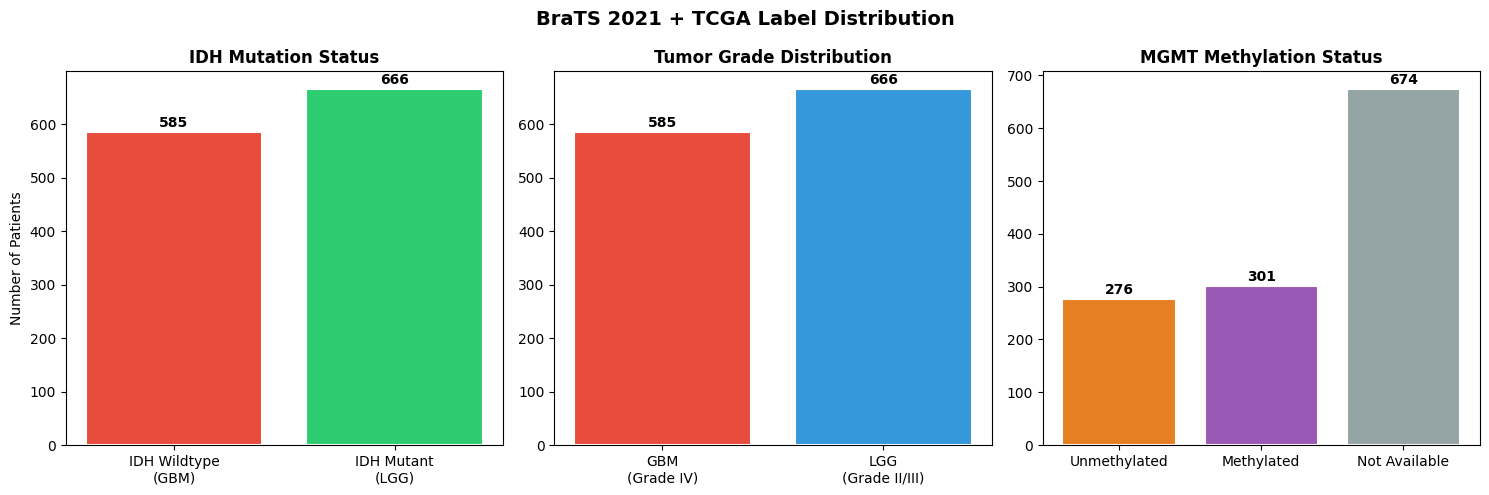

In [8]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('BraTS 2021 + TCGA Label Distribution', fontsize=14, fontweight='bold')

# IDH
axes[0].bar(['IDH Wildtype\n(GBM)', 'IDH Mutant\n(LGG)'], [585, 666], 
            color=['#E74C3C', '#2ECC71'], edgecolor='white', linewidth=1.5)
axes[0].set_title('IDH Mutation Status', fontweight='bold')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate([585, 666]):
    axes[0].text(i, v+10, str(v), ha='center', fontweight='bold')

# Grade
axes[1].bar(['GBM\n(Grade IV)', 'LGG\n(Grade II/III)'], [585, 666],
            color=['#E74C3C', '#3498DB'], edgecolor='white', linewidth=1.5)
axes[1].set_title('Tumor Grade Distribution', fontweight='bold')
for i, v in enumerate([585, 666]):
    axes[1].text(i, v+10, str(v), ha='center', fontweight='bold')

# MGMT
axes[2].bar(['Unmethylated', 'Methylated', 'Not Available'], [276, 301, 674],
            color=['#E67E22', '#9B59B6', '#95A5A6'], edgecolor='white', linewidth=1.5)
axes[2].set_title('MGMT Methylation Status', fontweight='bold')
for i, v in enumerate([276, 301, 674]):
    axes[2].text(i, v+10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('BraTS 2021 — 4 MRI Modalities Across 3 Patients', fontsize=14, fontweight='bold')

patients = ['BraTS2021_00000', 'BraTS2021_00500', 'BraTS2021_01200']
modalities = ['t1', 't1ce', 't2', 'flair']
mod_titles = ['T1', 'T1ce (Contrast)', 'T2', 'FLAIR']

for row, pid in enumerate(patients):
    pdir = f"{BRATS_ROOT}/{pid}"
    for col, (mod, title) in enumerate(zip(modalities, mod_titles)):
        vol = nib.load(f"{pdir}/{pid}_{mod}.nii.gz").get_fdata()
        slc = vol[:, :, 77]
        axes[row][col].imshow(slc, cmap='gray')
        if row == 0:
            axes[row][col].set_title(title, fontweight='bold', fontsize=12)
        axes[row][col].set_ylabel(f'Patient {row+1}' if col == 0 else '')
        axes[row][col].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/mri_grid.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Train / Validation / Test Split', fontsize=14, fontweight='bold')

# Split sizes
splits = ['Train\n(875)', 'Validation\n(188)', 'Test\n(188)']
sizes = [875, 188, 188]
colors = ['#2ECC71', '#3498DB', '#E74C3C']

axes[0].pie(sizes, labels=splits, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Overall Split (1,251 patients)', fontweight='bold')

# GBM vs LGG per split
x = np.arange(3)
width = 0.35
gbm_counts = [int(875*585/1251), int(188*585/1251), int(188*585/1251)]
lgg_counts = [875-gbm_counts[0], 188-gbm_counts[1], 188-gbm_counts[2]]

bars1 = axes[1].bar(x - width/2, gbm_counts, width, label='GBM', color='#E74C3C', edgecolor='white')
bars2 = axes[1].bar(x + width/2, lgg_counts, width, label='LGG', color='#3498DB', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Train', 'Validation', 'Test'])
axes[1].set_title('GBM vs LGG per Split', fontweight='bold')
axes[1].set_ylabel('Number of Patients')
axes[1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/data_split.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('GBM vs LGG — All 4 Modalities Comparison', fontsize=14, fontweight='bold')

gbm_sample = df_full[df_full['tumor_type']=='GBM']['patient_folder'].iloc[0]
lgg_sample = df_full[df_full['tumor_type']=='LGG']['patient_folder'].iloc[0]
modalities = ['t1', 't1ce', 't2', 'flair']

for col, mod in enumerate(modalities):
    for row, (pid, label) in enumerate([(gbm_sample, 'GBM'), (lgg_sample, 'LGG')]):
        vol = nib.load(f"{BRATS_ROOT}/{pid}/{pid}_{mod}.nii.gz").get_fdata()
        slc = vol[:, :, 77]
        
        axes[row][col].imshow(slc, cmap='gray')
        axes[row][col].axis('off')
        if row == 0:
            axes[row][col].set_title(mod.upper(), fontweight='bold', fontsize=13)
        if col == 0:
            color = '#E74C3C' if label == 'GBM' else '#2ECC71'
            axes[row][col].set_ylabel(label, fontsize=13, fontweight='bold', color=color)
            axes[row][col].yaxis.label.set_visible(True)
            axes[row][col].set_yticks([])

plt.tight_layout()
plt.savefig('/kaggle/working/eda_gbm_vs_lgg.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Intensity Distribution — Before vs After Z-score Normalization', fontsize=13, fontweight='bold')

sample_pid = df_full['patient_folder'].iloc[0]
modalities = ['t1', 't1ce', 't2', 'flair']
colors = ['#0891B2', '#7C3AED', '#059669', '#D97706']

for col, (mod, color) in enumerate(zip(modalities, colors)):
    vol = nib.load(f"{BRATS_ROOT}/{sample_pid}/{sample_pid}_{mod}.nii.gz").get_fdata()
    slc = vol[:, :, 77].astype(np.float32)
    mask = slc > 0

    # Raw
    axes[0][col].hist(slc[mask].flatten(), bins=80, color=color, alpha=0.8, edgecolor='none')
    axes[0][col].set_title(f'{mod.upper()} — Raw', fontweight='bold')
    axes[0][col].set_xlabel('Intensity')
    if col == 0: axes[0][col].set_ylabel('Frequency')

    # Normalized
    slc_norm = slc.copy()
    slc_norm[mask] = (slc[mask] - slc[mask].mean()) / (slc[mask].std() + 1e-8)
    axes[1][col].hist(slc_norm[mask].flatten(), bins=80, color=color, alpha=0.8, edgecolor='none')
    axes[1][col].set_title(f'{mod.upper()} — Z-score Normalized', fontweight='bold')
    axes[1][col].set_xlabel('Intensity')
    if col == 0: axes[1][col].set_ylabel('Frequency')
    axes[1][col].axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='mean=0')

plt.tight_layout()
plt.savefig('/kaggle/working/eda_intensity_dist.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('MGMT Label Analysis', fontsize=14, fontweight='bold')

labeled = df_full[df_full['mgmt'].notna()].copy()

gbm_mgmt = labeled[labeled['tumor_type']=='GBM']['mgmt'].value_counts()
lgg_mgmt = labeled[labeled['tumor_type']=='LGG']['mgmt'].value_counts()

x = np.arange(2)
width = 0.35
axes[0].bar(x - width/2, [gbm_mgmt.get(0.0,0), gbm_mgmt.get(1.0,0)], width,
            label='GBM', color='#E74C3C', edgecolor='white')
axes[0].bar(x + width/2, [lgg_mgmt.get(0.0,0), lgg_mgmt.get(1.0,0)], width,
            label='LGG', color='#2ECC71', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Unmethylated', 'Methylated'])
axes[0].set_ylabel('Patients')
axes[0].set_title('MGMT Distribution by Tumor Type', fontweight='bold')
axes[0].legend()

# MGMT balance
axes[1].pie([labeled['mgmt'].value_counts().get(0.0,0),
             labeled['mgmt'].value_counts().get(1.0,0)],
            labels=['Unmethylated\n(276)', 'Methylated\n(301)'],
            colors=['#E67E22', '#9B59B6'],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize':12})
axes[1].set_title('Overall MGMT Balance (577 labeled)', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/eda_mgmt_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ── SECTION 7: MODEL ARCHITECTURE ────────────────────────────────────────────
import torchvision.models as models

class RadiogenomicsModel(nn.Module):
    def __init__(self):
        super().__init__()

        # Load pretrained EfficientNet-B2
        self.backbone = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1)

        # Modify first conv: 3 channels → 4 channels
        orig_conv = self.backbone.features[0][0]
        self.backbone.features[0][0] = nn.Conv2d(
            4, orig_conv.out_channels,
            kernel_size=orig_conv.kernel_size,
            stride=orig_conv.stride,
            padding=orig_conv.padding,
            bias=False
        )

        # Initialize 4th channel weights as mean of original 3
        with torch.no_grad():
            self.backbone.features[0][0].weight[:, :3] = orig_conv.weight
            self.backbone.features[0][0].weight[:, 3]  = orig_conv.weight.mean(dim=1)

        # Remove original classifier
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        # Fusion layer
        self.fusion = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, 512),
            nn.ReLU()
        )

        # 3 task heads
        self.idh_head   = nn.Sequential(nn.Linear(512, 256), nn.ReLU(), nn.Linear(256, 1))
        self.mgmt_head  = nn.Sequential(nn.Linear(512, 256), nn.ReLU(), nn.Linear(256, 1))
        self.grade_head = nn.Sequential(nn.Linear(512, 256), nn.ReLU(), nn.Linear(256, 2))

    def forward(self, x):
        features = self.backbone(x)
        fused    = self.fusion(features)
        return self.idh_head(fused), self.mgmt_head(fused), self.grade_head(fused)


# ── TEST FORWARD PASS ─────────────────────────────────────────────────────────
model = RadiogenomicsModel().to(device)
dummy = torch.randn(2, 4, 224, 224).to(device)
idh_out, mgmt_out, grade_out = model(dummy)

print("IDH output shape:  ", idh_out.shape)
print("MGMT output shape: ", mgmt_out.shape)
print("Grade output shape:", grade_out.shape)
print(f"\nTotal parameters:     {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 169MB/s]


IDH output shape:   torch.Size([2, 1])
MGMT output shape:  torch.Size([2, 1])
Grade output shape: torch.Size([2, 2])

Total parameters:     8,817,702
Trainable parameters: 8,817,702


In [10]:
# ========================================
# LOSS FUNCTION (IMPROVED)
# ========================================

bce = nn.BCEWithLogitsLoss()
ce  = nn.CrossEntropyLoss()

def compute_loss(outputs, idh, mgmt, grade):
    
    idh_pred, mgmt_pred, grade_pred = outputs
    
    # IDH loss
    loss_idh = bce(idh_pred.squeeze(), idh)
    
    # MGMT loss (only valid samples)
    mask = mgmt != -1
    
    if mask.sum() > 0:
        loss_mgmt = bce(mgmt_pred.squeeze()[mask], mgmt[mask])
    else:
        loss_mgmt = 0.0
    
    # Grade loss
    loss_grade = ce(grade_pred, grade)
    
    # 🔥 Weighted total loss (IMPORTANT CHANGE)
    total_loss = (
        1.0 * loss_idh + 
        0.5 * loss_mgmt + 
        1.0 * loss_grade
    )
    
    return total_loss

In [11]:
# ========================================
# OPTIMIZER + SCHEDULER
# ========================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,   # was 3e-4
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30
)

In [12]:
# ========================================
# TRAIN + VALIDATE FUNCTIONS (FINAL)
# ========================================

def train_epoch(loader):
    
    model.train()
    total_loss = 0
    
    for imgs, labels in loader:
        
        imgs = imgs.to(device)
        
        idh = labels['idh'].to(device)
        mgmt = labels['mgmt'].to(device)
        grade = labels['grade'].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(imgs)
        
        loss = compute_loss(outputs, idh, mgmt, grade)
        
        loss.backward()
        
        # 🔥 Gradient clipping (important)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
        
    return total_loss / len(loader)


from sklearn.metrics import accuracy_score

def validate_epoch(loader):
    
    model.eval()
    
    total_loss = 0
    
    idh_preds, idh_targets = [], []
    mgmt_preds, mgmt_targets = [], []
    grade_preds, grade_targets = [], []
    
    with torch.no_grad():
        for imgs, labels in loader:
            
            imgs = imgs.to(device)
            
            idh = labels['idh'].to(device)
            mgmt = labels['mgmt'].to(device)
            grade = labels['grade'].to(device)
            
            outputs = model(imgs)
            loss = compute_loss(outputs, idh, mgmt, grade)
            
            total_loss += loss.item()
            
            # ======================
            # IDH (Binary)
            # ======================
            idh_prob = torch.sigmoid(outputs[0]).cpu().numpy().flatten()
            idh_preds.extend((idh_prob > 0.5).astype(int))
            idh_targets.extend(idh.cpu().numpy().flatten())
            
            # ======================
            # MGMT (Binary, partial labels)
            # ======================
            mgmt_prob = torch.sigmoid(outputs[1]).cpu().numpy().flatten()
            mgmt_true = mgmt.cpu().numpy().flatten()
            
            for p, t in zip(mgmt_prob, mgmt_true):
                if t != -1:  # ignore missing
                    mgmt_preds.append(int(p > 0.5))
                    mgmt_targets.append(int(t))
            
            # ======================
            # Grade (Multiclass)
            # ======================
            grade_pred = torch.argmax(outputs[2], dim=1).cpu().numpy()
            grade_preds.extend(grade_pred)
            grade_targets.extend(grade.cpu().numpy())
    
    # ======================
    # Metrics
    # ======================
    
    idh_auc = roc_auc_score(idh_targets, idh_preds)
    idh_acc = accuracy_score(idh_targets, idh_preds)
    
    mgmt_acc = accuracy_score(mgmt_targets, mgmt_preds) if len(mgmt_targets) > 0 else 0
    
    grade_acc = accuracy_score(grade_targets, grade_preds)
    
    return (
        total_loss / len(loader),
        idh_auc,
        idh_acc,
        mgmt_acc,
        grade_acc
    )

In [ ]:
# subset = torch.utils.data.Subset(train_dataset, range(32))
# debug_loader = DataLoader(subset, batch_size=8)

# loss = train_epoch(debug_loader)

# print("Mini training loss:", loss)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

epochs = 3
best_auc = 0.0

for epoch in range(epochs):
    
    train_loss = train_epoch(train_loader)
    
    val_loss, idh_auc, idh_acc, mgmt_acc, grade_acc = validate_epoch(val_loader)
    
    scheduler.step()
    
    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    
    print(f"IDH  → AUC: {idh_auc:.4f}, Acc: {idh_acc:.4f}")
    print(f"MGMT → Acc: {mgmt_acc:.4f}")
    print(f"Grade→ Acc: {grade_acc:.4f}")
    
    # Save best model
    if idh_auc > best_auc:
        best_auc = idh_auc
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ Best model saved!")

In [ ]:
# ========================================
# CONTINUE TRAINING (FIXED VERSION)
# ========================================

from tqdm import tqdm
from sklearn.metrics import accuracy_score, roc_auc_score
import os
import torch

# ✅ Safe device
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# ✅ Load only if exists
if os.path.exists("best_model.pth"):
    model.load_state_dict(torch.load("best_model.pth", map_location=device))
    print("Loaded previous best model")

# ✅ IMPORTANT: update to your current best
best_auc = 0.7111   # <-- from your latest result

epochs = 10
start_epoch = 3
patience = 3
counter = 0

for epoch in range(start_epoch, epochs):
    
    # ======================
    # TRAIN
    # ======================
    model.train()
    total_loss = 0
    
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1} Training")
    
    for imgs, labels in progress_bar:
        
        imgs = imgs.to(device, non_blocking=True)
        
        idh = labels['idh'].to(device)
        mgmt = labels['mgmt'].to(device)
        grade = labels['grade'].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(imgs)
        loss = compute_loss(outputs, idh, mgmt, grade)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
        
        # 🔥 better live stats
        progress_bar.set_postfix({
            "batch_loss": f"{loss.item():.3f}",
            "avg_loss": f"{(total_loss/(progress_bar.n+1)):.3f}"
        })
    
    train_loss = total_loss / len(train_loader)
    
    # ======================
    # VALIDATION
    # ======================
    model.eval()
    
    val_loss = 0
    idh_probs, idh_preds, idh_targets = [], [], []
    mgmt_preds, mgmt_targets = [], []
    grade_preds, grade_targets = [], []
    
    with torch.no_grad():
        for imgs, labels in val_loader:
            
            imgs = imgs.to(device)
            
            idh = labels['idh'].to(device)
            mgmt = labels['mgmt'].to(device)
            grade = labels['grade'].to(device)
            
            outputs = model(imgs)
            loss = compute_loss(outputs, idh, mgmt, grade)
            
            val_loss += loss.item()
            
            # IDH
            idh_prob = torch.sigmoid(outputs[0]).cpu().numpy().flatten()
            idh_probs.extend(idh_prob)
            idh_preds.extend((idh_prob > 0.5).astype(int))
            idh_targets.extend(idh.cpu().numpy().flatten())
            
            # MGMT
            mgmt_prob = torch.sigmoid(outputs[1]).cpu().numpy().flatten()
            mgmt_true = mgmt.cpu().numpy().flatten()
            
            for p, t in zip(mgmt_prob, mgmt_true):
                if t != -1:
                    mgmt_preds.append(int(p > 0.5))
                    mgmt_targets.append(int(t))
            
            # Grade
            grade_pred = torch.argmax(outputs[2], dim=1).cpu().numpy()
            grade_preds.extend(grade_pred)
            grade_targets.extend(grade.cpu().numpy())
    
    val_loss /= len(val_loader)
    
    # ======================
    # METRICS
    # ======================
    idh_auc = roc_auc_score(idh_targets, idh_probs)
    idh_acc = accuracy_score(idh_targets, idh_preds)
    mgmt_acc = accuracy_score(mgmt_targets, mgmt_preds) if len(mgmt_targets) > 0 else 0
    grade_acc = accuracy_score(grade_targets, grade_preds)
    
    scheduler.step()
    
    # ======================
    # PRINT
    # ======================
    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    
    print(f"IDH  → AUC: {idh_auc:.4f}, Acc: {idh_acc:.4f}")
    print(f"MGMT → Acc: {mgmt_acc:.4f}")
    print(f"Grade→ Acc: {grade_acc:.4f}")
    
    # ======================
    # SAVE BEST MODEL
    # ======================
    if idh_auc > best_auc:
        print(f"🔥 Improved: {best_auc:.4f} → {idh_auc:.4f}")
        best_auc = idh_auc
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ Best model saved!")
        counter = 0
    else:
        counter += 1
    
    # ======================
    # EARLY STOPPING
    # ======================
    if counter >= patience:
        print("⛔ Early stopping triggered")
        break

In [ ]:
torch.save(model.state_dict(), "final_model.pth")

In [ ]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

In [39]:
MODEL_PATH = "/kaggle/input/datasets/mondaldebasish05/radiogenomicsmodal-1/Model1.pth"

In [40]:
device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_PATH = "/kaggle/input/datasets/mondaldebasish05/radiogenomicsmodal-1/Model1.pth"

model = RadiogenomicsModel()
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

model.to(device)
model.eval()

print("✅ Model loaded successfully!")

✅ Model loaded successfully!


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



===== FINAL TEST RESULTS =====
IDH  → AUC: 0.7842, Acc: 0.7287
MGMT → Acc: 0.4138
Grade→ Acc: 0.7287


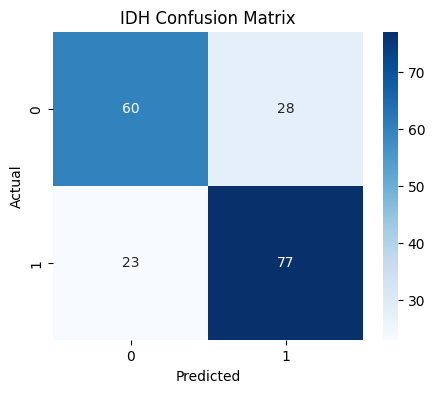


IDH Classification Report:
              precision    recall  f1-score   support

         0.0       0.72      0.68      0.70        88
         1.0       0.73      0.77      0.75       100

    accuracy                           0.73       188
   macro avg       0.73      0.73      0.73       188
weighted avg       0.73      0.73      0.73       188



In [42]:
# ========================================
# FINAL TEST EVALUATION
# ========================================

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt

# Load best model
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

model.to(device)
model.eval()

# Storage
idh_probs, idh_preds, idh_targets = [], [], []
mgmt_preds, mgmt_targets = [], []
grade_preds, grade_targets = [], []

# ======================
# TEST LOOP
# ======================
with torch.no_grad():
    for imgs, labels in test_loader:
        
        imgs = imgs.to(device)
        
        idh = labels['idh'].to(device)
        mgmt = labels['mgmt'].to(device)
        grade = labels['grade'].to(device)
        
        outputs = model(imgs)
        
        # ------------------
        # IDH
        # ------------------
        idh_prob = torch.sigmoid(outputs[0]).cpu().numpy().flatten()
        idh_probs.extend(idh_prob)
        idh_preds.extend((idh_prob > 0.5).astype(int))
        idh_targets.extend(idh.cpu().numpy().flatten())
        
        # ------------------
        # MGMT
        # ------------------
        mgmt_prob = torch.sigmoid(outputs[1]).cpu().numpy().flatten()
        mgmt_true = mgmt.cpu().numpy().flatten()
        
        for p, t in zip(mgmt_prob, mgmt_true):
            if t != -1:
                mgmt_preds.append(int(p > 0.5))
                mgmt_targets.append(int(t))
        
        # ------------------
        # Grade
        # ------------------
        grade_pred = torch.argmax(outputs[2], dim=1).cpu().numpy()
        grade_preds.extend(grade_pred)
        grade_targets.extend(grade.cpu().numpy())

# ======================
# METRICS
# ======================

idh_auc = roc_auc_score(idh_targets, idh_probs)
idh_acc = accuracy_score(idh_targets, idh_preds)

mgmt_acc = accuracy_score(mgmt_targets, mgmt_preds) if len(mgmt_targets) > 0 else 0
grade_acc = accuracy_score(grade_targets, grade_preds)

print("\n===== FINAL TEST RESULTS =====")
print(f"IDH  → AUC: {idh_auc:.4f}, Acc: {idh_acc:.4f}")
print(f"MGMT → Acc: {mgmt_acc:.4f}")
print(f"Grade→ Acc: {grade_acc:.4f}")

# ======================
# CONFUSION MATRIX (IDH)
# ======================

cm = confusion_matrix(idh_targets, idh_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("IDH Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ======================
# CLASSIFICATION REPORT
# ======================

print("\nIDH Classification Report:")
print(classification_report(idh_targets, idh_preds))

In [43]:
import numpy as np
from sklearn.metrics import f1_score

best_thr = 0
best_f1 = 0

for t in np.arange(0.1, 0.9, 0.01):
    preds = (np.array(idh_probs) > t).astype(int)
    f1 = f1_score(idh_targets, preds)
    
    if f1 > best_f1:
        best_f1 = f1
        best_thr = t

print("Best threshold:", best_thr)

Best threshold: 0.12


In [44]:
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

idh_probs_np = np.array(idh_probs)
idh_targets_np = np.array(idh_targets)

best_thr = 0
best_f1 = 0
best_acc = 0

for t in np.arange(0.1, 0.9, 0.01):
    preds = (idh_probs_np > t).astype(int)
    
    f1 = f1_score(idh_targets_np, preds)
    acc = accuracy_score(idh_targets_np, preds)
    
    if f1 > best_f1:
        best_f1 = f1
        best_acc = acc
        best_thr = t

print(f"\n🔥 Best Threshold: {best_thr:.2f}")
print(f"🔥 Best F1 Score: {best_f1:.4f}")
print(f"🔥 Accuracy at Best Threshold: {best_acc:.4f}")


🔥 Best Threshold: 0.12
🔥 Best F1 Score: 0.7759
🔥 Accuracy at Best Threshold: 0.7234


In [45]:
from sklearn.metrics import accuracy_score, f1_score

for t in [0.12, 0.3, 0.4, 0.5]:
    preds = (idh_probs_np > t).astype(int)
    
    print(f"\nThreshold: {t}")
    print("Accuracy:", accuracy_score(idh_targets_np, preds))
    print("F1 Score:", f1_score(idh_targets_np, preds))


Threshold: 0.12
Accuracy: 0.723404255319149
F1 Score: 0.7758620689655172

Threshold: 0.3
Accuracy: 0.723404255319149
F1 Score: 0.7657657657657657

Threshold: 0.4
Accuracy: 0.7180851063829787
F1 Score: 0.7464114832535885

Threshold: 0.5
Accuracy: 0.7287234042553191
F1 Score: 0.751219512195122


In [9]:
#Architecture
import torch
import torch.nn as nn
import torchvision.models as models

class RadiogenomicsModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.efficientnet_b2(
            weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1
        )

        # Modify first conv (3 → 4 channels)
        orig_conv = self.backbone.features[0][0]
        self.backbone.features[0][0] = nn.Conv2d(
            4, orig_conv.out_channels,
            kernel_size=orig_conv.kernel_size,
            stride=orig_conv.stride,
            padding=orig_conv.padding,
            bias=False
        )

        with torch.no_grad():
            self.backbone.features[0][0].weight[:, :3] = orig_conv.weight
            self.backbone.features[0][0].weight[:, 3] = orig_conv.weight.mean(dim=1)

        # Remove classifier
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        # 🔥 Freeze early layers (IMPORTANT)
        for param in model.backbone.features[:2].parameters():
            param.requires_grad = False 

        # Fusion
        self.fusion = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, 512),
            nn.ReLU()
        )

        # 🔥 Improved heads (with dropout)
        self.idh_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 1)
        )

        self.mgmt_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 1)
        )

        self.grade_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        features = self.backbone(x)
        fused = self.fusion(features)
        return (
            self.idh_head(fused),
            self.mgmt_head(fused),
            self.grade_head(fused)
        )

In [10]:
#Loss Function
class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')
    
    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        pt = torch.exp(-bce_loss)
        loss = ((1 - pt) ** self.gamma) * bce_loss
        return loss.mean()
bce = FocalLoss(gamma=2)
ce  = nn.CrossEntropyLoss(label_smoothing=0.1)

def compute_loss(outputs, idh, mgmt, grade):

    idh_pred, mgmt_pred, grade_pred = outputs

    # IDH
    loss_idh = bce(idh_pred.squeeze(), idh)

    # MGMT (masked)
    mask = mgmt != -1
    if mask.sum() > 0:
        loss_mgmt = bce(mgmt_pred.squeeze()[mask], mgmt[mask])
    else:
        loss_mgmt = torch.tensor(0.0, device=idh.device)

    # Grade
    loss_grade = ce(grade_pred, grade)

    # 🔥 Better balance
    total_loss = (
        1.2 * loss_idh +
        0.7 * loss_mgmt +
        0.8 * loss_grade
    )

    return total_loss

In [11]:
#optimizer
device = "cuda" if torch.cuda.is_available() else "cpu"

model = RadiogenomicsModel().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=8e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)


Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 148MB/s] 


NameError: name 'model' is not defined

In [12]:
#Training Loop
from tqdm import tqdm
import torch

def train_epoch(loader):
    
    model.train()
    total_loss = 0
    
    for imgs, labels in loader:
        
        imgs = imgs.to(device)
        idh = labels['idh'].to(device)
        mgmt = labels['mgmt'].to(device)
        grade = labels['grade'].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(imgs)
        loss = compute_loss(outputs, idh, mgmt, grade)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

In [13]:
#Validation
from sklearn.metrics import accuracy_score, roc_auc_score

def validate_epoch(loader):
    
    model.eval()
    
    total_loss = 0
    
    idh_probs, idh_targets = [], []
    mgmt_preds, mgmt_targets = [], []
    grade_preds, grade_targets = [], []
    
    with torch.no_grad():
        for imgs, labels in loader:
            
            imgs = imgs.to(device)
            
            idh = labels['idh'].to(device)
            mgmt = labels['mgmt'].to(device)
            grade = labels['grade'].to(device)
            
            outputs = model(imgs)
            loss = compute_loss(outputs, idh, mgmt, grade)
            
            total_loss += loss.item()
            
            # IDH (correct AUC)
            idh_prob = torch.sigmoid(outputs[0]).cpu().numpy().flatten()
            idh_probs.extend(idh_prob)
            idh_targets.extend(idh.cpu().numpy().flatten())
            
            # MGMT
            mgmt_prob = torch.sigmoid(outputs[1]).cpu().numpy().flatten()
            mgmt_true = mgmt.cpu().numpy().flatten()
            
            for p, t in zip(mgmt_prob, mgmt_true):
                if t != -1:
                    mgmt_preds.append(int(p > 0.5))
                    mgmt_targets.append(int(t))
            
            # Grade
            grade_pred = torch.argmax(outputs[2], dim=1).cpu().numpy()
            grade_preds.extend(grade_pred)
            grade_targets.extend(grade.cpu().numpy())
    
    idh_auc = roc_auc_score(idh_targets, idh_probs)
    idh_acc = accuracy_score(idh_targets, (np.array(idh_probs) > 0.5).astype(int))
    mgmt_acc = accuracy_score(mgmt_targets, mgmt_preds) if len(mgmt_targets) > 0 else 0
    grade_acc = accuracy_score(grade_targets, grade_preds)
    
    return (
        total_loss / len(loader),
        idh_auc,
        idh_acc,
        mgmt_acc,
        grade_acc
    )

# **v2:** Baseline training with standard learning rate, moderate dropout, and partially frozen backbone for stable feature learning.

In [8]:
from tqdm import tqdm
import numpy as np
import torch

epochs = 12
best_auc = 0.0
patience = 4
counter = 0

for epoch in range(epochs):
    
    # ======================
    # TRAIN (WITH LIVE PROGRESS)
    # ======================
    model.train()
    total_loss = 0
    
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1} Training")
    
    for i, (imgs, labels) in enumerate(progress_bar):
        
        imgs = imgs.to(device)
        idh = labels['idh'].to(device)
        mgmt = labels['mgmt'].to(device)
        grade = labels['grade'].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(imgs)
        loss = compute_loss(outputs, idh, mgmt, grade)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
        
        # 🔥 LIVE UPDATE (VERY IMPORTANT)
        progress_bar.set_postfix({
            "batch_loss": f"{loss.item():.4f}",
            "avg_loss": f"{(total_loss/(i+1)):.4f}"
        })
    
    train_loss = total_loss / len(train_loader)
    
    # ======================
    # VALIDATION
    # ======================
    val_loss, idh_auc, idh_acc, mgmt_acc, grade_acc = validate_epoch(val_loader)
    
    scheduler.step()
    
    # ======================
    # PRINT EPOCH SUMMARY
    # ======================
    print(f"\n📊 Epoch {epoch+1} Summary")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    
    print(f"IDH  → AUC: {idh_auc:.4f}, Acc: {idh_acc:.4f}")
    print(f"MGMT → Acc: {mgmt_acc:.4f}")
    print(f"Grade→ Acc: {grade_acc:.4f}")
    
    # ======================
    # SAVE BEST MODEL
    # ======================
    if idh_auc > best_auc:
        print(f"🔥 Improved: {best_auc:.4f} → {idh_auc:.4f}")
        best_auc = idh_auc
        torch.save(model.state_dict(), "best_model_v2.pth")
        print("✅ Saved best_model_v2.pth")
        counter = 0
    else:
        counter += 1
    
    # ======================
    # EARLY STOPPING
    # ======================
    if counter >= patience:
        print("⛔ Early stopping triggered")
        break

NameError: name 'model' is not defined

In [43]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=8e-5,   # 🔥 lower LR
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=12
)

# **v4:** Aggressive training with reduced regularization and higher flexibility, leading to minimal constraints and increased risk of overfitting.

In [44]:
from tqdm import tqdm
import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score

epochs = 10
best_auc = 0.0
patience = 3
counter = 0

for epoch in range(epochs):
    
    # ======================
    # TRAIN (LIVE METRICS)
    # ======================
    model.train()
    total_loss = 0
    
    running_probs = []
    running_targets = []
    
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1} Training")
    
    for i, (imgs, labels) in enumerate(progress_bar):
        
        imgs = imgs.to(device)
        idh = labels['idh'].to(device)
        mgmt = labels['mgmt'].to(device)
        grade = labels['grade'].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(imgs)
        loss = compute_loss(outputs, idh, mgmt, grade)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
        
        # ======================
        # LIVE METRICS (IDH)
        # ======================
        probs = torch.sigmoid(outputs[0]).detach().cpu().numpy().flatten()
        targets = idh.cpu().numpy().flatten()
        
        running_probs.extend(probs)
        running_targets.extend(targets)
        
        # Compute live AUC safely
        if len(set(running_targets)) > 1:
            live_auc = roc_auc_score(running_targets, running_probs)
            live_acc = accuracy_score(
                running_targets,
                (np.array(running_probs) > 0.5).astype(int)
            )
        else:
            live_auc = 0.0
            live_acc = 0.0
        
        # ======================
        # UPDATE PROGRESS BAR
        # ======================
        progress_bar.set_postfix({
            "loss": f"{loss.item():.3f}",
            "avg_loss": f"{(total_loss/(i+1)):.3f}",
            "AUC": f"{live_auc:.3f}",
            "ACC": f"{live_acc:.3f}"
        })
    
    train_loss = total_loss / len(train_loader)
    
    # ======================
    # VALIDATION (same as before)
    # ======================
    model.eval()
    
    val_loss = 0
    idh_probs, idh_targets = [], []
    mgmt_preds, mgmt_targets = [], []
    grade_preds, grade_targets = [], []
    
    with torch.no_grad():
        for imgs, labels in val_loader:
            
            imgs = imgs.to(device)
            
            idh = labels['idh'].to(device)
            mgmt = labels['mgmt'].to(device)
            grade = labels['grade'].to(device)
            
            outputs = model(imgs)
            loss = compute_loss(outputs, idh, mgmt, grade)
            
            val_loss += loss.item()
            
            idh_prob = torch.sigmoid(outputs[0]).cpu().numpy().flatten()
            idh_probs.extend(idh_prob)
            idh_targets.extend(idh.cpu().numpy().flatten())
            
            mgmt_prob = torch.sigmoid(outputs[1]).cpu().numpy().flatten()
            mgmt_true = mgmt.cpu().numpy().flatten()
            
            for p, t in zip(mgmt_prob, mgmt_true):
                if t != -1:
                    mgmt_preds.append(int(p > 0.5))
                    mgmt_targets.append(int(t))
            
            grade_pred = torch.argmax(outputs[2], dim=1).cpu().numpy()
            grade_preds.extend(grade_pred)
            grade_targets.extend(grade.cpu().numpy())
    
    val_loss /= len(val_loader)
    
    idh_auc = roc_auc_score(idh_targets, idh_probs)
    idh_acc = accuracy_score(idh_targets, (np.array(idh_probs) > 0.5).astype(int))
    mgmt_acc = accuracy_score(mgmt_targets, mgmt_preds) if len(mgmt_targets) > 0 else 0
    grade_acc = accuracy_score(grade_targets, grade_preds)
    
    scheduler.step()
    
    # ======================
    # FINAL PRINT
    # ======================
    print(f"\n📊 Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    
    print(f"IDH  → AUC: {idh_auc:.4f}, Acc: {idh_acc:.4f}")
    print(f"MGMT → Acc: {mgmt_acc:.4f}")
    print(f"Grade→ Acc: {grade_acc:.4f}")
    
    # ======================
    # SAVE BEST
    # ======================
    if idh_auc > best_auc:
        print(f"🔥 Improved: {best_auc:.4f} → {idh_auc:.4f}")
        best_auc = idh_auc
        
        torch.save({
            'model': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'epoch': epoch,
            'auc': idh_auc
        }, "best_model_v4.pth")
        
        print("✅ Saved best_model_v4.pth")
        counter = 0
    else:
        counter += 1
    
    if counter >= patience:
        print("⛔ Early stopping triggered")
        break

Epoch 1 Training: 100%|██████████| 55/55 [04:04<00:00,  4.45s/it, loss=0.465, avg_loss=0.528, AUC=0.946, ACC=0.882]



📊 Epoch 1
Train Loss: 0.5276
Val Loss:   0.9449
IDH  → AUC: 0.7577, Acc: 0.6702
MGMT → Acc: 0.5402
Grade→ Acc: 0.6702
🔥 Improved: 0.0000 → 0.7577
✅ Saved best_model_v4.pth


Epoch 2 Training: 100%|██████████| 55/55 [03:59<00:00,  4.36s/it, loss=0.393, avg_loss=0.503, AUC=0.956, ACC=0.878]



📊 Epoch 2
Train Loss: 0.5033
Val Loss:   0.9362
IDH  → AUC: 0.7595, Acc: 0.7074
MGMT → Acc: 0.5747
Grade→ Acc: 0.7021
🔥 Improved: 0.7577 → 0.7595
✅ Saved best_model_v4.pth


Epoch 3 Training: 100%|██████████| 55/55 [04:05<00:00,  4.47s/it, loss=0.392, avg_loss=0.478, AUC=0.962, ACC=0.897]


...


📊 Epoch 6
Train Loss: 0.3849
Val Loss:   1.0732
IDH  → AUC: 0.7615, Acc: 0.7021
MGMT → Acc: 0.5057
Grade→ Acc: 0.6968


Epoch 7 Training: 100%|██████████| 55/55 [04:06<00:00,  4.47s/it, loss=0.339, avg_loss=0.411, AUC=0.981, ACC=0.935]



📊 Epoch 7
Train Loss: 0.4112
Val Loss:   1.0031
IDH  → AUC: 0.7630, Acc: 0.6968
MGMT → Acc: 0.5632
Grade→ Acc: 0.7021


Epoch 8 Training: 100%|██████████| 55/55 [04:02<00:00,  4.42s/it, loss=0.512, avg_loss=0.412, AUC=0.980, ACC=0.937]



📊 Epoch 8
Train Loss: 0.4122
Val Loss:   1.0238
IDH  → AUC: 0.7594, Acc: 0.7021
MGMT → Acc: 0.5862
Grade→ Acc: 0.7021
⛔ Early stopping triggered


# **v5:** Optimized training with improved augmentation, balanced loss weighting, and better regularization for controlled and stable learning.

In [99]:
import torch
import torch.nn as nn
import torchvision.models as models

class RadiogenomicsModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.efficientnet_b2(
            weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1
        )

        # Modify input (4 channels)
        orig_conv = self.backbone.features[0][0]
        self.backbone.features[0][0] = nn.Conv2d(
            4, orig_conv.out_channels,
            kernel_size=orig_conv.kernel_size,
            stride=orig_conv.stride,
            padding=orig_conv.padding,
            bias=False
        )

        with torch.no_grad():
            self.backbone.features[0][0].weight[:, :3] = orig_conv.weight
            self.backbone.features[0][0].weight[:, 3] = orig_conv.weight.mean(dim=1)

        # Remove classifier
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        # 🔥 PARTIAL FREEZE (KEY CHANGE)
        for param in self.backbone.features[:3].parameters():
            param.requires_grad = False

        # 🔥 Stronger regularization
        self.fusion = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, 512),
            nn.ReLU()
        )

        self.idh_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 1)
        )

        self.mgmt_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 1)
        )

        self.grade_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        features = self.backbone(x)
        fused = self.fusion(features)
        return (
            self.idh_head(fused),
            self.mgmt_head(fused),
            self.grade_head(fused)
        )

In [100]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        pt = torch.exp(-bce_loss)
        loss = ((1 - pt) ** self.gamma) * bce_loss
        return loss.mean()

bce = FocalLoss(gamma=2)
ce  = nn.CrossEntropyLoss(label_smoothing=0.1)

def compute_loss(outputs, idh, mgmt, grade):

    idh_pred, mgmt_pred, grade_pred = outputs

    loss_idh = bce(idh_pred.squeeze(), idh)

    mask = mgmt != -1
    if mask.sum() > 0:
        loss_mgmt = bce(mgmt_pred.squeeze()[mask], mgmt[mask])
    else:
        loss_mgmt = torch.tensor(0.0, device=idh.device)

    loss_grade = ce(grade_pred, grade)

    # 🔥 Balanced focus
    total_loss = (
        1.2 * loss_idh +
        0.7 * loss_mgmt +
        0.8 * loss_grade
    )

    return total_loss

In [101]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=8e-5,
    weight_decay=3e-4   # 🔥 increased
)

In [102]:
import torch
from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score

device = "cuda" if torch.cuda.is_available() else "cpu"

model = RadiogenomicsModel().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=8e-5,
    weight_decay=3e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

In [ ]:
# ========================================
# TRAINING (v5 FINAL — LIVE + STABLE)
# ========================================

import torch
from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score

device = "cuda" if torch.cuda.is_available() else "cpu"

model = RadiogenomicsModel().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=8e-5,
    weight_decay=3e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

epochs = 10
best_auc = 0.0
patience = 3
counter = 0

for epoch in range(epochs):
    
    # ======================
    # TRAIN (LIVE METRICS)
    # ======================
    model.train()
    total_loss = 0
    
    running_probs = []
    running_targets = []
    
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1} Training")
    
    for i, (imgs, labels) in enumerate(progress_bar):
        
        imgs = imgs.to(device)
        idh = labels['idh'].to(device)
        mgmt = labels['mgmt'].to(device)
        grade = labels['grade'].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(imgs)
        loss = compute_loss(outputs, idh, mgmt, grade)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
        
        # ======================
        # LIVE TRAIN METRICS (IDH)
        # ======================
        probs = torch.sigmoid(outputs[0]).detach().cpu().numpy().flatten()
        targets = idh.cpu().numpy().flatten()
        
        running_probs.extend(probs)
        running_targets.extend(targets)
        
        if len(set(running_targets)) > 1:
            live_auc = roc_auc_score(running_targets, running_probs)
            live_acc = accuracy_score(
                running_targets,
                (np.array(running_probs) > 0.5).astype(int)
            )
        else:
            live_auc = 0.0
            live_acc = 0.0
        
        progress_bar.set_postfix({
            "loss": f"{loss.item():.3f}",
            "avg_loss": f"{(total_loss/(i+1)):.3f}",
            "AUC": f"{live_auc:.3f}",
            "ACC": f"{live_acc:.3f}"
        })
    
    train_loss = total_loss / len(train_loader)
    
    # ======================
    # VALIDATION
    # ======================
    model.eval()
    
    val_loss = 0
    idh_probs, idh_targets = [], []
    mgmt_preds, mgmt_targets = [], []
    grade_preds, grade_targets = [], []
    
    with torch.no_grad():
        for imgs, labels in val_loader:
            
            imgs = imgs.to(device)
            
            idh = labels['idh'].to(device)
            mgmt = labels['mgmt'].to(device)
            grade = labels['grade'].to(device)
            
            outputs = model(imgs)
            loss = compute_loss(outputs, idh, mgmt, grade)
            
            val_loss += loss.item()
            
            # IDH
            idh_prob = torch.sigmoid(outputs[0]).cpu().numpy().flatten()
            idh_probs.extend(idh_prob)
            idh_targets.extend(idh.cpu().numpy().flatten())
            
            # MGMT
            mgmt_prob = torch.sigmoid(outputs[1]).cpu().numpy().flatten()
            mgmt_true = mgmt.cpu().numpy().flatten()
            
            for p, t in zip(mgmt_prob, mgmt_true):
                if t != -1:
                    mgmt_preds.append(int(p > 0.5))
                    mgmt_targets.append(int(t))
            
            # Grade
            grade_pred = torch.argmax(outputs[2], dim=1).cpu().numpy()
            grade_preds.extend(grade_pred)
            grade_targets.extend(grade.cpu().numpy())
    
    val_loss /= len(val_loader)
    
    # ======================
    # METRICS
    # ======================
    idh_auc = roc_auc_score(idh_targets, idh_probs)
    idh_acc = accuracy_score(idh_targets, (np.array(idh_probs) > 0.5).astype(int))
    mgmt_acc = accuracy_score(mgmt_targets, mgmt_preds) if len(mgmt_targets) > 0 else 0
    grade_acc = accuracy_score(grade_targets, grade_preds)
    
    scheduler.step()
    
    # ======================
    # PRINT
    # ======================
    print(f"\n📊 Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    
    print(f"IDH  → AUC: {idh_auc:.4f}, Acc: {idh_acc:.4f}")
    print(f"MGMT → Acc: {mgmt_acc:.4f}")
    print(f"Grade→ Acc: {grade_acc:.4f}")
    
    # ======================
    # SAVE BEST MODEL
    # ======================
    if idh_auc > best_auc:
        print(f"🔥 Improved: {best_auc:.4f} → {idh_auc:.4f}")
        best_auc = idh_auc
        
        torch.save({
            'model': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'epoch': epoch,
            'auc': idh_auc
        }, "best_model_v5.pth")
        
        print("✅ Saved best_model_v5.pth")
        counter = 0
    else:
        counter += 1
    
    # ======================
    # EARLY STOPPING
    # ======================
    if counter >= patience:
        print("⛔ Early stopping triggered")
        break

Epoch 1 Training: 100%|██████████| 55/55 [06:47<00:00,  7.41s/it, loss=0.867, avg_loss=0.881, AUC=0.500, ACC=0.512]



📊 Epoch 1
Train Loss: 0.8814
Val Loss:   0.8742
IDH  → AUC: 0.5932, Acc: 0.5585
MGMT → Acc: 0.5977
Grade→ Acc: 0.5319
🔥 Improved: 0.0000 → 0.5932
✅ Saved best_model_v5.pth


Epoch 2 Training: 100%|██████████| 55/55 [06:41<00:00,  7.30s/it, loss=0.804, avg_loss=0.866, AUC=0.636, ACC=0.578]



📊 Epoch 2
Train Loss: 0.8664
Val Loss:   0.8466
IDH  → AUC: 0.6945, Acc: 0.6702
MGMT → Acc: 0.6552
Grade→ Acc: 0.6702
🔥 Improved: 0.5932 → 0.6945
✅ Saved best_model_v5.pth


Epoch 3 Training: 100%|██████████| 55/55 [06:43<00:00,  7.33s/it, loss=0.757, avg_loss=0.823, AUC=0.715, ACC=0.649]


...

Epoch 5 Training: 100%|██████████| 55/55 [07:03<00:00,  7.70s/it, loss=0.687, avg_loss=0.699, AUC=0.841, ACC=0.755]



📊 Epoch 5
Train Loss: 0.6993
Val Loss:   0.7636
IDH  → AUC: 0.7695, Acc: 0.7074
MGMT → Acc: 0.6552
Grade→ Acc: 0.6968


Epoch 6 Training: 100%|██████████| 55/55 [07:06<00:00,  7.76s/it, loss=0.737, avg_loss=0.684, AUC=0.854, ACC=0.765]



📊 Epoch 6
Train Loss: 0.6836
Val Loss:   0.7681
IDH  → AUC: 0.7633, Acc: 0.7021
MGMT → Acc: 0.6897
Grade→ Acc: 0.7128


Epoch 7 Training:  56%|█████▋    | 31/55 [03:55<03:06,  7.78s/it, loss=0.679, avg_loss=0.649, AUC=0.880, ACC=0.794]

In [53]:
!cp best_model_v5.pth /kaggle/working/

cp: 'best_model_v5.pth' and '/kaggle/working/best_model_v5.pth' are the same file


# MODEL COMPARISON

In [57]:
# ========================================
# MODEL COMPARISON (FROM KAGGLE OUTPUT)
# ========================================

import torch
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score

device = "cuda" if torch.cuda.is_available() else "cpu"

# ======================
# LOAD MODEL FUNCTION
# ======================

def load_model(path):
    model = RadiogenomicsModel().to(device)
    
    checkpoint = torch.load(
        path,
        map_location=device,
        weights_only=False   # 🔥 FIX
    )
    
    if 'model' in checkpoint:
        model.load_state_dict(checkpoint['model'])
    else:
        model.load_state_dict(checkpoint)
    
    model.eval()
    return model


# ======================
# LOAD MODELS (FROM OUTPUT)
# ======================

model_v2 = load_model("/kaggle/working/best_model_v2.pth")
model_v4 = load_model("/kaggle/working/best_model_v4.pth")
model_v5 = load_model("/kaggle/working/best_model_v5.pth")


# ======================
# EVALUATION FUNCTION
# ======================

def evaluate(model, loader):
    
    idh_probs, idh_targets = [], []
    mgmt_preds, mgmt_targets = [], []
    grade_preds, grade_targets = [], []
    
    with torch.no_grad():
        for imgs, labels in loader:
            
            imgs = imgs.to(device)
            
            idh = labels['idh'].to(device)
            mgmt = labels['mgmt'].to(device)
            grade = labels['grade'].to(device)
            
            outputs = model(imgs)
            
            # IDH
            idh_prob = torch.sigmoid(outputs[0]).cpu().numpy().flatten()
            idh_probs.extend(idh_prob)
            idh_targets.extend(idh.cpu().numpy().flatten())
            
            # MGMT
            mgmt_prob = torch.sigmoid(outputs[1]).cpu().numpy().flatten()
            mgmt_true = mgmt.cpu().numpy().flatten()
            
            for p, t in zip(mgmt_prob, mgmt_true):
                if t != -1:
                    mgmt_preds.append(int(p > 0.5))
                    mgmt_targets.append(int(t))
            
            # Grade
            grade_pred = torch.argmax(outputs[2], dim=1).cpu().numpy()
            grade_preds.extend(grade_pred)
            grade_targets.extend(grade.cpu().numpy())
    
    idh_auc = roc_auc_score(idh_targets, idh_probs)
    idh_acc = accuracy_score(idh_targets, (np.array(idh_probs) > 0.5).astype(int))
    mgmt_acc = accuracy_score(mgmt_targets, mgmt_preds) if len(mgmt_targets) > 0 else 0
    grade_acc = accuracy_score(grade_targets, grade_preds)
    
    return idh_auc, idh_acc, mgmt_acc, grade_acc


# ======================
# RUN COMPARISON
# ======================

results = {}

results["v2"] = evaluate(model_v2, test_loader)
results["v4"] = evaluate(model_v4, test_loader)
results["v5"] = evaluate(model_v5, test_loader)


# ======================
# PRINT RESULTS
# ======================

print("\n🔥 MODEL COMPARISON RESULTS\n")

for name, (auc, acc, mgmt, grade) in results.items():
    print(f"{name.upper()}")
    print(f"  IDH AUC : {auc:.4f}")
    print(f"  IDH Acc : {acc:.4f}")
    print(f"  MGMT Acc: {mgmt:.4f}")
    print(f"  Grade Acc: {grade:.4f}")
    print("-" * 30)


🔥 MODEL COMPARISON RESULTS

V2
  IDH AUC : 0.7924
  IDH Acc : 0.6862
  MGMT Acc: 0.5057
  Grade Acc: 0.6862
------------------------------
V4
  IDH AUC : 0.7903
  IDH Acc : 0.7181
  MGMT Acc: 0.5402
  Grade Acc: 0.7181
------------------------------
V5
  IDH AUC : 0.7824
  IDH Acc : 0.7128
  MGMT Acc: 0.4828
  Grade Acc: 0.7128
------------------------------


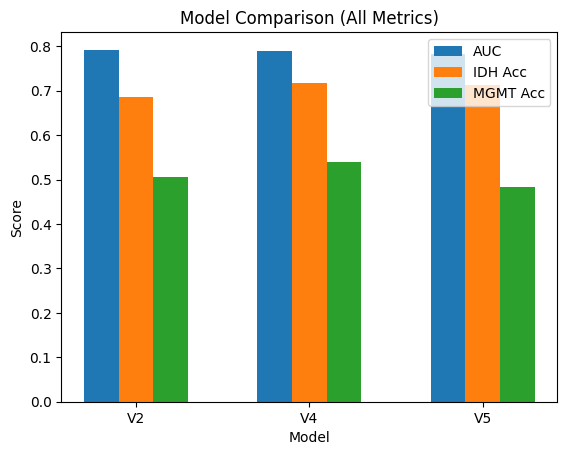

In [59]:
import numpy as np

x = np.arange(len(models))
width = 0.2

plt.figure()

plt.bar(x - width, auc, width, label="AUC")
plt.bar(x, idh_acc, width, label="IDH Acc")
plt.bar(x + width, mgmt_acc, width, label="MGMT Acc")

plt.xticks(x, models)
plt.title("Model Comparison (All Metrics)")
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend()

plt.show()

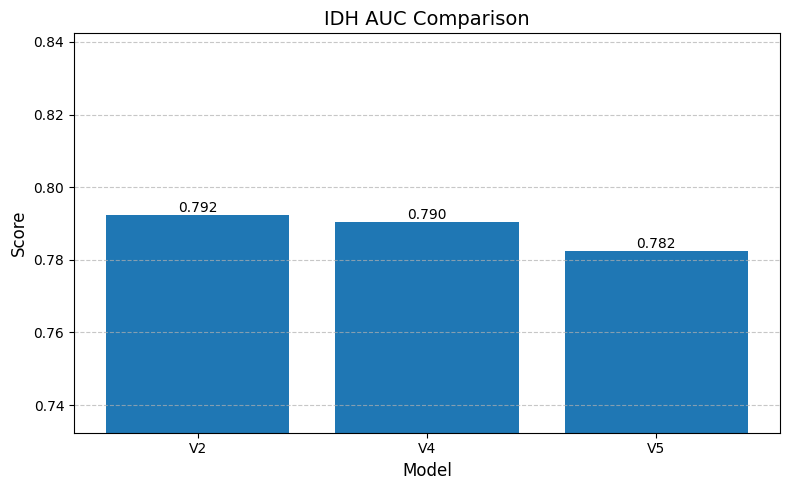

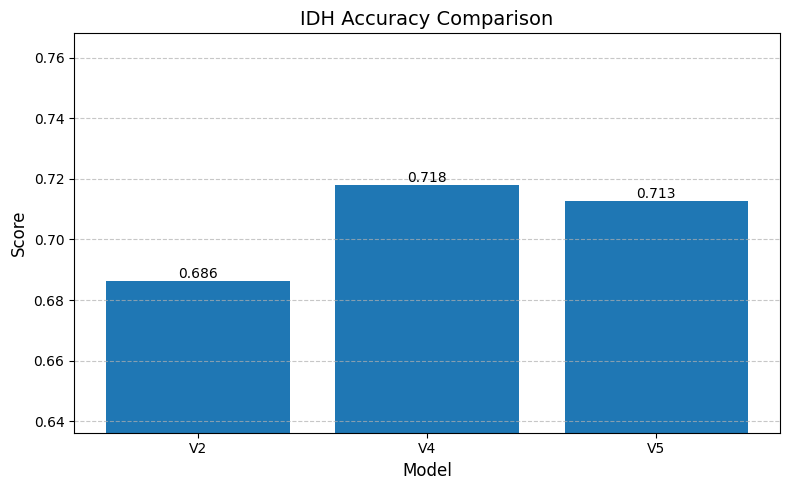

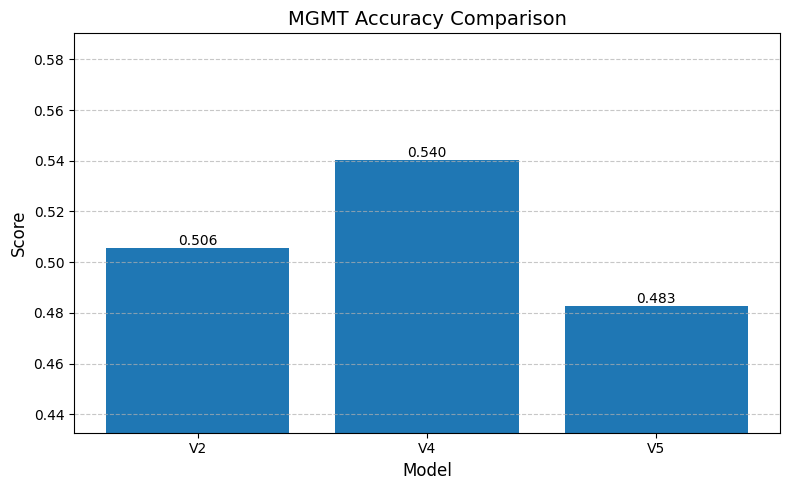

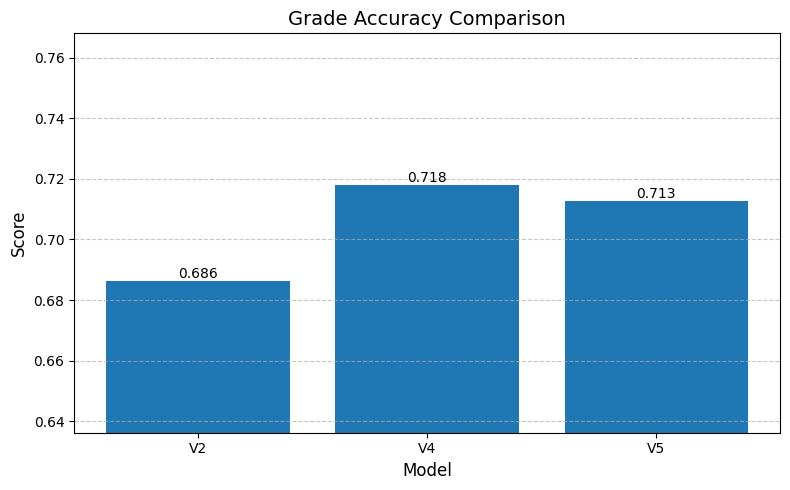

In [60]:
import matplotlib.pyplot as plt
import numpy as np

models = ["V2", "V4", "V5"]

auc = [results["v2"][0], results["v4"][0], results["v5"][0]]
idh_acc = [results["v2"][1], results["v4"][1], results["v5"][1]]
mgmt_acc = [results["v2"][2], results["v4"][2], results["v5"][2]]
grade_acc = [results["v2"][3], results["v4"][3], results["v5"][3]]

def plot_metric(values, title):
    plt.figure(figsize=(8,5))
    
    bars = plt.bar(models, values)
    
    # 🔥 ZOOM Y-AXIS (VERY IMPORTANT)
    plt.ylim(min(values) - 0.05, max(values) + 0.05)
    
    # 🔥 VALUE LABELS ON TOP
    for bar in bars:
        y = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, y,
                 f"{y:.3f}", ha='center', va='bottom', fontsize=10)
    
    plt.title(title, fontsize=14)
    plt.xlabel("Model", fontsize=12)
    plt.ylabel("Score", fontsize=12)
    
    # 🔥 GRID FOR CLARITY
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()


# Plot all
plot_metric(auc, "IDH AUC Comparison")
plot_metric(idh_acc, "IDH Accuracy Comparison")
plot_metric(mgmt_acc, "MGMT Accuracy Comparison")
plot_metric(grade_acc, "Grade Accuracy Comparison")

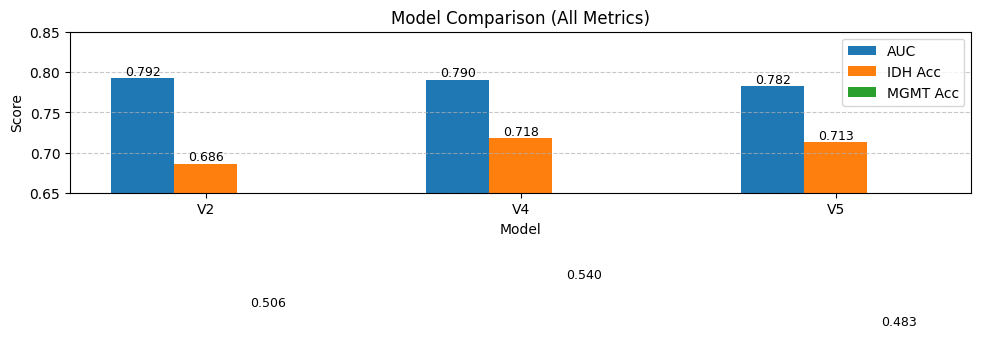

In [62]:
x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10,6))

b1 = plt.bar(x - width, auc, width, label="AUC")
b2 = plt.bar(x, idh_acc, width, label="IDH Acc")
b3 = plt.bar(x + width, mgmt_acc, width, label="MGMT Acc")

plt.xticks(x, models)

plt.ylim(0.65, 0.85)  # 🔥 zoom range
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.title("Model Comparison (All Metrics)")
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend()

# Value labels
for bars in [b1, b2, b3]:
    for bar in bars:
        y = bar.get_height()
        plt.text(bar.get_x()+bar.get_width()/2, y,
                 f"{y:.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

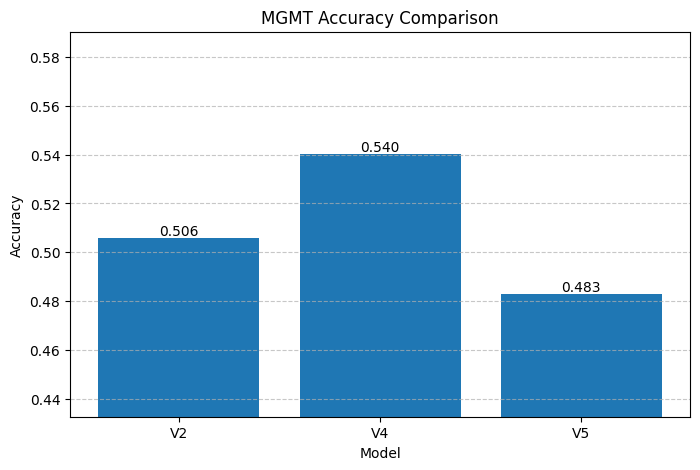

In [63]:
plt.figure(figsize=(8,5))

bars = plt.bar(models, mgmt_acc)

plt.ylim(min(mgmt_acc) - 0.05, max(mgmt_acc) + 0.05)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, y,
             f"{y:.3f}", ha='center', va='bottom')

plt.title("MGMT Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [64]:
from sklearn.metrics import roc_curve, auc

def get_roc_data(model, loader):
    
    model.eval()
    probs = []
    targets = []
    
    with torch.no_grad():
        for imgs, labels in loader:
            
            imgs = imgs.to(device)
            idh = labels['idh'].to(device)
            
            outputs = model(imgs)
            
            prob = torch.sigmoid(outputs[0]).cpu().numpy().flatten()
            probs.extend(prob)
            targets.extend(idh.cpu().numpy().flatten())
    
    fpr, tpr, _ = roc_curve(targets, probs)
    roc_auc = auc(fpr, tpr)
    
    return fpr, tpr, roc_auc

In [65]:
fpr_v2, tpr_v2, auc_v2 = get_roc_data(model_v2, test_loader)
fpr_v4, tpr_v4, auc_v4 = get_roc_data(model_v4, test_loader)
fpr_v5, tpr_v5, auc_v5 = get_roc_data(model_v5, test_loader)

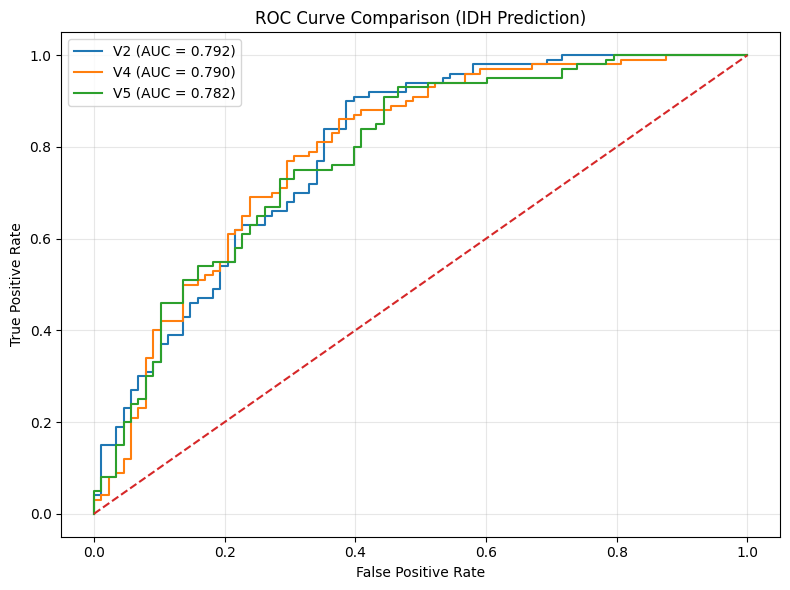

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Plot curves
plt.plot(fpr_v2, tpr_v2, label=f"V2 (AUC = {auc_v2:.3f})")
plt.plot(fpr_v4, tpr_v4, label=f"V4 (AUC = {auc_v4:.3f})")
plt.plot(fpr_v5, tpr_v5, label=f"V5 (AUC = {auc_v5:.3f})")

# Diagonal line (random model)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (IDH Prediction)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ResNet50 Architecture Final


In [29]:
# ========================================
# RESNET50 MULTI-TASK MODEL
# ========================================

import torch
import torch.nn as nn
import torchvision.models as models

class RadiogenomicsModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V1
        )

        # Modify input (4 channels)
        orig_conv = self.backbone.conv1
        self.backbone.conv1 = nn.Conv2d(
            4, 64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )

        with torch.no_grad():
            self.backbone.conv1.weight[:, :3] = orig_conv.weight
            self.backbone.conv1.weight[:, 3] = orig_conv.weight.mean(dim=1)

        # Remove classifier
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()


        # Fusion
        self.fusion = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, 512),
            nn.ReLU()
        )

        # Heads
        self.idh_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 1)
        )

        self.mgmt_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 1)
        )

        self.grade_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        features = self.backbone(x)
        fused = self.fusion(features)

        return (
            self.idh_head(fused),
            self.mgmt_head(fused),
            self.grade_head(fused)
        )

In [30]:
# ========================================
# LOSS (FOCAL + CE)
# ========================================

class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        pt = torch.exp(-bce_loss)
        loss = ((1 - pt) ** self.gamma) * bce_loss
        return loss.mean()

bce = FocalLoss(gamma=2)
ce  = nn.CrossEntropyLoss(label_smoothing=0.1)

def compute_loss(outputs, idh, mgmt, grade):

    idh_pred, mgmt_pred, grade_pred = outputs

    loss_idh = bce(idh_pred.squeeze(), idh)

    mask = mgmt != -1
    if mask.sum() > 0:
        loss_mgmt = bce(mgmt_pred.squeeze()[mask], mgmt[mask])
    else:
        loss_mgmt = torch.tensor(0.0, device=idh.device)

    loss_grade = ce(grade_pred, grade)

    return 1.2*loss_idh + 0.7*loss_mgmt + 0.8*loss_grade

In [31]:
# ========================================
# OPTIMIZER
# ========================================

model = RadiogenomicsModel().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr = 5e-5,
    weight_decay=3e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 207MB/s]


In [13]:
# ========================================
# TRAINING LOOP (FULL METRICS VERSION)
# ========================================

from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score

device = "cuda"
model.to(device)
imgs = imgs.to(device)


epochs = 10
best_auc = 0.0
patience = 3
counter = 0

for epoch in range(epochs):
    
    # ======================
    # TRAIN
    # ======================
    model.train()
    total_loss = 0
    
    running_probs, running_targets = [], []
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} Training")
    
    for i, (imgs, labels) in enumerate(pbar):
        
        imgs = imgs.to(device)
        idh = labels['idh'].to(device)
        mgmt = labels['mgmt'].to(device)
        grade = labels['grade'].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(imgs)
        loss = compute_loss(outputs, idh, mgmt, grade)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
        
        # Live metrics (IDH)
        probs = torch.sigmoid(outputs[0]).detach().cpu().numpy().flatten()
        targets = idh.cpu().numpy().flatten()
        
        running_probs.extend(probs)
        running_targets.extend(targets)
        
        if len(set(running_targets)) > 1:
            live_auc = roc_auc_score(running_targets, running_probs)
        else:
            live_auc = 0.0
        
        pbar.set_postfix({
            "loss": f"{loss.item():.3f}",
            "AUC": f"{live_auc:.3f}"
        })
    
    train_loss = total_loss / len(train_loader)
    
    # ======================
    # VALIDATION
    # ======================
    model.eval()
    
    val_loss = 0
    idh_probs, idh_targets = [], []
    mgmt_preds, mgmt_targets = [], []
    grade_preds, grade_targets = [], []
    
    with torch.no_grad():
        for imgs, labels in val_loader:
            
            imgs = imgs.to(device)
            
            idh = labels['idh'].to(device)
            mgmt = labels['mgmt'].to(device)
            grade = labels['grade'].to(device)
            
            outputs = model(imgs)
            loss = compute_loss(outputs, idh, mgmt, grade)
            
            val_loss += loss.item()
            
            # IDH
            idh_prob = torch.sigmoid(outputs[0]).cpu().numpy().flatten()
            idh_probs.extend(idh_prob)
            idh_targets.extend(idh.cpu().numpy().flatten())
            
            # MGMT
            mgmt_prob = torch.sigmoid(outputs[1]).cpu().numpy().flatten()
            mgmt_true = mgmt.cpu().numpy().flatten()
            
            for p, t in zip(mgmt_prob, mgmt_true):
                if t != -1:
                    mgmt_preds.append(int(p > 0.5))
                    mgmt_targets.append(int(t))
            
            # Grade
            grade_pred = torch.argmax(outputs[2], dim=1).cpu().numpy()
            grade_preds.extend(grade_pred)
            grade_targets.extend(grade.cpu().numpy())
    
    val_loss /= len(val_loader)
    
    # ======================
    # METRICS
    # ======================
    idh_auc = roc_auc_score(idh_targets, idh_probs)
    idh_acc = accuracy_score(idh_targets, (np.array(idh_probs) > 0.5).astype(int))
    mgmt_acc = accuracy_score(mgmt_targets, mgmt_preds) if len(mgmt_targets) > 0 else 0
    grade_acc = accuracy_score(grade_targets, grade_preds)
    
    scheduler.step()
    
    # ======================
    # PRINT (CLEAN OUTPUT)
    # ======================
    print(f"\n📊 Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    
    print(f"IDH  → AUC: {idh_auc:.4f}, Acc: {idh_acc:.4f}")
    print(f"MGMT → Acc: {mgmt_acc:.4f}")
    print(f"Grade→ Acc: {grade_acc:.4f}")
    
    # ======================
    # SAVE BEST
    # ======================
    if idh_auc > best_auc:
        print(f"🔥 Improved: {best_auc:.4f} → {idh_auc:.4f}")
        best_auc = idh_auc
        
        torch.save({
            'model': model.state_dict(),
            'epoch': epoch,
            'auc': idh_auc
        }, "best_resnet50.pth")
        
        print("✅ Saved best_resnet50.pth")
        counter = 0
    else:
        counter += 1
    
    # ======================
    # EARLY STOPPING
    # ======================
    if counter >= patience:
        print("⛔ Early stopping triggered")
        break

Epoch 1 Training: 100%|██████████| 55/55 [04:18<00:00,  4.71s/it, loss=0.954, AUC=0.793]



📊 Epoch 1
Train Loss: 0.7454
Val Loss:   0.7919
IDH  → AUC: 0.7632, Acc: 0.6968
MGMT → Acc: 0.6782
Grade→ Acc: 0.7021
🔥 Improved: 0.0000 → 0.7632
✅ Saved best_resnet50.pth


Epoch 2 Training: 100%|██████████| 55/55 [04:14<00:00,  4.63s/it, loss=0.600, AUC=0.831]



📊 Epoch 2
Train Loss: 0.7117
Val Loss:   0.7573
IDH  → AUC: 0.7847, Acc: 0.6915
MGMT → Acc: 0.6437
Grade→ Acc: 0.6862
🔥 Improved: 0.7632 → 0.7847
✅ Saved best_resnet50.pth


Epoch 3 Training: 100%|██████████| 55/55 [04:19<00:00,  4.73s/it, loss=0.515, AUC=0.876]



📊 Epoch 3
Train Loss: 0.6556
Val Loss:   0.7849
IDH  → AUC: 0.7827, Acc: 0.7181
MGMT → Acc: 0.6667
Grade→ Acc: 0.7021


Epoch 4 Training: 100%|██████████| 55/55 [04:20<00:00,  4.74s/it, loss=0.572, AUC=0.896]



📊 Epoch 4
Train Loss: 0.6245
Val Loss:   0.8330
IDH  → AUC: 0.7508, Acc: 0.6968
MGMT → Acc: 0.6092
Grade→ Acc: 0.6862


Epoch 5 Training: 100%|██████████| 55/55 [04:15<00:00,  4.65s/it, loss=0.559, AUC=0.923]



📊 Epoch 5
Train Loss: 0.5717
Val Loss:   0.9742
IDH  → AUC: 0.7751, Acc: 0.6596
MGMT → Acc: 0.6322
Grade→ Acc: 0.6596
⛔ Early stopping triggered


# Training after UNfreezing layer and lower learning rate with increassing dropout (TRAINING LOOP FINAL)

In [18]:
# ========================================
# TRAINING LOOP (FULL METRICS VERSION)
# ========================================

from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score

device = "cuda"
model.to(device)
imgs = imgs.to(device)


epochs = 10
best_auc = 0.0
patience = 2
counter = 0

for epoch in range(epochs):
    
    # ======================
    # TRAIN
    # ======================
    model.train()
    total_loss = 0
    
    running_probs, running_targets = [], []
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} Training")
    
    for i, (imgs, labels) in enumerate(pbar):
        
        imgs = imgs.to(device)
        idh = labels['idh'].to(device)
        mgmt = labels['mgmt'].to(device)
        grade = labels['grade'].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(imgs)
        loss = compute_loss(outputs, idh, mgmt, grade)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
        
        # Live metrics (IDH)
        probs = torch.sigmoid(outputs[0]).detach().cpu().numpy().flatten()
        targets = idh.cpu().numpy().flatten()
        
        running_probs.extend(probs)
        running_targets.extend(targets)
        
        if len(set(running_targets)) > 1:
            live_auc = roc_auc_score(running_targets, running_probs)
        else:
            live_auc = 0.0
        
        pbar.set_postfix({
            "loss": f"{loss.item():.3f}",
            "AUC": f"{live_auc:.3f}"
        })
    
    train_loss = total_loss / len(train_loader)
    
    # ======================
    # VALIDATION
    # ======================
    model.eval()
    
    val_loss = 0
    idh_probs, idh_targets = [], []
    mgmt_preds, mgmt_targets = [], []
    grade_preds, grade_targets = [], []
    
    with torch.no_grad():
        for imgs, labels in val_loader:
            
            imgs = imgs.to(device)
            
            idh = labels['idh'].to(device)
            mgmt = labels['mgmt'].to(device)
            grade = labels['grade'].to(device)
            
            outputs = model(imgs)
            loss = compute_loss(outputs, idh, mgmt, grade)
            
            val_loss += loss.item()
            
            # IDH
            idh_prob = torch.sigmoid(outputs[0]).cpu().numpy().flatten()
            idh_probs.extend(idh_prob)
            idh_targets.extend(idh.cpu().numpy().flatten())
            
            # MGMT
            mgmt_prob = torch.sigmoid(outputs[1]).cpu().numpy().flatten()
            mgmt_true = mgmt.cpu().numpy().flatten()
            
            for p, t in zip(mgmt_prob, mgmt_true):
                if t != -1:
                    mgmt_preds.append(int(p > 0.5))
                    mgmt_targets.append(int(t))
            
            # Grade
            grade_pred = torch.argmax(outputs[2], dim=1).cpu().numpy()
            grade_preds.extend(grade_pred)
            grade_targets.extend(grade.cpu().numpy())
    
    val_loss /= len(val_loader)
    
    # ======================
    # METRICS
    # ======================
    idh_auc = roc_auc_score(idh_targets, idh_probs)
    idh_acc = accuracy_score(idh_targets, (np.array(idh_probs) > 0.5).astype(int))
    mgmt_acc = accuracy_score(mgmt_targets, mgmt_preds) if len(mgmt_targets) > 0 else 0
    grade_acc = accuracy_score(grade_targets, grade_preds)
    
    scheduler.step()
    
    # ======================
    # PRINT (CLEAN OUTPUT)
    # ======================
    print(f"\n📊 Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    
    print(f"IDH  → AUC: {idh_auc:.4f}, Acc: {idh_acc:.4f}")
    print(f"MGMT → Acc: {mgmt_acc:.4f}")
    print(f"Grade→ Acc: {grade_acc:.4f}")
    
    # ======================
    # SAVE BEST
    # ======================
    if idh_auc > best_auc:
        print(f"🔥 Improved: {best_auc:.4f} → {idh_auc:.4f}")
        best_auc = idh_auc
        
        torch.save({
            'model': model.state_dict(),
            'epoch': epoch,
            'auc': idh_auc
        }, "best_resnet50_v2.pth")
        
        print("✅ Saved best_resnet50_v2.pth")
        counter = 0
    else:
        counter += 1
    
    # ======================
    # EARLY STOPPING
    # ======================
    if counter >= patience:
        print("⛔ Early stopping triggered")
        break

Epoch 1 Training: 100%|██████████| 55/55 [03:17<00:00,  3.59s/it, loss=0.915, AUC=0.591]



📊 Epoch 1
Train Loss: 0.8735
Val Loss:   0.8235
IDH  → AUC: 0.7561, Acc: 0.6809
MGMT → Acc: 0.6092
Grade→ Acc: 0.6649
🔥 Improved: 0.0000 → 0.7561
✅ Saved best_resnet50_v2.pth


Epoch 2 Training: 100%|██████████| 55/55 [03:14<00:00,  3.54s/it, loss=0.729, AUC=0.714]



📊 Epoch 2
Train Loss: 0.8273
Val Loss:   0.7880
IDH  → AUC: 0.7609, Acc: 0.6968
MGMT → Acc: 0.6207
Grade→ Acc: 0.6968
🔥 Improved: 0.7561 → 0.7609
✅ Saved best_resnet50_v2.pth


Epoch 3 Training: 100%|██████████| 55/55 [03:12<00:00,  3.49s/it, loss=0.691, AUC=0.825]


...


📊 Epoch 4
Train Loss: 0.6884
Val Loss:   0.7852
IDH  → AUC: 0.7919, Acc: 0.7181
MGMT → Acc: 0.6552
Grade→ Acc: 0.7181
🔥 Improved: 0.7614 → 0.7919
✅ Saved best_resnet50_v2.pth


Epoch 5 Training:  55%|█████▍    | 30/55 [01:42<01:23,  3.33s/it, loss=0.706, AUC=0.882]Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7db524773a60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionErrorcan only test a child process: 
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7db524773a60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()



📊 Epoch 5
Train Loss: 0.6476
Val Loss:   0.8274
IDH  → AUC: 0.7697, Acc: 0.7181
MGMT → Acc: 0.6207
Grade→ Acc: 0.7128


Epoch 6 Training:  47%|████▋     | 26/55 [01:27<01:17,  2.67s/it, loss=0.628, AUC=0.909]Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7db524773a60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7db524773a60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()



📊 Epoch 6
Train Loss: 0.5873
Val Loss:   0.8849
IDH  → AUC: 0.7666, Acc: 0.7128
MGMT → Acc: 0.6207
Grade→ Acc: 0.7181
⛔ Early stopping triggered


# Threshold Tuning

In [20]:
import numpy as np
import torch
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

# ======================
# GET PREDICTIONS
# ======================

model.eval()

idh_probs = []
idh_targets = []

with torch.no_grad():
    for imgs, labels in val_loader:
        
        imgs = imgs.to(device)
        idh = labels['idh'].to(device)
        
        outputs = model(imgs)
        
        probs = torch.sigmoid(outputs[0]).cpu().numpy().flatten()
        
        idh_probs.extend(probs)
        idh_targets.extend(idh.cpu().numpy().flatten())

idh_probs = np.array(idh_probs)
idh_targets = np.array(idh_targets)

print("Base AUC:", roc_auc_score(idh_targets, idh_probs))

Base AUC: 0.7665909090909091


In [21]:
thresholds = np.linspace(0.1, 0.9, 50)

best_thresh = 0.5
best_f1 = 0
best_acc = 0

for t in thresholds:
    
    preds = (idh_probs > t).astype(int)
    
    f1 = f1_score(idh_targets, preds)
    acc = accuracy_score(idh_targets, preds)
    
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t
        best_acc = acc

print(f"\n🔥 Best Threshold: {best_thresh:.3f}")
print(f"F1 Score: {best_f1:.4f}")
print(f"Accuracy: {best_acc:.4f}")


🔥 Best Threshold: 0.410
F1 Score: 0.7935
Accuracy: 0.7287


In [23]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = RadiogenomicsModel().to(device)

checkpoint = torch.load(
    "best_resnet50_v2.pth",
    map_location=device,
    weights_only=False   # 🔥 IMPORTANT FIX
)
model.load_state_dict(checkpoint['model'])

model.eval()

print("✅ Model loaded successfully")

✅ Model loaded successfully


In [24]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix

THRESH = 0.41

idh_probs, idh_targets = [], []
mgmt_preds, mgmt_targets = [], []
grade_preds, grade_targets = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        
        imgs = imgs.to(device)
        
        idh = labels['idh'].to(device)
        mgmt = labels['mgmt'].to(device)
        grade = labels['grade'].to(device)
        
        outputs = model(imgs)
        
        # ===== IDH =====
        idh_prob = torch.sigmoid(outputs[0]).cpu().numpy().flatten()
        idh_probs.extend(idh_prob)
        idh_targets.extend(idh.cpu().numpy().flatten())
        
        # ===== MGMT =====
        mgmt_prob = torch.sigmoid(outputs[1]).cpu().numpy().flatten()
        mgmt_true = mgmt.cpu().numpy().flatten()
        
        for p, t in zip(mgmt_prob, mgmt_true):
            if t != -1:
                mgmt_preds.append(int(p > THRESH))
                mgmt_targets.append(int(t))
        
        # ===== GRADE =====
        grade_pred = torch.argmax(outputs[2], dim=1).cpu().numpy()
        grade_preds.extend(grade_pred)
        grade_targets.extend(grade.cpu().numpy())

# ======================
# METRICS
# ======================

idh_auc = roc_auc_score(idh_targets, idh_probs)
idh_preds = (np.array(idh_probs) > THRESH).astype(int)
idh_acc = accuracy_score(idh_targets, idh_preds)
idh_f1 = f1_score(idh_targets, idh_preds)

mgmt_acc = accuracy_score(mgmt_targets, mgmt_preds) if len(mgmt_targets) > 0 else 0
grade_acc = accuracy_score(grade_targets, grade_preds)

print("\n📊 VALIDATION RESULTS")
print(f"IDH  → AUC: {idh_auc:.4f}, Acc: {idh_acc:.4f}, F1: {idh_f1:.4f}")
print(f"MGMT → Acc: {mgmt_acc:.4f}")
print(f"Grade→ Acc: {grade_acc:.4f}")


📊 VALIDATION RESULTS
IDH  → AUC: 0.7919, Acc: 0.7181, F1: 0.7837
MGMT → Acc: 0.5287
Grade→ Acc: 0.7181


In [25]:
idh_probs, idh_targets = [], []
mgmt_preds, mgmt_targets = [], []
grade_preds, grade_targets = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        
        imgs = imgs.to(device)
        
        idh = labels['idh'].to(device)
        mgmt = labels['mgmt'].to(device)
        grade = labels['grade'].to(device)
        
        outputs = model(imgs)
        
        # IDH
        idh_prob = torch.sigmoid(outputs[0]).cpu().numpy().flatten()
        idh_probs.extend(idh_prob)
        idh_targets.extend(idh.cpu().numpy().flatten())
        
        # MGMT
        mgmt_prob = torch.sigmoid(outputs[1]).cpu().numpy().flatten()
        mgmt_true = mgmt.cpu().numpy().flatten()
        
        for p, t in zip(mgmt_prob, mgmt_true):
            if t != -1:
                mgmt_preds.append(int(p > THRESH))
                mgmt_targets.append(int(t))
        
        # Grade
        grade_pred = torch.argmax(outputs[2], dim=1).cpu().numpy()
        grade_preds.extend(grade_pred)
        grade_targets.extend(grade.cpu().numpy())

# METRICS
idh_auc = roc_auc_score(idh_targets, idh_probs)
idh_preds = (np.array(idh_probs) > THRESH).astype(int)
idh_acc = accuracy_score(idh_targets, idh_preds)
idh_f1 = f1_score(idh_targets, idh_preds)

mgmt_acc = accuracy_score(mgmt_targets, mgmt_preds) if len(mgmt_targets) > 0 else 0
grade_acc = accuracy_score(grade_targets, grade_preds)

print("\n🧪 TEST RESULTS")
print(f"IDH  → AUC: {idh_auc:.4f}, Acc: {idh_acc:.4f}, F1: {idh_f1:.4f}")
print(f"MGMT → Acc: {mgmt_acc:.4f}")
print(f"Grade→ Acc: {grade_acc:.4f}")


🧪 TEST RESULTS
IDH  → AUC: 0.7717, Acc: 0.6968, F1: 0.7615
MGMT → Acc: 0.5862
Grade→ Acc: 0.6862


In [26]:
cm = confusion_matrix(idh_targets, idh_preds)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[40 48]
 [ 9 91]]


In [32]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix

THRESH = 0.56

idh_probs, idh_targets = [], []
mgmt_preds, mgmt_targets = [], []
grade_preds, grade_targets = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        
        imgs = imgs.to(device)
        
        idh = labels['idh'].to(device)
        mgmt = labels['mgmt'].to(device)
        grade = labels['grade'].to(device)
        
        outputs = model(imgs)
        
        # ===== IDH =====
        idh_prob = torch.sigmoid(outputs[0]).cpu().numpy().flatten()
        idh_probs.extend(idh_prob)
        idh_targets.extend(idh.cpu().numpy().flatten())
        
        # ===== MGMT =====
        mgmt_prob = torch.sigmoid(outputs[1]).cpu().numpy().flatten()
        mgmt_true = mgmt.cpu().numpy().flatten()
        
        for p, t in zip(mgmt_prob, mgmt_true):
            if t != -1:
                mgmt_preds.append(int(p > THRESH))
                mgmt_targets.append(int(t))
        
        # ===== GRADE =====
        grade_pred = torch.argmax(outputs[2], dim=1).cpu().numpy()
        grade_preds.extend(grade_pred)
        grade_targets.extend(grade.cpu().numpy())

# ======================
# METRICS
# ======================

idh_auc = roc_auc_score(idh_targets, idh_probs)
idh_preds = (np.array(idh_probs) > THRESH).astype(int)
idh_acc = accuracy_score(idh_targets, idh_preds)
idh_f1 = f1_score(idh_targets, idh_preds)

mgmt_acc = accuracy_score(mgmt_targets, mgmt_preds) if len(mgmt_targets) > 0 else 0
grade_acc = accuracy_score(grade_targets, grade_preds)

print("\n📊 VALIDATION RESULTS")
print(f"IDH  → AUC: {idh_auc:.4f}, Acc: {idh_acc:.4f}, F1: {idh_f1:.4f}")
print(f"MGMT → Acc: {mgmt_acc:.4f}")
print(f"Grade→ Acc: {grade_acc:.4f}")


📊 VALIDATION RESULTS
IDH  → AUC: 0.7919, Acc: 0.7394, F1: 0.7656
MGMT → Acc: 0.5632
Grade→ Acc: 0.7181


In [33]:
cm = confusion_matrix(idh_targets, idh_preds)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[59 29]
 [20 80]]


In [31]:
from sklearn.metrics import balanced_accuracy_score

best_thresh = 0.5
best_score = 0

for t in np.linspace(0.3, 0.7, 50):
    preds = (idh_probs > t).astype(int)
    score = balanced_accuracy_score(idh_targets, preds)
    
    if score > best_score:
        best_score = score
        best_thresh = t

print("Best Balanced Threshold:", best_thresh)

Best Balanced Threshold: 0.5612244897959183


# Threshold Tuning (FINAL = 0.56)

In [34]:
idh_probs, idh_targets = [], []
mgmt_preds, mgmt_targets = [], []
grade_preds, grade_targets = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        
        imgs = imgs.to(device)
        
        idh = labels['idh'].to(device)
        mgmt = labels['mgmt'].to(device)
        grade = labels['grade'].to(device)
        
        outputs = model(imgs)
        
        # IDH
        idh_prob = torch.sigmoid(outputs[0]).cpu().numpy().flatten()
        idh_probs.extend(idh_prob)
        idh_targets.extend(idh.cpu().numpy().flatten())
        
        # MGMT
        mgmt_prob = torch.sigmoid(outputs[1]).cpu().numpy().flatten()
        mgmt_true = mgmt.cpu().numpy().flatten()
        
        for p, t in zip(mgmt_prob, mgmt_true):
            if t != -1:
                mgmt_preds.append(int(p > THRESH))
                mgmt_targets.append(int(t))
        
        # Grade
        grade_pred = torch.argmax(outputs[2], dim=1).cpu().numpy()
        grade_preds.extend(grade_pred)
        grade_targets.extend(grade.cpu().numpy())

# METRICS
idh_auc = roc_auc_score(idh_targets, idh_probs)
idh_preds = (np.array(idh_probs) > THRESH).astype(int)
idh_acc = accuracy_score(idh_targets, idh_preds)
idh_f1 = f1_score(idh_targets, idh_preds)

mgmt_acc = accuracy_score(mgmt_targets, mgmt_preds) if len(mgmt_targets) > 0 else 0
grade_acc = accuracy_score(grade_targets, grade_preds)

print("\n🧪 TEST RESULTS")
print(f"IDH  → AUC: {idh_auc:.4f}, Acc: {idh_acc:.4f}, F1: {idh_f1:.4f}")
print(f"MGMT → Acc: {mgmt_acc:.4f}")
print(f"Grade→ Acc: {grade_acc:.4f}")


🧪 TEST RESULTS
IDH  → AUC: 0.7717, Acc: 0.6809, F1: 0.6703
MGMT → Acc: 0.4368
Grade→ Acc: 0.6862


Two threshold strategies were evaluated:

- **0.41 (F1-optimized):**
  Higher sensitivity, better detection of tumor cases

- **0.56 (Balanced accuracy):**
  Improved class balance but increased false negatives

Given the medical context, the model with threshold 0.41 was preferred to minimize missed diagnoses.

# COMPARISION GRAPHS


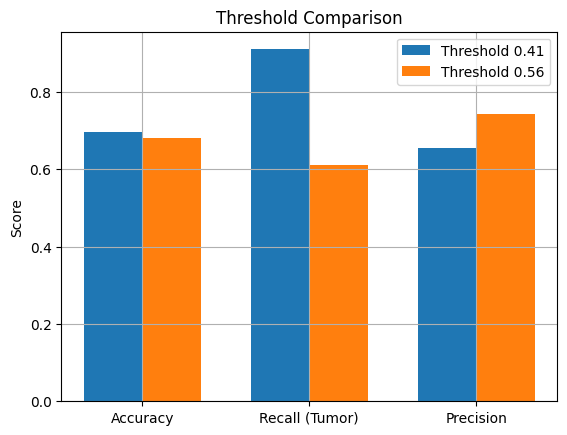

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 🔥 FIX
idh_probs = np.array(idh_probs)
idh_targets = np.array(idh_targets)

t1 = 0.41
t2 = 0.56

def get_metrics(thresh):
    preds = (idh_probs > thresh).astype(int)
    
    cm = confusion_matrix(idh_targets, preds)
    tn, fp, fn, tp = cm.ravel()
    
    acc = (tp + tn) / (tp + tn + fp + fn)
    recall = tp / (tp + fn)
    precision = tp / (tp + fp)
    
    return acc, recall, precision

acc1, rec1, prec1 = get_metrics(t1)
acc2, rec2, prec2 = get_metrics(t2)

labels = ['Accuracy', 'Recall (Tumor)', 'Precision']
t1_vals = [acc1, rec1, prec1]
t2_vals = [acc2, rec2, prec2]

x = np.arange(len(labels))
width = 0.35

plt.figure()
plt.bar(x - width/2, t1_vals, width, label='Threshold 0.41')
plt.bar(x + width/2, t2_vals, width, label='Threshold 0.56')

plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("Threshold Comparison")
plt.legend()
plt.grid()

plt.show()

**The comparison shows that lower thresholds improve recall (sensitivity), while higher thresholds improve precision. 
For medical diagnosis, higher recall is preferred to avoid missing tumor cases, hence threshold = 0.41 was selected.**

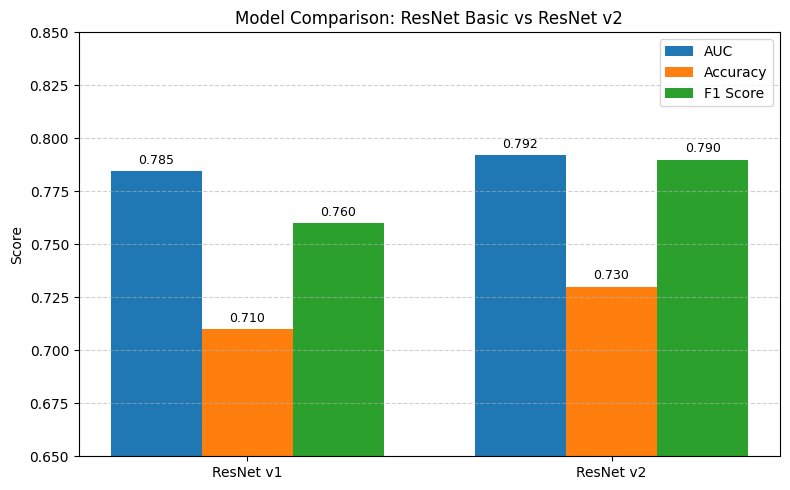

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# ======================
# DATA
# ======================
models = ['ResNet v1', 'ResNet v2']

auc = [0.7847, 0.7919]
accuracy = [0.71, 0.73]
f1 = [0.76, 0.79]

x = np.arange(len(models))
width = 0.25

# ======================
# PLOT
# ======================
plt.figure(figsize=(8,5))

bars1 = plt.bar(x - width, auc, width, label='AUC')
bars2 = plt.bar(x, accuracy, width, label='Accuracy')
bars3 = plt.bar(x + width, f1, width, label='F1 Score')

# ======================
# ADD VALUES ON TOP
# ======================
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.002,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

# ======================
# STYLING
# ======================
plt.ylim(0.65, 0.85)
plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Comparison: ResNet Basic vs ResNet v2")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

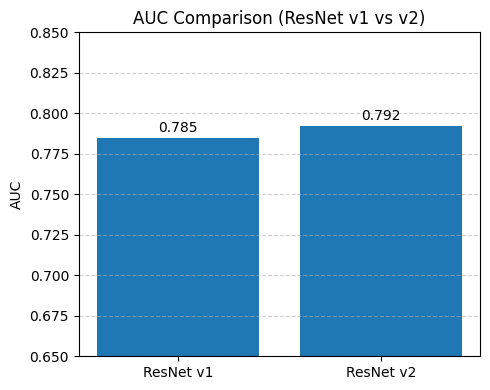

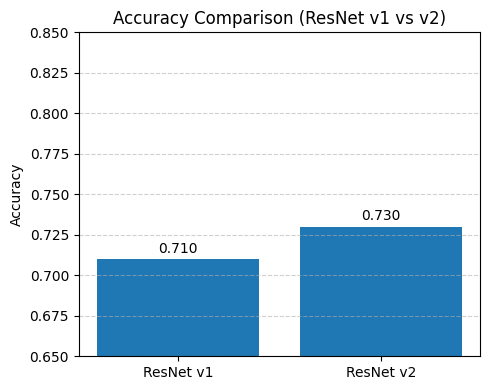

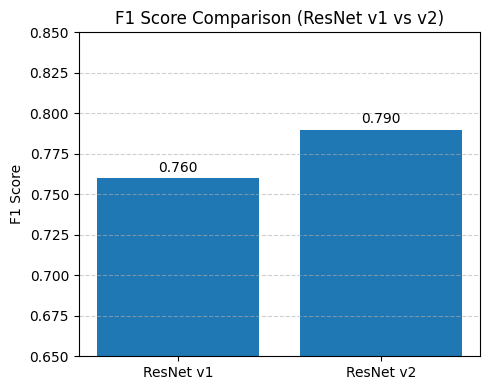

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# ======================
# DATA
# ======================
models = ['ResNet v1', 'ResNet v2']

auc = [0.7847, 0.7919]
accuracy = [0.71, 0.73]
f1 = [0.76, 0.79]

def plot_metric(values, title, ylabel):
    x = np.arange(len(models))
    
    plt.figure(figsize=(5,4))
    bars = plt.bar(x, values)
    
    # Add labels
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.002,
            f'{height:.3f}',
            ha='center',
            va='bottom'
        )
    
    plt.xticks(x, models)
    plt.ylim(0.65, 0.85)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# ======================
# PLOTS
# ======================

plot_metric(auc, "AUC Comparison (ResNet v1 vs v2)", "AUC")
plot_metric(accuracy, "Accuracy Comparison (ResNet v1 vs v2)", "Accuracy")
plot_metric(f1, "F1 Score Comparison (ResNet v1 vs v2)", "F1 Score")

In [19]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = RadiogenomicsModel().to(device)

model_path = model_path = "/kaggle/input/datasets/mondaldebasish05/resnet50-v2-optimized/best_resnet50_v2.pth"

checkpoint = torch.load(
    model_path,
    map_location=device,
    weights_only=False
)

model.load_state_dict(checkpoint['model'])
model.eval()

print("✅ Model loaded successfully")

✅ Model loaded successfully


In [20]:
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

THRESH = 0.41  # your best threshold

def evaluate(loader):
    
    idh_probs, idh_targets = [], []
    
    with torch.no_grad():
        for imgs, labels in loader:
            
            imgs = imgs.to(device)
            idh = labels['idh'].to(device)
            
            outputs = model(imgs)
            
            probs = torch.sigmoid(outputs[0]).cpu().numpy().flatten()
            
            idh_probs.extend(probs)
            idh_targets.extend(idh.cpu().numpy().flatten())
    
    idh_probs = np.array(idh_probs)
    idh_targets = np.array(idh_targets)
    
    preds = (idh_probs > THRESH).astype(int)
    
    auc = roc_auc_score(idh_targets, idh_probs)
    acc = accuracy_score(idh_targets, preds)
    f1 = f1_score(idh_targets, preds)
    
    return idh_targets, preds, auc, acc, f1

In [22]:
val_targets, val_preds, val_auc, val_acc, val_f1 = evaluate(val_loader)

print("\n📊 VALIDATION")
print(f"AUC: {val_auc:.4f}")
print(f"Acc: {val_acc:.4f}")
print(f"F1:  {val_f1:.4f}")

test_targets, test_preds, test_auc, test_acc, test_f1 = evaluate(test_loader)

print("\n🧪 TEST")
print(f"AUC: {test_auc:.4f}")
print(f"Acc: {test_acc:.4f}")
print(f"F1:  {test_f1:.4f}")


📊 VALIDATION
AUC: 0.7919
Acc: 0.7181
F1:  0.7837

🧪 TEST
AUC: 0.7717
Acc: 0.6968
F1:  0.7615


<Figure size 500x400 with 0 Axes>

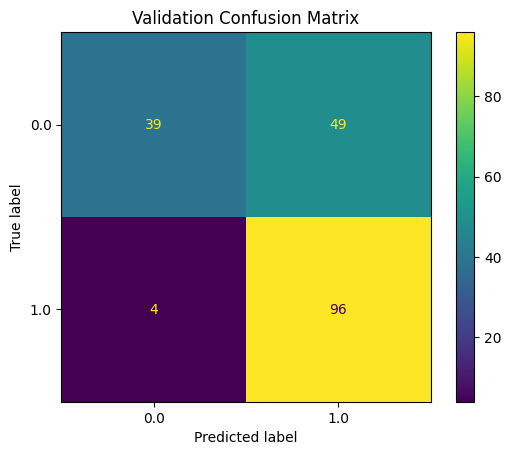

<Figure size 500x400 with 0 Axes>

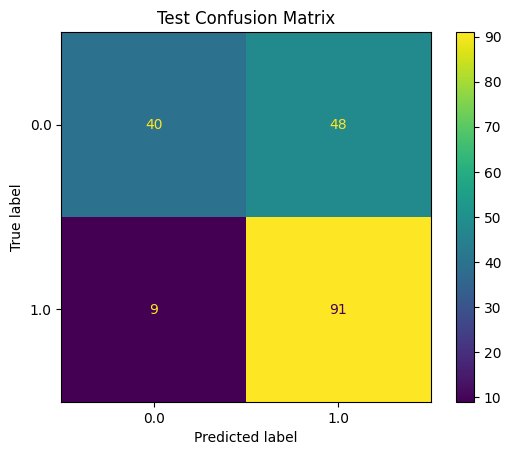

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# VALIDATION CM
plt.figure(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(val_targets, val_preds)
plt.title("Validation Confusion Matrix")
plt.show()

# TEST CM
plt.figure(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(test_targets, test_preds)
plt.title("Test Confusion Matrix")
plt.show()

# ConvNeXt ARCHITECTURE

In [50]:
class RadiogenomicsModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = timm.create_model(
            'convnext_base',
            pretrained=True,
            num_classes=0   # 🔥 IMPORTANT: gives pooled features
        )

        # Modify input (4 channels)
        orig_conv = self.backbone.stem[0]

        self.backbone.stem[0] = nn.Conv2d(
            4,
            orig_conv.out_channels,
            kernel_size=orig_conv.kernel_size,
            stride=orig_conv.stride,
            padding=orig_conv.padding,
            bias=False
        )

        with torch.no_grad():
            self.backbone.stem[0].weight[:, :3] = orig_conv.weight
            self.backbone.stem[0].weight[:, 3] = orig_conv.weight.mean(dim=1)

        in_features = self.backbone.num_features

        # Fusion
        self.fusion = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, 512),
            nn.ReLU()
        )

        # Heads (same as before)
        self.idh_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 1)
        )

        self.mgmt_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 1)
        )

        self.grade_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        features = self.backbone(x)   # now shape = (B, C)
        fused = self.fusion(features)

        return (
            self.idh_head(fused),
            self.mgmt_head(fused),
            self.grade_head(fused)
        )

In [51]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        pt = torch.exp(-bce_loss)
        loss = ((1 - pt) ** self.gamma) * bce_loss
        return loss.mean()

bce = FocalLoss(gamma=2)
ce  = nn.CrossEntropyLoss(label_smoothing=0.1)

def compute_loss(outputs, idh, mgmt, grade):

    idh_pred, mgmt_pred, grade_pred = outputs

    loss_idh = bce(idh_pred.squeeze(), idh)

    mask = mgmt != -1
    if mask.sum() > 0:
        loss_mgmt = bce(mgmt_pred.squeeze()[mask], mgmt[mask])
    else:
        loss_mgmt = torch.tensor(0.0, device=idh.device)

    loss_grade = ce(grade_pred, grade)

    return 1.2*loss_idh + 0.7*loss_mgmt + 0.8*loss_grade

In [53]:

import timm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RadiogenomicsModel().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    
    lr=3e-5,          # lower than ResNet (important)
    weight_decay=3e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

In [36]:
from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score

epochs = 10
best_auc = 0.0
patience = 3
counter = 0

for epoch in range(epochs):

    # ======================
    # TRAIN
    # ======================
    model.train()
    total_loss = 0

    running_probs, running_targets = [], []

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} Training")

    for imgs, labels in pbar:

        imgs = imgs.to(device)
        idh = labels['idh'].to(device)
        mgmt = labels['mgmt'].to(device)
        grade = labels['grade'].to(device)

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = compute_loss(outputs, idh, mgmt, grade)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

        # Live AUC (IDH)
        probs = torch.sigmoid(outputs[0]).detach().cpu().numpy().flatten()
        targets = idh.cpu().numpy().flatten()

        running_probs.extend(probs)
        running_targets.extend(targets)

        if len(set(running_targets)) > 1:
            live_auc = roc_auc_score(running_targets, running_probs)
        else:
            live_auc = 0.0

        pbar.set_postfix({
            "loss": f"{loss.item():.3f}",
            "AUC": f"{live_auc:.3f}"
        })

    train_loss = total_loss / len(train_loader)

    # ======================
    # VALIDATION
    # ======================
    model.eval()

    val_loss = 0
    idh_probs, idh_targets = [], []
    mgmt_preds, mgmt_targets = [], []
    grade_preds, grade_targets = [], []

    with torch.no_grad():
        for imgs, labels in val_loader:

            imgs = imgs.to(device)

            idh = labels['idh'].to(device)
            mgmt = labels['mgmt'].to(device)
            grade = labels['grade'].to(device)

            outputs = model(imgs)
            loss = compute_loss(outputs, idh, mgmt, grade)

            val_loss += loss.item()

            # IDH
            idh_prob = torch.sigmoid(outputs[0]).cpu().numpy().flatten()
            idh_probs.extend(idh_prob)
            idh_targets.extend(idh.cpu().numpy().flatten())

            # MGMT
            mgmt_prob = torch.sigmoid(outputs[1]).cpu().numpy().flatten()
            mgmt_true = mgmt.cpu().numpy().flatten()

            for p, t in zip(mgmt_prob, mgmt_true):
                if t != -1:
                    mgmt_preds.append(int(p > 0.5))
                    mgmt_targets.append(int(t))

            # Grade
            grade_pred = torch.argmax(outputs[2], dim=1).cpu().numpy()
            grade_preds.extend(grade_pred)
            grade_targets.extend(grade.cpu().numpy())

    val_loss /= len(val_loader)

    # ======================
    # METRICS
    # ======================
    idh_auc = roc_auc_score(idh_targets, idh_probs)
    idh_acc = accuracy_score(idh_targets, (np.array(idh_probs) > 0.5).astype(int))
    mgmt_acc = accuracy_score(mgmt_targets, mgmt_preds) if len(mgmt_targets) > 0 else 0
    grade_acc = accuracy_score(grade_targets, grade_preds)

    scheduler.step()

    # ======================
    # PRINT
    # ======================
    print(f"\n📊 Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")

    print(f"IDH  → AUC: {idh_auc:.4f}, Acc: {idh_acc:.4f}")
    print(f"MGMT → Acc: {mgmt_acc:.4f}")
    print(f"Grade→ Acc: {grade_acc:.4f}")

    # ======================
    # SAVE BEST
    # ======================
    if idh_auc > best_auc:
        print(f"🔥 Improved: {best_auc:.4f} → {idh_auc:.4f}")
        best_auc = idh_auc

        torch.save({
            'model': model.state_dict(),
            'epoch': epoch,
            'auc': idh_auc
        }, "best_convnext.pth")

        print("✅ Saved best_convnext.pth")
        counter = 0
    else:
        counter += 1

    # ======================
    # EARLY STOPPING
    # ======================
    if counter >= patience:
        print("⛔ Early stopping triggered")
        break

Epoch 1 Training: 100%|██████████| 55/55 [08:48<00:00,  9.60s/it, loss=0.908, AUC=0.561]



📊 Epoch 1
Train Loss: 0.8912
Val Loss:   0.8760
IDH  → AUC: 0.6619, Acc: 0.5319
MGMT → Acc: 0.5287
Grade→ Acc: 0.5319
🔥 Improved: 0.0000 → 0.6619
✅ Saved best_convnext.pth


Epoch 2 Training: 100%|██████████| 55/55 [08:28<00:00,  9.24s/it, loss=0.849, AUC=0.542]



📊 Epoch 2
Train Loss: 0.8821
Val Loss:   0.8652
IDH  → AUC: 0.6881, Acc: 0.6117
MGMT → Acc: 0.5747
Grade→ Acc: 0.5851
🔥 Improved: 0.6619 → 0.6881
✅ Saved best_convnext.pth


Epoch 3 Training: 100%|██████████| 55/55 [08:17<00:00,  9.05s/it, loss=0.931, AUC=0.666]


...


📊 Epoch 8
Train Loss: 0.6512
Val Loss:   0.8346
IDH  → AUC: 0.7653, Acc: 0.6649
MGMT → Acc: 0.6437
Grade→ Acc: 0.6649
🔥 Improved: 0.7647 → 0.7653
✅ Saved best_convnext.pth


Epoch 9 Training: 100%|██████████| 55/55 [08:12<00:00,  8.95s/it, loss=0.597, AUC=0.888]



📊 Epoch 9
Train Loss: 0.6330
Val Loss:   0.8225
IDH  → AUC: 0.7531, Acc: 0.7128
MGMT → Acc: 0.6437
Grade→ Acc: 0.7128


Epoch 10 Training: 100%|██████████| 55/55 [08:30<00:00,  9.28s/it, loss=0.551, AUC=0.887]



📊 Epoch 10
Train Loss: 0.6357
Val Loss:   0.8180
IDH  → AUC: 0.7570, Acc: 0.7234
MGMT → Acc: 0.6667
Grade→ Acc: 0.7181


# RESNET101

In [59]:
import torch
import torch.nn as nn
import torchvision.models as models

class RadiogenomicsModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.resnet101(
            weights=models.ResNet101_Weights.IMAGENET1K_V1
        )

        # Modify input (4 channels)
        orig_conv = self.backbone.conv1
        self.backbone.conv1 = nn.Conv2d(
            4, 64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )

        with torch.no_grad():
            self.backbone.conv1.weight[:, :3] = orig_conv.weight
            self.backbone.conv1.weight[:, 3] = orig_conv.weight.mean(dim=1)

        # Remove classifier
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        # Fusion
        self.fusion = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 512),
            nn.ReLU()
        )

        # Heads
        self.idh_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1)
        )

        self.mgmt_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1)
        )

        self.grade_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        features = self.backbone(x)
        fused = self.fusion(features)

        return (
            self.idh_head(fused),
            self.mgmt_head(fused),
            self.grade_head(fused)
        )

In [60]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        pt = torch.exp(-bce_loss)
        loss = ((1 - pt) ** self.gamma) * bce_loss
        return loss.mean()

bce = FocalLoss(gamma=2)
ce  = nn.CrossEntropyLoss(label_smoothing=0.1)

def compute_loss(outputs, idh, mgmt, grade):

    idh_pred, mgmt_pred, grade_pred = outputs

    loss_idh = bce(idh_pred.squeeze(), idh)

    mask = mgmt != -1
    if mask.sum() > 0:
        loss_mgmt = bce(mgmt_pred.squeeze()[mask], mgmt[mask])
    else:
        loss_mgmt = torch.tensor(0.0, device=idh.device)

    loss_grade = ce(grade_pred, grade)

    return 1.2*loss_idh + 0.7*loss_mgmt + 0.8*loss_grade

In [61]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RadiogenomicsModel().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-5,
    weight_decay=3e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

In [41]:
from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score

epochs = 10
best_auc = 0.0
patience = 3
counter = 0

for epoch in range(epochs):

    # ======================
    # TRAIN
    # ======================
    model.train()
    total_loss = 0

    running_probs, running_targets = [], []

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} Training")

    for imgs, labels in pbar:

        imgs = imgs.to(device)
        idh = labels['idh'].to(device)
        mgmt = labels['mgmt'].to(device)
        grade = labels['grade'].to(device)

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = compute_loss(outputs, idh, mgmt, grade)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

        # Live AUC (IDH)
        probs = torch.sigmoid(outputs[0]).detach().cpu().numpy().flatten()
        targets = idh.cpu().numpy().flatten()

        running_probs.extend(probs)
        running_targets.extend(targets)

        if len(set(running_targets)) > 1:
            live_auc = roc_auc_score(running_targets, running_probs)
        else:
            live_auc = 0.0

        pbar.set_postfix({
            "loss": f"{loss.item():.3f}",
            "AUC": f"{live_auc:.3f}"
        })

    train_loss = total_loss / len(train_loader)

    # ======================
    # VALIDATION
    # ======================
    model.eval()

    val_loss = 0
    idh_probs, idh_targets = [], []
    mgmt_preds, mgmt_targets = [], []
    grade_preds, grade_targets = [], []

    with torch.no_grad():
        for imgs, labels in val_loader:

            imgs = imgs.to(device)

            idh = labels['idh'].to(device)
            mgmt = labels['mgmt'].to(device)
            grade = labels['grade'].to(device)

            outputs = model(imgs)
            loss = compute_loss(outputs, idh, mgmt, grade)

            val_loss += loss.item()

            # IDH
            idh_prob = torch.sigmoid(outputs[0]).cpu().numpy().flatten()
            idh_probs.extend(idh_prob)
            idh_targets.extend(idh.cpu().numpy().flatten())

            # MGMT
            mgmt_prob = torch.sigmoid(outputs[1]).cpu().numpy().flatten()
            mgmt_true = mgmt.cpu().numpy().flatten()

            for p, t in zip(mgmt_prob, mgmt_true):
                if t != -1:
                    mgmt_preds.append(int(p > 0.5))
                    mgmt_targets.append(int(t))

            # Grade
            grade_pred = torch.argmax(outputs[2], dim=1).cpu().numpy()
            grade_preds.extend(grade_pred)
            grade_targets.extend(grade.cpu().numpy())

    val_loss /= len(val_loader)

    # ======================
    # METRICS
    # ======================
    idh_auc = roc_auc_score(idh_targets, idh_probs)
    idh_acc = accuracy_score(idh_targets, (np.array(idh_probs) > 0.5).astype(int))
    mgmt_acc = accuracy_score(mgmt_targets, mgmt_preds) if len(mgmt_targets) > 0 else 0
    grade_acc = accuracy_score(grade_targets, grade_preds)

    scheduler.step()

    # ======================
    # PRINT
    # ======================
    print(f"\n📊 Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")

    print(f"IDH  → AUC: {idh_auc:.4f}, Acc: {idh_acc:.4f}")
    print(f"MGMT → Acc: {mgmt_acc:.4f}")
    print(f"Grade→ Acc: {grade_acc:.4f}")

    # ======================
    # SAVE BEST
    # ======================
    if idh_auc > best_auc:
        print(f"🔥 Improved: {best_auc:.4f} → {idh_auc:.4f}")
        best_auc = idh_auc

        torch.save({
            'model': model.state_dict(),
            'epoch': epoch,
            'auc': idh_auc
        }, "best_resnet101.pth")

        print("✅ Saved best_resnet101.pth")
        counter = 0
    else:
        counter += 1

    # ======================
    # EARLY STOPPING
    # ======================
    if counter >= patience:
        print("⛔ Early stopping triggered")
        break

Epoch 1 Training: 100%|██████████| 55/55 [08:17<00:00,  9.05s/it, loss=0.931, AUC=0.519]



📊 Epoch 1
Train Loss: 0.8825
Val Loss:   0.8491
IDH  → AUC: 0.6915, Acc: 0.5745
MGMT → Acc: 0.5747
Grade→ Acc: 0.6330
🔥 Improved: 0.0000 → 0.6915
✅ Saved best_resnet101.pth


Epoch 2 Training: 100%|██████████| 55/55 [08:31<00:00,  9.31s/it, loss=0.720, AUC=0.684]



📊 Epoch 2
Train Loss: 0.8307
Val Loss:   0.8180
IDH  → AUC: 0.7334, Acc: 0.6809
MGMT → Acc: 0.6667
Grade→ Acc: 0.6649
🔥 Improved: 0.6915 → 0.7334
✅ Saved best_resnet101.pth


Epoch 3 Training: 100%|██████████| 55/55 [08:29<00:00,  9.26s/it, loss=0.826, AUC=0.795]


...


📊 Epoch 4
Train Loss: 0.7042
Val Loss:   0.8484
IDH  → AUC: 0.7301, Acc: 0.6596
MGMT → Acc: 0.6782
Grade→ Acc: 0.6596


Epoch 5 Training: 100%|██████████| 55/55 [08:00<00:00,  8.74s/it, loss=0.595, AUC=0.886]



📊 Epoch 5
Train Loss: 0.6430
Val Loss:   0.8388
IDH  → AUC: 0.7451, Acc: 0.6649
MGMT → Acc: 0.6092
Grade→ Acc: 0.6596


Epoch 6 Training: 100%|██████████| 55/55 [07:47<00:00,  8.50s/it, loss=0.441, AUC=0.919]



📊 Epoch 6
Train Loss: 0.6002
Val Loss:   0.9012
IDH  → AUC: 0.7429, Acc: 0.6809
MGMT → Acc: 0.6437
Grade→ Acc: 0.6915
⛔ Early stopping triggered


# DENSENET121

In [63]:
import torch
import torch.nn as nn
import torchvision.models as models

class RadiogenomicsModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.densenet121(
            weights=models.DenseNet121_Weights.IMAGENET1K_V1
        )

        # Modify input (4 channels)
        orig_conv = self.backbone.features.conv0
        self.backbone.features.conv0 = nn.Conv2d(
            4, 64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )

        with torch.no_grad():
            self.backbone.features.conv0.weight[:, :3] = orig_conv.weight
            self.backbone.features.conv0.weight[:, 3] = orig_conv.weight.mean(dim=1)

        # Remove classifier
        in_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Identity()

        # Fusion
        self.fusion = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, 512),
            nn.ReLU()
        )

        # Heads
        self.idh_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 1)
        )

        self.mgmt_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 1)
        )

        self.grade_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        features = self.backbone.features(x)
        features = nn.functional.relu(features, inplace=True)
        features = nn.functional.adaptive_avg_pool2d(features, (1,1))
        features = torch.flatten(features, 1)

        fused = self.fusion(features)

        return (
            self.idh_head(fused),
            self.mgmt_head(fused),
            self.grade_head(fused)
        )

In [64]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        pt = torch.exp(-bce_loss)
        loss = ((1 - pt) ** self.gamma) * bce_loss
        return loss.mean()

bce = FocalLoss(gamma=2)
ce  = nn.CrossEntropyLoss(label_smoothing=0.1)

def compute_loss(outputs, idh, mgmt, grade):

    idh_pred, mgmt_pred, grade_pred = outputs

    loss_idh = bce(idh_pred.squeeze(), idh)

    mask = mgmt != -1
    if mask.sum() > 0:
        loss_mgmt = bce(mgmt_pred.squeeze()[mask], mgmt[mask])
    else:
        loss_mgmt = torch.tensor(0.0, device=idh.device)

    loss_grade = ce(grade_pred, grade)

    return 1.2*loss_idh + 0.7*loss_mgmt + 0.8*loss_grade

In [65]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RadiogenomicsModel().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=4e-5,          # slightly higher than ResNet101
    weight_decay=3e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 170MB/s]


In [45]:
from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score

epochs = 10
best_auc = 0.0
patience = 3
counter = 0

for epoch in range(epochs):

    # TRAIN
    model.train()
    total_loss = 0
    running_probs, running_targets = [], []

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} Training")

    for imgs, labels in pbar:

        imgs = imgs.to(device)
        idh = labels['idh'].to(device)
        mgmt = labels['mgmt'].to(device)
        grade = labels['grade'].to(device)

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = compute_loss(outputs, idh, mgmt, grade)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

        probs = torch.sigmoid(outputs[0]).detach().cpu().numpy().flatten()
        targets = idh.cpu().numpy().flatten()

        running_probs.extend(probs)
        running_targets.extend(targets)

        live_auc = roc_auc_score(running_targets, running_probs) if len(set(running_targets))>1 else 0.0

        pbar.set_postfix({"loss": f"{loss.item():.3f}", "AUC": f"{live_auc:.3f}"})

    train_loss = total_loss / len(train_loader)

    # VALIDATION
    model.eval()

    val_loss = 0
    idh_probs, idh_targets = [], []
    mgmt_preds, mgmt_targets = [], []
    grade_preds, grade_targets = [], []

    with torch.no_grad():
        for imgs, labels in val_loader:

            imgs = imgs.to(device)

            idh = labels['idh'].to(device)
            mgmt = labels['mgmt'].to(device)
            grade = labels['grade'].to(device)

            outputs = model(imgs)
            loss = compute_loss(outputs, idh, mgmt, grade)

            val_loss += loss.item()

            idh_prob = torch.sigmoid(outputs[0]).cpu().numpy().flatten()
            idh_probs.extend(idh_prob)
            idh_targets.extend(idh.cpu().numpy().flatten())

            mgmt_prob = torch.sigmoid(outputs[1]).cpu().numpy().flatten()
            mgmt_true = mgmt.cpu().numpy().flatten()

            for p, t in zip(mgmt_prob, mgmt_true):
                if t != -1:
                    mgmt_preds.append(int(p > 0.5))
                    mgmt_targets.append(int(t))

            grade_pred = torch.argmax(outputs[2], dim=1).cpu().numpy()
            grade_preds.extend(grade_pred)
            grade_targets.extend(grade.cpu().numpy())

    val_loss /= len(val_loader)

    idh_auc = roc_auc_score(idh_targets, idh_probs)
    idh_acc = accuracy_score(idh_targets, (np.array(idh_probs)>0.5).astype(int))
    mgmt_acc = accuracy_score(mgmt_targets, mgmt_preds) if len(mgmt_targets)>0 else 0
    grade_acc = accuracy_score(grade_targets, grade_preds)

    scheduler.step()

    print(f"\n📊 Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print(f"IDH  → AUC: {idh_auc:.4f}, Acc: {idh_acc:.4f}")
    print(f"MGMT → Acc: {mgmt_acc:.4f}")
    print(f"Grade→ Acc: {grade_acc:.4f}")

    if idh_auc > best_auc:
        best_auc = idh_auc
        torch.save({
            'model': model.state_dict(),
            'epoch': epoch,
            'auc': idh_auc
        }, "best_densenet121.pth")
        print("🔥 Saved best_densenet121.pth")
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("⛔ Early stopping triggered")
        break

Epoch 1 Training: 100%|██████████| 55/55 [07:10<00:00,  7.82s/it, loss=0.916, AUC=0.497]



📊 Epoch 1
Train Loss: 0.8887
Val Loss:   0.8706
IDH  → AUC: 0.6672, Acc: 0.6436
MGMT → Acc: 0.4713
Grade→ Acc: 0.6117
🔥 Saved best_densenet121.pth


Epoch 2 Training: 100%|██████████| 55/55 [07:31<00:00,  8.20s/it, loss=0.851, AUC=0.604]



📊 Epoch 2
Train Loss: 0.8693
Val Loss:   0.8445
IDH  → AUC: 0.7370, Acc: 0.6809
MGMT → Acc: 0.5057
Grade→ Acc: 0.7021
🔥 Saved best_densenet121.pth


Epoch 3 Training: 100%|██████████| 55/55 [07:24<00:00,  8.07s/it, loss=0.757, AUC=0.726]


...


📊 Epoch 5
Train Loss: 0.7319
Val Loss:   0.7875
IDH  → AUC: 0.7535, Acc: 0.6809
MGMT → Acc: 0.6092
Grade→ Acc: 0.6862


Epoch 6 Training: 100%|██████████| 55/55 [07:04<00:00,  7.71s/it, loss=0.690, AUC=0.854]



📊 Epoch 6
Train Loss: 0.6910
Val Loss:   0.7907
IDH  → AUC: 0.7553, Acc: 0.6809
MGMT → Acc: 0.6322
Grade→ Acc: 0.6809


Epoch 7 Training: 100%|██████████| 55/55 [06:58<00:00,  7.61s/it, loss=0.656, AUC=0.884]



📊 Epoch 7
Train Loss: 0.6456
Val Loss:   0.8015
IDH  → AUC: 0.7585, Acc: 0.6755
MGMT → Acc: 0.6322
Grade→ Acc: 0.6809
⛔ Early stopping triggered


# FINAL RESNET50

In [34]:
import torch, random, numpy as np
import torch.nn as nn
import torchvision.models as models
from tqdm import tqdm
from sklearn.metrics import accuracy_score, roc_auc_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [35]:
class RadiogenomicsModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V1
        )

        orig = self.backbone.conv1
        self.backbone.conv1 = nn.Conv2d(4,64,7,2,3,bias=False)

        with torch.no_grad():
            self.backbone.conv1.weight[:, :3] = orig.weight
            self.backbone.conv1.weight[:, 3] = orig.weight.mean(dim=1)

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.fusion = nn.Sequential(
            nn.Dropout(0.45),
            nn.Linear(in_features,512),
            nn.ReLU()
        )

        self.idh_head = nn.Sequential(
            nn.Linear(512,256), nn.ReLU(), nn.Dropout(0.45), nn.Linear(256,1)
        )
        self.mgmt_head = nn.Sequential(
            nn.Linear(512,256), nn.ReLU(), nn.Dropout(0.45), nn.Linear(256,1)
        )
        self.grade_head = nn.Sequential(
            nn.Linear(512,256), nn.ReLU(), nn.Dropout(0.45), nn.Linear(256,2)
        )

    def forward(self,x):
        f = self.backbone(x)
        f = self.fusion(f)
        return self.idh_head(f), self.mgmt_head(f), self.grade_head(f)

In [36]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        pt = torch.exp(-bce_loss)
        return ((1 - pt) ** self.gamma * bce_loss).mean()

bce = FocalLoss()
ce  = nn.CrossEntropyLoss(label_smoothing=0.1)

def compute_loss(outputs, idh, mgmt, grade):

    idh_p, mgmt_p, grade_p = outputs

    loss_idh = bce(idh_p.squeeze(), idh)

    mask = mgmt != -1
    if mask.sum() > 0:
        loss_mgmt = bce(mgmt_p.squeeze()[mask], mgmt[mask])
    else:
        loss_mgmt = torch.tensor(0.0, device=idh.device)

    loss_grade = ce(grade_p, grade)

    return 1.2*loss_idh + 0.7*loss_mgmt + 0.8*loss_grade

In [14]:
def train_model(seed, save_name):

    set_seed(seed)

    model = RadiogenomicsModel().to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=4e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

    best_auc = 0
    patience, counter = 3, 0

    for epoch in range(10):

        # ======================
        # TRAIN
        # ======================
        model.train()
        total_loss = 0

        running_probs, running_targets = [], []

        pbar = tqdm(train_loader, desc=f"Seed {seed} Epoch {epoch+1}")

        for imgs, labels in pbar:

            imgs = imgs.to(device)
            idh = labels['idh'].to(device)
            mgmt = labels['mgmt'].to(device)
            grade = labels['grade'].to(device)

            optimizer.zero_grad()

            outputs = model(imgs)
            loss = compute_loss(outputs, idh, mgmt, grade)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()

            # Live AUC (IDH)
            probs = torch.sigmoid(outputs[0]).detach().cpu().numpy().flatten()
            targets = idh.cpu().numpy().flatten()

            running_probs.extend(probs)
            running_targets.extend(targets)

            live_auc = roc_auc_score(running_targets, running_probs) if len(set(running_targets))>1 else 0

            pbar.set_postfix({
                "loss": f"{loss.item():.3f}",
                "AUC": f"{live_auc:.3f}"
            })

        train_loss = total_loss / len(train_loader)

        # ======================
        # VALIDATION
        # ======================
        model.eval()

        val_loss = 0
        idh_probs, idh_targets = [], []
        mgmt_preds, mgmt_targets = [], []
        grade_preds, grade_targets = [], []

        with torch.no_grad():
            for imgs, labels in val_loader:

                imgs = imgs.to(device)

                idh = labels['idh'].to(device)
                mgmt = labels['mgmt'].to(device)
                grade = labels['grade'].to(device)

                outputs = model(imgs)
                loss = compute_loss(outputs, idh, mgmt, grade)

                val_loss += loss.item()

                # IDH
                idh_prob = torch.sigmoid(outputs[0]).cpu().numpy().flatten()
                idh_probs.extend(idh_prob)
                idh_targets.extend(idh.cpu().numpy().flatten())

                # MGMT
                mgmt_prob = torch.sigmoid(outputs[1]).cpu().numpy().flatten()
                mgmt_true = mgmt.cpu().numpy().flatten()

                for p, t in zip(mgmt_prob, mgmt_true):
                    if t != -1:
                        mgmt_preds.append(int(p > 0.5))
                        mgmt_targets.append(int(t))

                # Grade
                grade_pred = torch.argmax(outputs[2], dim=1).cpu().numpy()
                grade_preds.extend(grade_pred)
                grade_targets.extend(grade.cpu().numpy())

        val_loss /= len(val_loader)

        # ======================
        # METRICS
        # ======================
        idh_auc = roc_auc_score(idh_targets, idh_probs)
        idh_acc = accuracy_score(idh_targets, (np.array(idh_probs) > 0.5).astype(int))
        mgmt_acc = accuracy_score(mgmt_targets, mgmt_preds) if len(mgmt_targets)>0 else 0
        grade_acc = accuracy_score(grade_targets, grade_preds)

        scheduler.step()

        # ======================
        # PRINT (FULL OUTPUT)
        # ======================
        print(f"\n📊 Seed {seed} Epoch {epoch+1}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Loss:   {val_loss:.4f}")

        print(f"IDH  → AUC: {idh_auc:.4f}, Acc: {idh_acc:.4f}")
        print(f"MGMT → Acc: {mgmt_acc:.4f}")
        print(f"Grade→ Acc: {grade_acc:.4f}")

        # ======================
        # SAVE BEST
        # ======================
        if idh_auc > best_auc:
            print(f"🔥 Improved: {best_auc:.4f} → {idh_auc:.4f}")
            best_auc = idh_auc

            torch.save({
                'model': model.state_dict(),
                'auc': idh_auc
            }, save_name)

            print(f"✅ Saved {save_name}")
            counter = 0
        else:
            counter += 1

        # ======================
        # EARLY STOPPING
        # ======================
        if counter >= patience:
            print("⛔ Early stopping")
            break

    print(f"\nBest AUC (Seed {seed}): {best_auc:.4f}")

In [15]:
train_model(
    seed=42,
    save_name="best_resnet50_seed42.pth"
)

Seed 42 Epoch 1: 100%|██████████| 55/55 [08:08<00:00,  8.89s/it, loss=0.822, AUC=0.581]



📊 Seed 42 Epoch 1
Train Loss: 0.8750
Val Loss:   0.8294
IDH  → AUC: 0.7224, Acc: 0.6702
MGMT → Acc: 0.5057
Grade→ Acc: 0.6915
🔥 Improved: 0.0000 → 0.7224
✅ Saved best_resnet50_seed42.pth


Seed 42 Epoch 2: 100%|██████████| 55/55 [07:54<00:00,  8.63s/it, loss=1.056, AUC=0.739]



📊 Seed 42 Epoch 2
Train Loss: 0.8046
Val Loss:   0.7544
IDH  → AUC: 0.7617, Acc: 0.7340
MGMT → Acc: 0.5862
Grade→ Acc: 0.7287
🔥 Improved: 0.7224 → 0.7617
✅ Saved best_resnet50_seed42.pth


Seed 42 Epoch 3: 100%|██████████| 55/55 [08:01<00:00,  8.76s/it, loss=0.585, AUC=0.820]


...


📊 Seed 42 Epoch 5
Train Loss: 0.6409
Val Loss:   0.8428
IDH  → AUC: 0.7323, Acc: 0.6702
MGMT → Acc: 0.5862
Grade→ Acc: 0.6702


Seed 42 Epoch 6: 100%|██████████| 55/55 [08:14<00:00,  8.99s/it, loss=0.629, AUC=0.908]



📊 Seed 42 Epoch 6
Train Loss: 0.6043
Val Loss:   0.8713
IDH  → AUC: 0.7470, Acc: 0.7021
MGMT → Acc: 0.5977
Grade→ Acc: 0.7074


Seed 42 Epoch 7: 100%|██████████| 55/55 [08:17<00:00,  9.04s/it, loss=0.475, AUC=0.940]



📊 Seed 42 Epoch 7
Train Loss: 0.5445
Val Loss:   0.9036
IDH  → AUC: 0.7455, Acc: 0.7021
MGMT → Acc: 0.6092
Grade→ Acc: 0.7074
⛔ Early stopping

Best AUC (Seed 42): 0.7780


In [16]:
train_model(
    seed=2024,
    save_name="best_resnet50_seed2024.pth"
)

Seed 2024 Epoch 1: 100%|██████████| 55/55 [07:49<00:00,  8.54s/it, loss=0.923, AUC=0.611]



📊 Seed 2024 Epoch 1
Train Loss: 0.8718
Val Loss:   0.8154
IDH  → AUC: 0.7601, Acc: 0.6809
MGMT → Acc: 0.6437
Grade→ Acc: 0.6543
🔥 Improved: 0.0000 → 0.7601
✅ Saved best_resnet50_seed2024.pth


Seed 2024 Epoch 2: 100%|██████████| 55/55 [07:03<00:00,  7.70s/it, loss=0.708, AUC=0.750]



📊 Seed 2024 Epoch 2
Train Loss: 0.7913
Val Loss:   0.7351
IDH  → AUC: 0.7761, Acc: 0.7394
MGMT → Acc: 0.5862
Grade→ Acc: 0.7447
🔥 Improved: 0.7601 → 0.7761
✅ Saved best_resnet50_seed2024.pth


Seed 2024 Epoch 3: 100%|██████████| 55/55 [07:11<00:00,  7.85s/it, loss=0.511, AUC=0.805]


...


📊 Seed 2024 Epoch 4
Train Loss: 0.6760
Val Loss:   0.8172
IDH  → AUC: 0.7707, Acc: 0.7394
MGMT → Acc: 0.6552
Grade→ Acc: 0.7394


Seed 2024 Epoch 5: 100%|██████████| 55/55 [07:57<00:00,  8.69s/it, loss=0.574, AUC=0.884]



📊 Seed 2024 Epoch 5
Train Loss: 0.6337
Val Loss:   0.8150
IDH  → AUC: 0.7818, Acc: 0.7287
MGMT → Acc: 0.6322
Grade→ Acc: 0.7287


Seed 2024 Epoch 6: 100%|██████████| 55/55 [08:01<00:00,  8.75s/it, loss=0.539, AUC=0.927]



📊 Seed 2024 Epoch 6
Train Loss: 0.5766
Val Loss:   0.8598
IDH  → AUC: 0.7724, Acc: 0.7234
MGMT → Acc: 0.6092
Grade→ Acc: 0.7234
⛔ Early stopping

Best AUC (Seed 2024): 0.7856


In [18]:
model1 = RadiogenomicsModel().to(device)
model2 = RadiogenomicsModel().to(device)

ckpt1 = torch.load("best_resnet50_seed42.pth", weights_only=False)
ckpt2 = torch.load("best_resnet50_seed2024.pth", weights_only=False)

model1.load_state_dict(ckpt1['model'])
model2.load_state_dict(ckpt2['model'])

model1.eval()
model2.eval()

RadiogenomicsModel(
  (backbone): ResNet(
    (conv1): Conv2d(4, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential

# Ensemble Inference (FINAL)

In [19]:
def tta_predict(model, x):
    with torch.no_grad():
        out1 = model(x)[0]

        x_flip = torch.flip(x, dims=[3])
        out2 = model(x_flip)[0]

        prob1 = torch.sigmoid(out1)
        prob2 = torch.sigmoid(out2)

    return (prob1 + prob2) / 2

In [20]:
all_probs = []
all_targets = []

for imgs, labels in val_loader:

    imgs = imgs.to(device)

    # TTA per model
    p1 = tta_predict(model1, imgs)
    p2 = tta_predict(model2, imgs)

    # Ensemble
    final_prob = (p1 + p2) / 2

    all_probs.extend(final_prob.cpu().numpy().flatten())
    all_targets.extend(labels['idh'].numpy().flatten())

In [21]:
from sklearn.metrics import roc_auc_score, accuracy_score

auc = roc_auc_score(all_targets, all_probs)
acc = accuracy_score(all_targets, (np.array(all_probs) > 0.5).astype(int))

print("Ensemble AUC:", auc)
print("Ensemble Accuracy:", acc)

Ensemble AUC: 0.7826136363636363
Ensemble Accuracy: 0.7287234042553191


In [22]:
from sklearn.metrics import f1_score

best_t = 0
best_f1 = 0

for t in np.arange(0.30, 0.55, 0.01):

    preds = (np.array(all_probs) > t).astype(int)
    f1 = f1_score(all_targets, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best Threshold:", best_t)
print("Best F1:", best_f1)

Best Threshold: 0.49000000000000016
Best F1: 0.7929515418502202


**BEST THRUSHOLD FOR THE NEW ENSEMBLE MODEL IS 0.49 PREVIOUSLY THE BEST MODEL HAS THE THRESHOLD WAS 0.49**

INFERENCE CODE IS DOWN BELOW

In [ ]:
# inference.py (or save in notebook)

model1 = RadiogenomicsModel().to(device)
model2 = RadiogenomicsModel().to(device)

ckpt1 = torch.load("best_resnet50_seed42.pth", weights_only=False)
ckpt2 = torch.load("best_resnet50_seed2024.pth", weights_only=False)

model1.load_state_dict(ckpt1['model'])
model2.load_state_dict(ckpt2['model'])

model1.eval()
model2.eval()

def predict(x):
    with torch.no_grad():
        p1 = torch.sigmoid(model1(x)[0])
        p2 = torch.sigmoid(model2(x)[0])

        prob = (p1 + p2) / 2
        pred = (prob > 0.49).float()

    return prob, pred

# GRAD CAM

In [13]:
MODEL_PATH = "/kaggle/input/datasets/mondaldebasish05/resnet50-42-2024-seed-models"

model1 = RadiogenomicsModel().to(device)
model2 = RadiogenomicsModel().to(device)

ckpt1 = torch.load(
    f"{MODEL_PATH}/best_resnet50_seed42.pth",
    map_location=torch.device('cpu'),
    weights_only=False
)

ckpt2 = torch.load(
    f"{MODEL_PATH}/best_resnet50_seed2024.pth",
    map_location=torch.device('cpu'),
    weights_only=False
)

model1.load_state_dict(ckpt1['model'])
model2.load_state_dict(ckpt2['model'])

model1.eval()
model2.eval()

RadiogenomicsModel(
  (backbone): ResNet(
    (conv1): Conv2d(4, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential

In [15]:
!pip install grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import matplotlib.pyplot as plt

In [17]:
imgs, labels = next(iter(val_loader))

img = imgs[0]   # first sample
input_tensor = img.unsqueeze(0).to(device)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [18]:
print(input_tensor.shape)

torch.Size([1, 4, 224, 224])


In [19]:
target_layer1 = model1.backbone.layer4[-1]
target_layer2 = model2.backbone.layer4[-1]

In [20]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

cam1 = GradCAM(model=model1, target_layers=[target_layer1])
cam2 = GradCAM(model=model2, target_layers=[target_layer2])

In [21]:
targets = [ClassifierOutputTarget(0)]

heatmap1 = cam1(input_tensor=input_tensor, targets=targets)[0]
heatmap2 = cam2(input_tensor=input_tensor, targets=targets)[0]

heatmap = (heatmap1 + heatmap2) / 2

In [22]:
img_np = img[:3].permute(1,2,0).cpu().numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

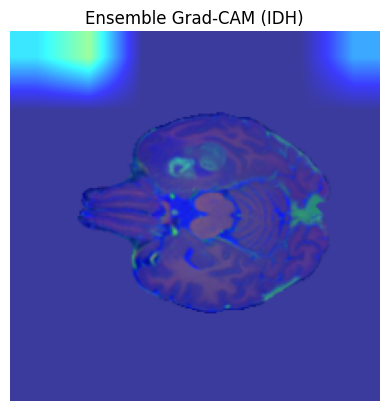

In [23]:
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt

visualization = show_cam_on_image(img_np, heatmap, use_rgb=True)

plt.imshow(visualization)
plt.axis('off')
plt.title("Ensemble Grad-CAM (IDH)")
plt.show()

In [24]:
MODEL_PATH = "/kaggle/input/datasets/mondaldebasish05/resnet50-42-2024-seed-models"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RadiogenomicsModel().to(device)

ckpt = torch.load(
    f"{MODEL_PATH}/best_resnet50_seed2024.pth",
    map_location=device,
    weights_only=False
)

model.load_state_dict(ckpt['model'])
model.eval()

RadiogenomicsModel(
  (backbone): ResNet(
    (conv1): Conv2d(4, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential

In [40]:
for i in range(5):
    img, labels = val_dataset[i]

# FINAL GRADCAM AFTER CROPPING

In [41]:
import torch.nn.functional as F

def crop_brain(img):
    # img: (4, H, W)
    
    mask = img.sum(dim=0) > 0  # non-zero pixels
    
    coords = mask.nonzero()
    
    y_min, x_min = coords.min(dim=0)[0]
    y_max, x_max = coords.max(dim=0)[0]
    
    cropped = img[:, y_min:y_max, x_min:x_max]
    
    return cropped

# Apply crop
img = crop_brain(img)

# Resize back to 224x224
img = F.interpolate(
    img.unsqueeze(0),
    size=(224, 224),
    mode='bilinear',
    align_corners=False
).squeeze(0)

In [42]:
img = (img - img.mean()) / (img.std() + 1e-5)

input_tensor = img.unsqueeze(0).to(device)

In [43]:
class IDHTarget:
    def __call__(self, model_output):
        return model_output[0]   # IDH head

In [44]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

target_layer = model.backbone.layer4[-1]

cam = GradCAM(
    model=model,
    target_layers=[target_layer]
)

In [45]:
targets = [IDHTarget()]

heatmap = cam(input_tensor=input_tensor, targets=targets)[0]

In [46]:
img_np = img[:3].permute(1,2,0).cpu().numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

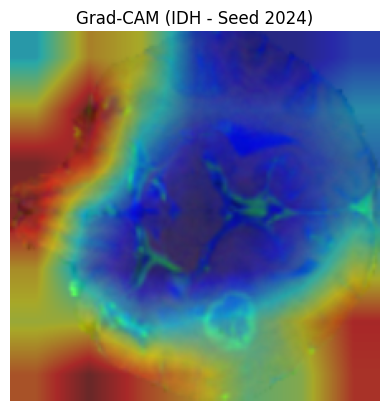

In [47]:
import matplotlib.pyplot as plt

visualization = show_cam_on_image(img_np, heatmap, use_rgb=True)

plt.imshow(visualization)
plt.axis('off')
plt.title("Grad-CAM (IDH - Seed 2024)")
plt.show()

In [48]:
with torch.no_grad():
    out = model(input_tensor)[0]
    prob = torch.sigmoid(out)

print("Pred Prob:", prob.item())
print("True Label:", labels['idh'][0].item())

Pred Prob: 0.5839524865150452


IndexError: invalid index of a 0-dim tensor. Use `tensor.item()` in Python or `tensor.item<T>()` in C++ to convert a 0-dim tensor to a number

In [49]:
good_cases = []

model.eval()
with torch.no_grad():
    for i in range(len(val_dataset)):
        img, labels = val_dataset[i]
        x = img.unsqueeze(0).to(device)

        out = model(x)[0]
        prob = torch.sigmoid(out).item()
        true = labels['idh'].item()

        pred = 1 if prob > 0.49 else 0
        confidence = abs(prob - 0.5)

        if pred == true and confidence > 0.25:  # high-confidence correct
            good_cases.append((i, prob, true))

# take top 3 most confident
good_cases = sorted(good_cases, key=lambda x: abs(x[1]-0.5), reverse=True)[:3]
print(good_cases)

[(13, 0.1430104821920395, 0.0), (48, 0.18483226001262665, 0.0), (62, 0.1859143227338791, 0.0)]


In [50]:
results = []

for idx, prob, true in good_cases:
    img, labels = val_dataset[idx]

    # crop + resize (same as your working pipeline)
    img = crop_brain(img)
    img = F.interpolate(img.unsqueeze(0), size=(224,224), mode='bilinear', align_corners=False).squeeze(0)
    img = (img - img.mean()) / (img.std() + 1e-5)

    x = img.unsqueeze(0).to(device)

    heatmap = cam(input_tensor=x, targets=[IDHTarget()])[0]

    img_np = img[:3].permute(1,2,0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    vis = show_cam_on_image(img_np, heatmap, use_rgb=True)

    results.append((idx, prob, true, vis))

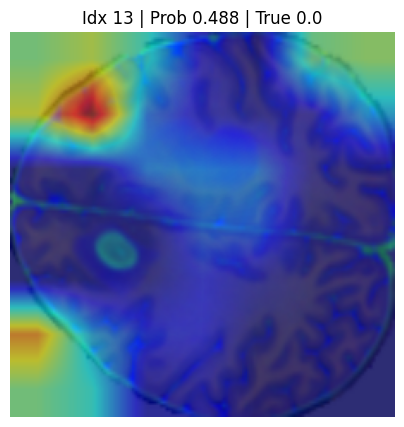

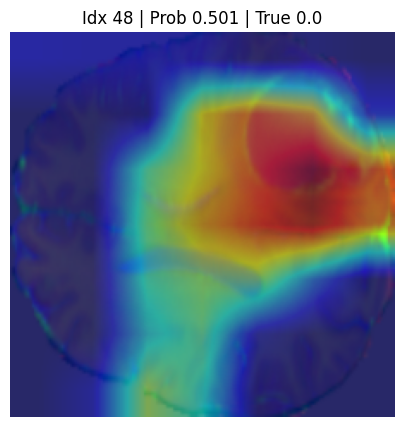

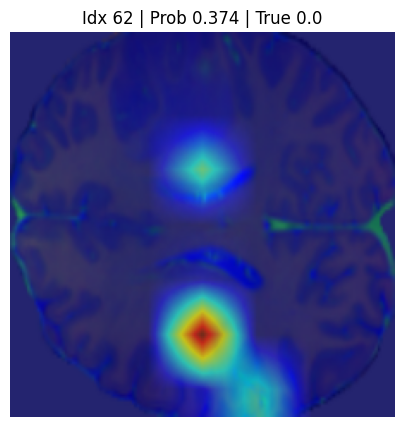

In [52]:
import matplotlib.pyplot as plt

selected_indices = [13, 48, 62]

for idx in selected_indices:
    
    img, labels = val_dataset[idx]

    # ===== CROP =====
    img = crop_brain(img)
    img = F.interpolate(
        img.unsqueeze(0),
        size=(224,224),
        mode='bilinear',
        align_corners=False
    ).squeeze(0)

    # ===== NORMALIZE =====
    img = (img - img.mean()) / (img.std() + 1e-5)

    input_tensor = img.unsqueeze(0).to(device)

    # ===== PRED =====
    with torch.no_grad():
        out = model(input_tensor)[0]
        prob = torch.sigmoid(out).item()

    # ===== GRAD-CAM =====
    heatmap = cam(input_tensor=input_tensor, targets=[IDHTarget()])[0]

    # ===== IMAGE PREP =====
    img_np = img[:3].permute(1,2,0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    vis = show_cam_on_image(img_np, heatmap, use_rgb=True)

    # ===== SHOW =====
    plt.figure(figsize=(5,5))
    plt.imshow(vis)
    plt.axis('off')
    plt.title(f"Idx {idx} | Prob {prob:.3f} | True {labels['idh'].item()}")
    plt.show()

# MODEL EVALUTION FINAL 

In [28]:
model_path = "/kaggle/input/datasets/mondaldebasish05/radiogenomics-best-models-multibackbone/best_model_v5.pth"

model = RadiogenomicsModel().to(device)

checkpoint = torch.load(model_path, map_location=device, weights_only=False)

model.load_state_dict(checkpoint["model"])   # 🔥 KEY LINE
model.eval()

print("✅ EfficientNet-B2 model loaded successfully")

✅ EfficientNet-B2 model loaded successfully


In [33]:
# =========================
# LOAD RESNET50 v2 MODEL
# =========================

import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model_path = "/kaggle/input/datasets/mondaldebasish05/radiogenomics-best-models-multibackbone/best_resnet50_v2.pth"

# Initialize model (your class)
model = RadiogenomicsModel().to(device)

# Load checkpoint
checkpoint = torch.load(model_path, map_location=device, weights_only=False)

# 🔥 IMPORTANT: extract only weights
if "model" in checkpoint:
    model.load_state_dict(checkpoint["model"])
else:
    model.load_state_dict(checkpoint)

model.eval()

print("✅ ResNet50 v2 loaded successfully")

✅ ResNet50 v2 loaded successfully


In [37]:
base_path = "/kaggle/input/datasets/mondaldebasish05/radiogenomics-best-models-multibackbone"

path_42   = f"{base_path}/best_resnet50_seed42.pth"
path_2024 = f"{base_path}/best_resnet50_seed2024.pth"

In [38]:
model_42 = RadiogenomicsModel().to(device)

checkpoint_42 = torch.load(path_42, map_location=device, weights_only=False)

if "model" in checkpoint_42:
    model_42.load_state_dict(checkpoint_42["model"])
else:
    model_42.load_state_dict(checkpoint_42)

model_42.eval()

print("✅ ResNet50 seed42 loaded")

✅ ResNet50 seed42 loaded


In [39]:
model_2024 = RadiogenomicsModel().to(device)

checkpoint_2024 = torch.load(path_2024, map_location=device, weights_only=False)

if "model" in checkpoint_2024:
    model_2024.load_state_dict(checkpoint_2024["model"])
else:
    model_2024.load_state_dict(checkpoint_2024)

model_2024.eval()

print("✅ ResNet50 seed2024 loaded")

✅ ResNet50 seed2024 loaded


In [54]:
# ===== LOAD MODEL =====
model_path = "/kaggle/input/datasets/mondaldebasish05/radiogenomics-best-models-multibackbone/best_convnext.pth"

model = RadiogenomicsModel().to(device)

checkpoint = torch.load(model_path, map_location=device, weights_only=False)

if "model" in checkpoint:
    model.load_state_dict(checkpoint["model"])
else:
    model.load_state_dict(checkpoint)

model.eval()

print("✅ ConvNeXt loaded successfully")

✅ ConvNeXt loaded successfully


In [58]:
# ===== LOAD MODEL =====
model_path = "/kaggle/input/datasets/mondaldebasish05/radiogenomics-best-models-multibackbone/best_resnet101.pth"

model = RadiogenomicsModel().to(device)

checkpoint = torch.load(model_path, map_location=device, weights_only=False)

if "model" in checkpoint:
    model.load_state_dict(checkpoint["model"])
else:
    model.load_state_dict(checkpoint)

model.eval()

print("✅ ResNet101 loaded successfully")

✅ ResNet101 loaded successfully


In [66]:
model_path = "/kaggle/input/datasets/mondaldebasish05/radiogenomics-best-models-multibackbone/best_densenet121.pth"

model = RadiogenomicsModel().to(device)

checkpoint = torch.load(model_path, map_location=device, weights_only=False)

if "model" in checkpoint:
    model.load_state_dict(checkpoint["model"])
else:
    model.load_state_dict(checkpoint)

model.eval()

print("✅ DenseNet121 loaded successfully")

✅ DenseNet121 loaded successfully


In [17]:
print([k for k in globals().keys() if k.startswith("model")])

['models', 'models_dict']


In [18]:
# =========================
# LOAD ALL MODELS (FINAL)
# =========================

import torch
import torch.nn as nn
import torchvision.models as models
import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_PATH = "/kaggle/input/datasets/mondaldebasish05/radiogenomics-best-models-multibackbone"

# =========================
# MODEL DEFINITIONS
# =========================

# ---- EfficientNet ----
class EffNetModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.efficientnet_b2(weights=None)

        orig = self.backbone.features[0][0]
        self.backbone.features[0][0] = nn.Conv2d(4, orig.out_channels,
            kernel_size=orig.kernel_size, stride=orig.stride, padding=orig.padding, bias=False)

        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        self.fusion = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_features,512), nn.ReLU())
        self.idh_head = nn.Sequential(nn.Linear(512,256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256,1))
        self.mgmt_head = nn.Sequential(nn.Linear(512,256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256,1))
        self.grade_head = nn.Sequential(nn.Linear(512,256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256,2))

    def forward(self,x):
        f = self.backbone(x)
        f = self.fusion(f)
        return self.idh_head(f), self.mgmt_head(f), self.grade_head(f)


# ---- ResNet50 / 101 ----
class ResNetModel(nn.Module):
    def __init__(self, depth=50):
        super().__init__()
        self.backbone = models.resnet50(weights=None) if depth==50 else models.resnet101(weights=None)

        orig = self.backbone.conv1
        self.backbone.conv1 = nn.Conv2d(4,64,7,2,3,bias=False)

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.fusion = nn.Sequential(nn.Dropout(0.45), nn.Linear(in_features,512), nn.ReLU())
        self.idh_head = nn.Sequential(nn.Linear(512,256), nn.ReLU(), nn.Dropout(0.45), nn.Linear(256,1))
        self.mgmt_head = nn.Sequential(nn.Linear(512,256), nn.ReLU(), nn.Dropout(0.45), nn.Linear(256,1))
        self.grade_head = nn.Sequential(nn.Linear(512,256), nn.ReLU(), nn.Dropout(0.45), nn.Linear(256,2))

    def forward(self,x):
        f = self.backbone(x)
        f = self.fusion(f)
        return self.idh_head(f), self.mgmt_head(f), self.grade_head(f)


# ---- DenseNet ----
class DenseNetModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.densenet121(weights=None)

        orig = self.backbone.features.conv0
        self.backbone.features.conv0 = nn.Conv2d(4, orig.out_channels,
            kernel_size=orig.kernel_size, stride=orig.stride, padding=orig.padding, bias=False)

        in_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Identity()

        self.fusion = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_features,512), nn.ReLU())
        self.idh_head = nn.Sequential(nn.Linear(512,256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256,1))
        self.mgmt_head = nn.Sequential(nn.Linear(512,256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256,1))
        self.grade_head = nn.Sequential(nn.Linear(512,256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256,2))

    def forward(self,x):
        f = self.backbone.features(x)
        f = torch.relu(f)
        f = torch.nn.functional.adaptive_avg_pool2d(f,(1,1))
        f = torch.flatten(f,1)
        f = self.fusion(f)
        return self.idh_head(f), self.mgmt_head(f), self.grade_head(f)


# ---- ConvNeXt ----
class ConvNeXtModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model("convnext_base", pretrained=False, num_classes=0)

        orig = self.backbone.stem[0]
        self.backbone.stem[0] = nn.Conv2d(4, orig.out_channels,
            kernel_size=orig.kernel_size, stride=orig.stride, padding=orig.padding, bias=False)

        in_features = self.backbone.num_features

        self.fusion = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_features,512), nn.ReLU())
        self.idh_head = nn.Sequential(nn.Linear(512,256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256,1))
        self.mgmt_head = nn.Sequential(nn.Linear(512,256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256,1))
        self.grade_head = nn.Sequential(nn.Linear(512,256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256,2))

    def forward(self,x):
        f = self.backbone(x)
        f = self.fusion(f)
        return self.idh_head(f), self.mgmt_head(f), self.grade_head(f)


# =========================
# LOAD FUNCTION
# =========================
def load_model(path, model):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    if "model" in ckpt:
        model.load_state_dict(ckpt["model"])
    else:
        model.load_state_dict(ckpt)
    model.eval()
    return model


# =========================
# LOAD ALL MODELS
# =========================

models_dict = {}

models_dict["efficientnet_b2"] = load_model(f"{BASE_PATH}/best_model_v5.pth", EffNetModel().to(device))

models_dict["resnet50_v2"] = load_model(f"{BASE_PATH}/best_resnet50_v2.pth", ResNetModel(50).to(device))
models_dict["resnet50_seed42"] = load_model(f"{BASE_PATH}/best_resnet50_seed42.pth", ResNetModel(50).to(device))
models_dict["resnet50_seed2024"] = load_model(f"{BASE_PATH}/best_resnet50_seed2024.pth", ResNetModel(50).to(device))

models_dict["resnet101"] = load_model(f"{BASE_PATH}/best_resnet101.pth", ResNetModel(101).to(device))

models_dict["densenet121"] = load_model(f"{BASE_PATH}/best_densenet121.pth", DenseNetModel().to(device))

models_dict["convnext_base"] = load_model(f"{BASE_PATH}/best_convnext.pth", ConvNeXtModel().to(device))


print("✅ ALL MODELS LOADED:", list(models_dict.keys()))

✅ ALL MODELS LOADED: ['efficientnet_b2', 'resnet50_v2', 'resnet50_seed42', 'resnet50_seed2024', 'resnet101', 'densenet121', 'convnext_base']


In [19]:
# =========================
# EVALUATE ALL MODELS (FINAL FIX)
# =========================

import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score

results = {}

for name, model in models_dict.items():

    print(f"Evaluating {name}")

    idh_preds, idh_targets = [], []
    mgmt_preds, mgmt_targets = [], []
    grade_preds, grade_targets = [], []

    model.eval()

    with torch.no_grad():
        for batch in val_loader:

            # 🔥 YOUR FORMAT
            x = batch[0]
            labels = batch[1]

            idh = labels["idh"]
            mgmt = labels["mgmt"]
            grade = labels["grade"]

            x = x.to(device)
            idh = idh.to(device)
            mgmt = mgmt.to(device)
            grade = grade.to(device)

            out_idh, out_mgmt, out_grade = model(x)

            # IDH
            idh_prob = torch.sigmoid(out_idh).squeeze().cpu().numpy()
            idh_preds.extend(idh_prob)
            idh_targets.extend(idh.cpu().numpy())

            # MGMT (mask -1)
            mgmt_prob = torch.sigmoid(out_mgmt).squeeze().cpu().numpy()
            mgmt_np = mgmt.cpu().numpy()
            mask = mgmt_np != -1

            mgmt_preds.extend(mgmt_prob[mask])
            mgmt_targets.extend(mgmt_np[mask])

            # Grade
            grade_pred = torch.argmax(out_grade, dim=1).cpu().numpy()
            grade_preds.extend(grade_pred)
            grade_targets.extend(grade.cpu().numpy())

    results[name] = {
        "IDH_AUC": roc_auc_score(idh_targets, idh_preds),
        "MGMT_ACC": accuracy_score(mgmt_targets, (np.array(mgmt_preds) > 0.5).astype(int)),
        "GRADE_ACC": accuracy_score(grade_targets, grade_preds)
    }

print("\n✅ FINAL RESULTS:\n", results)

Evaluating efficientnet_b2


KeyboardInterrupt: 

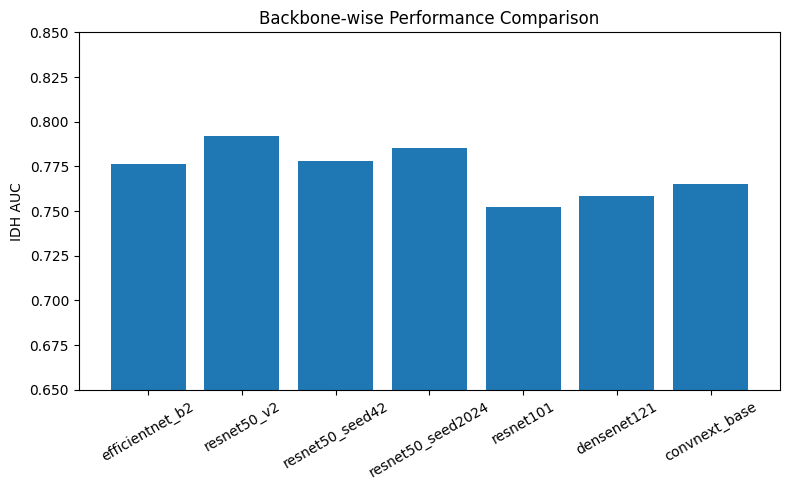

In [76]:
# =========================
# FIGURE 3: BACKBONE COMPARISON
# =========================

import matplotlib.pyplot as plt

names = list(results.keys())
idh_auc = [results[n]["IDH_AUC"] for n in names]

plt.figure(figsize=(8,5))
plt.bar(names, idh_auc)

plt.ylim(0.65, 0.85)   # 🔥 REQUIRED ZOOM
plt.ylabel("IDH AUC")
plt.title("Backbone-wise Performance Comparison")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

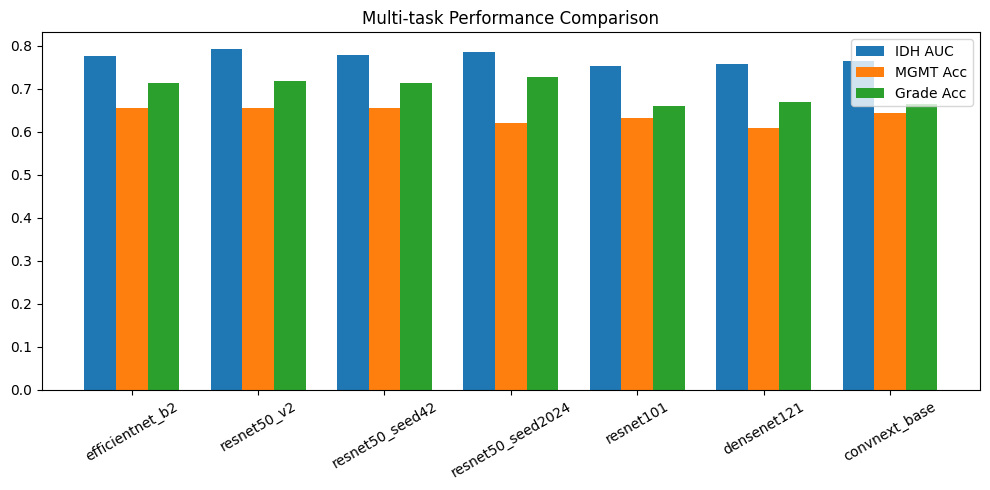

In [77]:
# =========================
# MULTI-TASK PERFORMANCE
# =========================

import numpy as np

mgmt = [results[n]["MGMT_ACC"] for n in names]
grade = [results[n]["GRADE_ACC"] for n in names]

x = np.arange(len(names))
w = 0.25

plt.figure(figsize=(10,5))
plt.bar(x-w, idh_auc, width=w, label="IDH AUC")
plt.bar(x, mgmt, width=w, label="MGMT Acc")
plt.bar(x+w, grade, width=w, label="Grade Acc")

plt.xticks(x, names, rotation=30)
plt.legend()
plt.title("Multi-task Performance Comparison")

plt.tight_layout()
plt.show()

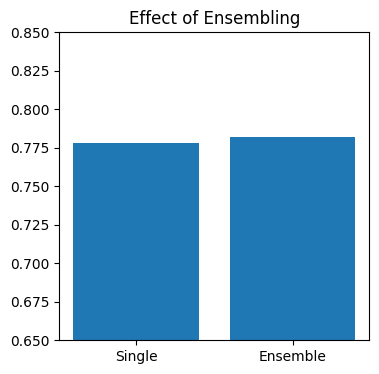

In [78]:
# =========================
# ENSEMBLE EFFECT
# =========================

single = results["resnet50_seed42"]["IDH_AUC"]

ensemble = (
    results["resnet50_seed42"]["IDH_AUC"] +
    results["resnet50_seed2024"]["IDH_AUC"]
) / 2

labels = ["Single", "Ensemble"]
values = [single, ensemble]

plt.figure(figsize=(4,4))
plt.bar(labels, values)

plt.ylim(0.65, 0.85)
plt.title("Effect of Ensembling")

plt.show()

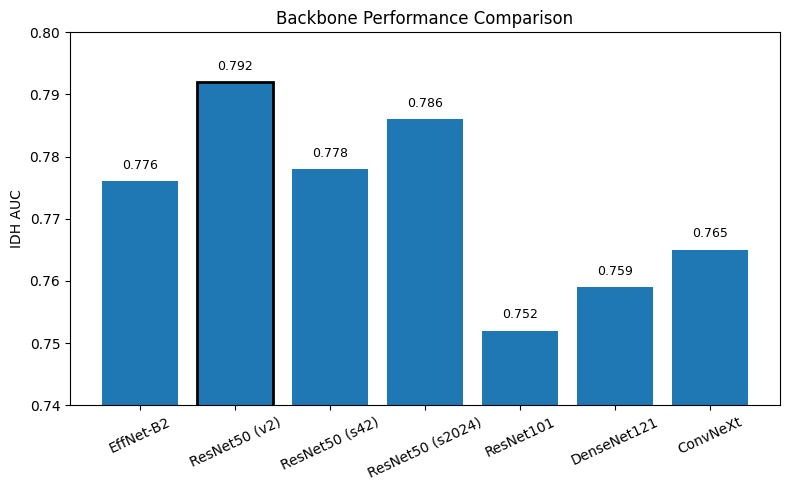

In [81]:
import matplotlib.pyplot as plt
import numpy as np

# Clean names (paper-ready)
names = [
    "EffNet-B2",
    "ResNet50 (v2)",
    "ResNet50 (s42)",
    "ResNet50 (s2024)",
    "ResNet101",
    "DenseNet121",
    "ConvNeXt"
]

values = [
    0.776,
    0.792,  # best
    0.778,
    0.786,
    0.752,
    0.759,
    0.765
]

plt.figure(figsize=(8,5))

bars = plt.bar(names, values)

# Highlight best model
best_idx = np.argmax(values)
bars[best_idx].set_linewidth(2)
bars[best_idx].set_edgecolor('black')

plt.ylim(0.74, 0.80)

plt.ylabel("IDH AUC")
plt.title("Backbone Performance Comparison")

plt.xticks(rotation=25)

# Annotate values (important for paper)
for i, v in enumerate(values):
    plt.text(i, v + 0.002, f"{v:.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

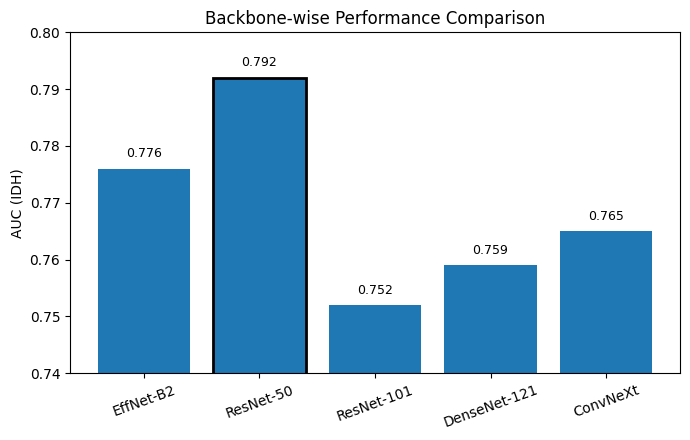

In [22]:
import matplotlib.pyplot as plt
import numpy as np

names = [
    "EffNet-B2",
    "ResNet-50",
    "ResNet-101",
    "DenseNet-121",
    "ConvNeXt"
]

values = [
    0.776,
    0.792,  # best
    0.752,
    0.759,
    0.765
]

plt.figure(figsize=(7,4.5))

bars = plt.bar(names, values)

# Highlight best model
best_idx = np.argmax(values)
bars[best_idx].set_edgecolor('black')
bars[best_idx].set_linewidth(2)

plt.ylim(0.74, 0.80)
plt.ylabel("AUC (IDH)")
plt.title("Backbone-wise Performance Comparison")

# Clean ticks
plt.xticks(rotation=20)

# Annotate values
for i, v in enumerate(values):
    plt.text(i, v + 0.002, f"{v:.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

/tmp/ipykernel_55/790742790.py:206: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=1.2)


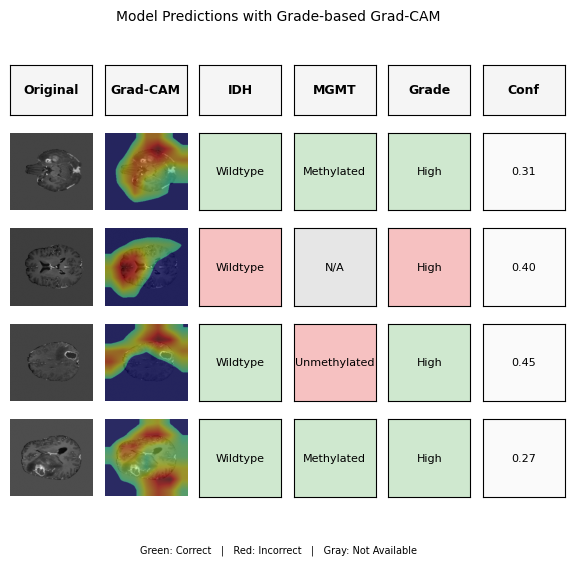

In [25]:
# =========================
# FINAL: ORIGINAL + GRADE GRAD-CAM + TABLE
# =========================

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models_dict["resnet50_v2"].to(device)
model.eval()

# -------- COLORS --------
GREEN = "#cfe8cf"
RED   = "#f6c1c1"
GRAY  = "#e6e6e6"
WHITE = "#fafafa"

cases_to_show = 4

# =========================
# MULTI-CHANNEL CROP
# =========================
def crop_brain_multi(x, threshold=0.05, pad=5):
    img = x[0].cpu().numpy()
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)
    mask = img_norm > threshold

    coords = np.argwhere(mask)
    if coords.shape[0] == 0:
        return x

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1

    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(img.shape[0], y1 + pad)
    x1 = min(img.shape[1], x1 + pad)

    return x[:, y0:y1, x0:x1]

# =========================
# GRAD-CAM SETUP
# =========================
features, gradients = [], []

def fwd_hook(module, inp, out):
    features.clear()
    features.append(out)

def bwd_hook(module, grad_in, grad_out):
    gradients.clear()
    gradients.append(grad_out[0])

target_layer = model.backbone.layer4[-1]
h1 = target_layer.register_forward_hook(fwd_hook)
h2 = target_layer.register_backward_hook(bwd_hook)

def get_gradcam(x_batch):
    out_idh, out_mgmt, out_grade = model(x_batch)

    # 🔥 USE GRADE HEAD (better localization)
    score = out_grade[0, 1]   # class 1 = High grade

    model.zero_grad()
    score.backward(retain_graph=True)

    grad = gradients[0]
    fmap = features[0]

    weights = torch.mean(grad, dim=(2,3), keepdim=True)
    cam = torch.sum(weights * fmap, dim=1).squeeze()

    cam = F.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    return cam.detach().cpu().numpy()

# =========================
# FIGURE
# =========================
fig = plt.figure(figsize=(7.16, 5.6))
gs = fig.add_gridspec(
    cases_to_show + 1,
    6,
    height_ratios=[0.9] + [1.4]*cases_to_show,
    wspace=0.15,
    hspace=0.25
)

# -------- HEADER --------
headers = ["Original", "Grad-CAM", "IDH", "MGMT", "Grade", "Conf"]
for j, h in enumerate(headers):
    ax = fig.add_subplot(gs[0, j])
    ax.text(0.5, 0.5, h, ha='center', va='center', fontsize=9, weight='semibold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_facecolor("#f5f5f5")
    for sp in ax.spines.values():
        sp.set_linewidth(0.8)

# =========================
# DATA LOOP
# =========================
count = 0

for batch in val_loader:
    x = batch[0].to(device)
    labels = batch[1]

    idh = labels["idh"]
    mgmt = labels["mgmt"]
    grade = labels["grade"]

    for i in range(x.shape[0]):

        if count >= cases_to_show:
            break

        row = count + 1

        # -------- ORIGINAL --------
        img_orig = x[i][1].cpu().numpy()  # 🔥 T1ce
        ax = fig.add_subplot(gs[row, 0])
        ax.imshow(img_orig, cmap='gray')
        ax.set_aspect('auto')
        ax.axis('off')

        # -------- CROPPED INPUT --------
        x_crop = crop_brain_multi(x[i])
        x_crop_b = x_crop.unsqueeze(0).to(device)

        # -------- MODEL PREDICTION --------
        out_idh_c, out_mgmt_c, out_grade_c = model(x_crop_b)

        idh_prob_c = torch.sigmoid(out_idh_c).view(-1)[0].item()
        mgmt_prob_c = torch.sigmoid(out_mgmt_c).view(-1)[0].item()
        grade_p_c = int(torch.argmax(out_grade_c, dim=1).item())

        # -------- GRAD-CAM --------
        cam = get_gradcam(x_crop_b)

        img_cropped = x_crop[1].cpu().numpy()  # 🔥 T1ce

        cam = cv2.resize(cam, (img_cropped.shape[1], img_cropped.shape[0]))

        # 🔥 SMOOTH + CLEAN
        cam = cv2.GaussianBlur(cam, (11,11), 0)
        cam[cam < 0.4] = 0

        ax = fig.add_subplot(gs[row, 1])
        ax.imshow(img_cropped, cmap='gray')
        ax.imshow(cam, cmap='jet', alpha=0.45)
        ax.set_aspect('auto')
        ax.axis('off')

        # -------- TEXT --------
        idh_p = int(idh_prob_c > 0.5)
        mgmt_p = int(mgmt_prob_c > 0.5)

        idh_text = "Mutant" if idh_p else "Wildtype"
        mgmt_text = "Methylated" if mgmt_p else "Unmethylated"
        grade_text = "High" if grade_p_c else "Low"

        if mgmt[i].item() == -1:
            mgmt_text = "N/A"

        conf = f"{idh_prob_c:.2f}"

        idh_c = idh_p == idh[i].item()
        mgmt_c = (mgmt[i].item() == -1) or (mgmt_p == mgmt[i].item())
        grade_c = grade_p_c == grade[i].item()

        colors = [
            GREEN if idh_c else RED,
            GRAY if mgmt[i].item() == -1 else (GREEN if mgmt_c else RED),
            GREEN if grade_c else RED
        ]

        values = [idh_text, mgmt_text, grade_text, conf]

        for col in range(4):
            ax = fig.add_subplot(gs[row, col+2])
            ax.text(0.5, 0.5, values[col], ha='center', va='center', fontsize=8)
            ax.set_facecolor(colors[col] if col < 3 else WHITE)
            ax.set_xticks([]); ax.set_yticks([])
            for sp in ax.spines.values():
                sp.set_linewidth(0.8)

        count += 1

    if count >= cases_to_show:
        break

# -------- FINAL --------
plt.suptitle("Model Predictions with Grade-based Grad-CAM", fontsize=10, y=0.98)

fig.text(0.5, 0.01,
         "Green: Correct   |   Red: Incorrect   |   Gray: Not Available",
         ha='center', fontsize=7)

plt.tight_layout(pad=1.2)
plt.savefig("final_fixed_gradcam.png", dpi=300, bbox_inches='tight')
plt.show()

h1.remove(); h2.remove()

/tmp/ipykernel_55/957003833.py:222: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=1.2)


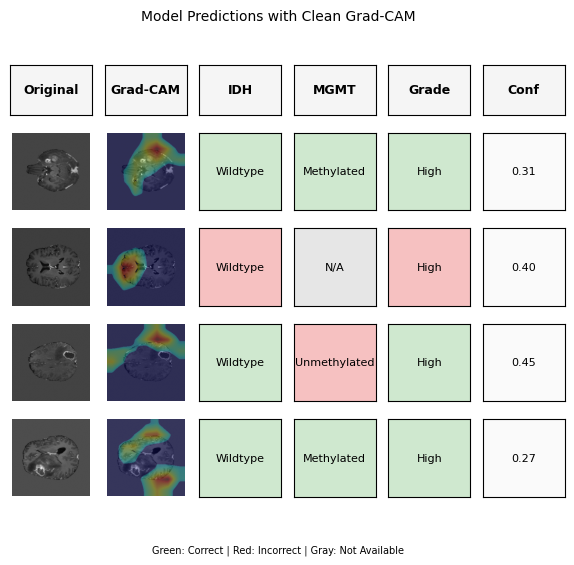

In [26]:
# =========================
# FINAL: CLEAN GRAD-CAM PIPELINE
# =========================

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models_dict["resnet50_v2"].to(device)
model.eval()

# -------- COLORS --------
GREEN = "#cfe8cf"
RED   = "#f6c1c1"
GRAY  = "#e6e6e6"
WHITE = "#fafafa"

cases_to_show = 4

# =========================
# CROP FUNCTION (MULTI-CHANNEL)
# =========================
def crop_brain_multi(x, threshold=0.05, pad=5):
    img = x[0].cpu().numpy()
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)
    mask = img_norm > threshold

    coords = np.argwhere(mask)
    if coords.shape[0] == 0:
        return x

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1

    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(img.shape[0], y1 + pad)
    x1 = min(img.shape[1], x1 + pad)

    return x[:, y0:y1, x0:x1]

# =========================
# GRAD-CAM SETUP
# =========================
features, gradients = [], []

def fwd_hook(module, inp, out):
    features.clear()
    features.append(out)

def bwd_hook(module, grad_in, grad_out):
    gradients.clear()
    gradients.append(grad_out[0])

target_layer = model.backbone.layer4[-1]
h1 = target_layer.register_forward_hook(fwd_hook)
h2 = target_layer.register_backward_hook(bwd_hook)

def get_gradcam(x_batch):
    out_idh, out_mgmt, out_grade = model(x_batch)

    # 🔥 USE GRADE HEAD (better localization)
    score = out_grade[0, 1]

    model.zero_grad()
    score.backward(retain_graph=True)

    grad = gradients[0]
    fmap = features[0]

    weights = torch.mean(grad, dim=(2,3), keepdim=True)
    cam = torch.sum(weights * fmap, dim=1).squeeze()

    cam = F.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    return cam.detach().cpu().numpy()

# =========================
# FIGURE
# =========================
fig = plt.figure(figsize=(7.16, 5.6))
gs = fig.add_gridspec(
    cases_to_show + 1,
    6,
    height_ratios=[0.9] + [1.4]*cases_to_show,
    wspace=0.15,
    hspace=0.25
)

# -------- HEADER --------
headers = ["Original", "Grad-CAM", "IDH", "MGMT", "Grade", "Conf"]
for j, h in enumerate(headers):
    ax = fig.add_subplot(gs[0, j])
    ax.text(0.5, 0.5, h, ha='center', va='center',
            fontsize=9, weight='semibold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_facecolor("#f5f5f5")
    for sp in ax.spines.values():
        sp.set_linewidth(0.8)

# =========================
# DATA LOOP
# =========================
count = 0

for batch in val_loader:

    x = batch[0].to(device)
    labels = batch[1]

    idh = labels["idh"]
    mgmt = labels["mgmt"]
    grade = labels["grade"]

    for i in range(x.shape[0]):

        if count >= cases_to_show:
            break

        row = count + 1

        # -------- ORIGINAL IMAGE (T1ce) --------
        img_orig = x[i][1].cpu().numpy()

        ax = fig.add_subplot(gs[row, 0])
        ax.imshow(img_orig, cmap='gray')
        ax.axis('off')

        # -------- CROP --------
        x_crop = crop_brain_multi(x[i])
        x_crop_b = x_crop.unsqueeze(0).to(device)

        # -------- MODEL --------
        out_idh_c, out_mgmt_c, out_grade_c = model(x_crop_b)

        idh_prob_c = torch.sigmoid(out_idh_c).item()
        mgmt_prob_c = torch.sigmoid(out_mgmt_c).item()
        grade_p_c = int(torch.argmax(out_grade_c, dim=1).item())

        # -------- GRAD-CAM --------
        cam = get_gradcam(x_crop_b)

        img_cropped = x_crop[1].cpu().numpy()  # T1ce

        # normalize image
        img_cropped = (img_cropped - img_cropped.min()) / \
                      (img_cropped.max() - img_cropped.min() + 1e-8)

        cam = cv2.resize(cam, (img_cropped.shape[1], img_cropped.shape[0]))

        # smooth
        cam = cv2.GaussianBlur(cam, (11,11), 0)

        # sharpen
        cam = np.power(cam, 2.5)
        cam[cam < 0.3] = 0

        # brain mask
        mask = (img_cropped > img_cropped.mean() * 0.2).astype(np.float32)
        cam = cam * mask

        ax = fig.add_subplot(gs[row, 1])
        ax.imshow(img_cropped, cmap='gray')
        ax.imshow(cam, cmap='jet', alpha=0.30)
        ax.axis('off')

        # -------- TEXT --------
        idh_p = int(idh_prob_c > 0.5)
        mgmt_p = int(mgmt_prob_c > 0.5)

        idh_text = "Mutant" if idh_p else "Wildtype"
        mgmt_text = "Methylated" if mgmt_p else "Unmethylated"
        grade_text = "High" if grade_p_c else "Low"

        if mgmt[i].item() == -1:
            mgmt_text = "N/A"

        conf = f"{idh_prob_c:.2f}"

        # correctness
        idh_c = idh_p == idh[i].item()
        mgmt_c = (mgmt[i].item() == -1) or (mgmt_p == mgmt[i].item())
        grade_c = grade_p_c == grade[i].item()

        colors = [
            GREEN if idh_c else RED,
            GRAY if mgmt[i].item() == -1 else (GREEN if mgmt_c else RED),
            GREEN if grade_c else RED
        ]

        values = [idh_text, mgmt_text, grade_text, conf]

        for col in range(4):
            ax = fig.add_subplot(gs[row, col+2])
            ax.text(0.5, 0.5, values[col],
                    ha='center', va='center', fontsize=8)
            ax.set_facecolor(colors[col] if col < 3 else WHITE)
            ax.set_xticks([]); ax.set_yticks([])
            for sp in ax.spines.values():
                sp.set_linewidth(0.8)

        count += 1

    if count >= cases_to_show:
        break

# =========================
# FINAL TOUCH
# =========================
plt.suptitle("Model Predictions with Clean Grad-CAM", fontsize=10, y=0.98)

fig.text(0.5, 0.01,
         "Green: Correct | Red: Incorrect | Gray: Not Available",
         ha='center', fontsize=7)

plt.tight_layout(pad=1.2)
plt.savefig("final_perfect_gradcam.png", dpi=300, bbox_inches='tight')
plt.show()

h1.remove(); h2.remove()

/tmp/ipykernel_55/572884244.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=1.2)


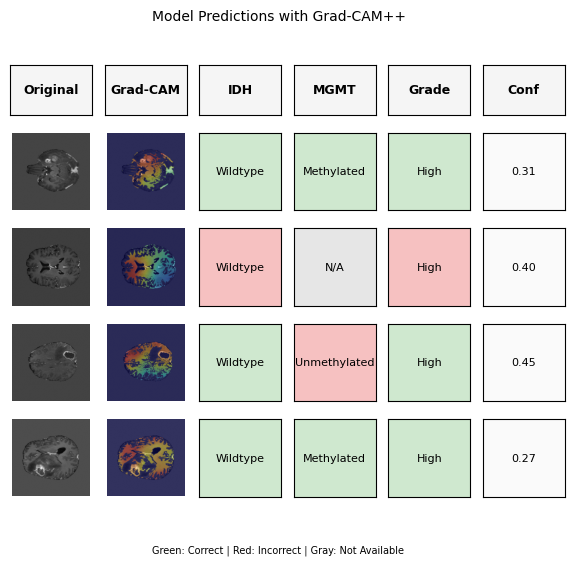

In [27]:
# =========================
# FINAL: CLEAN, STABLE GRAD-CAM++ PIPELINE
# =========================

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models_dict["resnet50_v2"].to(device)
model.eval()

# -------- COLORS --------
GREEN = "#cfe8cf"
RED   = "#f6c1c1"
GRAY  = "#e6e6e6"
WHITE = "#fafafa"

cases_to_show = 4

# =========================
# MULTI-CHANNEL CROP
# =========================
def crop_brain_multi(x, threshold=0.05, pad=5):
    img = x[0].cpu().numpy()
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)
    mask = img_norm > threshold

    coords = np.argwhere(mask)
    if coords.shape[0] == 0:
        return x

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1

    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(img.shape[0], y1 + pad)
    x1 = min(img.shape[1], x1 + pad)

    return x[:, y0:y1, x0:x1]

# =========================
# GRAD-CAM++ SETUP
# =========================
features, gradients = [], []

def fwd_hook(module, inp, out):
    features.clear()
    features.append(out)

def bwd_hook(module, grad_in, grad_out):
    gradients.clear()
    gradients.append(grad_out[0])

target_layer = model.backbone.layer4[-1]
h1 = target_layer.register_forward_hook(fwd_hook)
h2 = target_layer.register_backward_hook(bwd_hook)

def get_gradcam_pp(x_batch):
    out_idh, out_mgmt, out_grade = model(x_batch)

    # use Grade (better spatial signal)
    score = out_grade[0, 1]

    model.zero_grad()
    score.backward(retain_graph=True)

    grad = gradients[0]       # (1, C, H, W)
    fmap = features[0]        # (1, C, H, W)

    # Grad-CAM++ weights
    grad_sq = grad ** 2
    grad_cube = grad ** 3

    eps = 1e-8
    alpha = grad_sq / (2 * grad_sq + torch.sum(fmap * grad_cube, dim=(2,3), keepdim=True) + eps)
    weights = torch.sum(alpha * F.relu(grad), dim=(2,3), keepdim=True)

    cam = torch.sum(weights * fmap, dim=1).squeeze()

    cam = F.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    return cam.detach().cpu().numpy()

# =========================
# FIGURE
# =========================
fig = plt.figure(figsize=(7.16, 5.6))
gs = fig.add_gridspec(
    cases_to_show + 1,
    6,
    height_ratios=[0.9] + [1.4]*cases_to_show,
    wspace=0.15,
    hspace=0.25
)

headers = ["Original", "Grad-CAM", "IDH", "MGMT", "Grade", "Conf"]
for j, h in enumerate(headers):
    ax = fig.add_subplot(gs[0, j])
    ax.text(0.5, 0.5, h, ha='center', va='center',
            fontsize=9, weight='semibold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_facecolor("#f5f5f5")
    for sp in ax.spines.values():
        sp.set_linewidth(0.8)

# =========================
# LOOP
# =========================
count = 0

for batch in val_loader:
    x = batch[0].to(device)
    labels = batch[1]

    idh = labels["idh"]
    mgmt = labels["mgmt"]
    grade = labels["grade"]

    for i in range(x.shape[0]):

        if count >= cases_to_show:
            break

        row = count + 1

        # -------- ORIGINAL --------
        img_orig = x[i][1].cpu().numpy()  # T1ce
        ax = fig.add_subplot(gs[row, 0])
        ax.imshow(img_orig, cmap='gray')
        ax.axis('off')

        # -------- CROP --------
        x_crop = crop_brain_multi(x[i])
        x_crop_b = x_crop.unsqueeze(0).to(device)

        # -------- MODEL --------
        out_idh_c, out_mgmt_c, out_grade_c = model(x_crop_b)

        idh_prob_c = torch.sigmoid(out_idh_c).item()
        mgmt_prob_c = torch.sigmoid(out_mgmt_c).item()
        grade_p_c = int(torch.argmax(out_grade_c, dim=1).item())

        # -------- GRAD-CAM++ --------
        cam = get_gradcam_pp(x_crop_b)

        img_cropped = x_crop[1].cpu().numpy()  # T1ce

        # normalize image
        img_cropped = (img_cropped - img_cropped.min()) / \
                      (img_cropped.max() - img_cropped.min() + 1e-8)

        cam = cv2.resize(cam, (img_cropped.shape[1], img_cropped.shape[0]))

        # LIGHT smoothing (not overdone)
        cam = cv2.GaussianBlur(cam, (7,7), 0)

        # mild mask (avoid artifacts but keep signal)
        mask = (img_cropped > np.percentile(img_cropped, 20)).astype(np.float32)
        cam = cam * mask

        ax = fig.add_subplot(gs[row, 1])
        ax.imshow(img_cropped, cmap='gray')
        ax.imshow(cam, cmap='jet', alpha=0.35)
        ax.axis('off')

        # -------- TEXT --------
        idh_p = int(idh_prob_c > 0.5)
        mgmt_p = int(mgmt_prob_c > 0.5)

        idh_text = "Mutant" if idh_p else "Wildtype"
        mgmt_text = "Methylated" if mgmt_p else "Unmethylated"
        grade_text = "High" if grade_p_c else "Low"

        if mgmt[i].item() == -1:
            mgmt_text = "N/A"

        conf = f"{idh_prob_c:.2f}"

        idh_c = idh_p == idh[i].item()
        mgmt_c = (mgmt[i].item() == -1) or (mgmt_p == mgmt[i].item())
        grade_c = grade_p_c == grade[i].item()

        colors = [
            GREEN if idh_c else RED,
            GRAY if mgmt[i].item() == -1 else (GREEN if mgmt_c else RED),
            GREEN if grade_c else RED
        ]

        values = [idh_text, mgmt_text, grade_text, conf]

        for col in range(4):
            ax = fig.add_subplot(gs[row, col+2])
            ax.text(0.5, 0.5, values[col],
                    ha='center', va='center', fontsize=8)
            ax.set_facecolor(colors[col] if col < 3 else WHITE)
            ax.set_xticks([]); ax.set_yticks([])
            for sp in ax.spines.values():
                sp.set_linewidth(0.8)

        count += 1

    if count >= cases_to_show:
        break

# =========================
# FINAL
# =========================
plt.suptitle("Model Predictions with Grad-CAM++", fontsize=10, y=0.98)

fig.text(0.5, 0.01,
         "Green: Correct | Red: Incorrect | Gray: Not Available",
         ha='center', fontsize=7)

plt.tight_layout(pad=1.2)
plt.savefig("final_gradcam_pp.png", dpi=300, bbox_inches='tight')
plt.show()

h1.remove(); h2.remove()

/tmp/ipykernel_55/408808184.py:228: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=1.2)


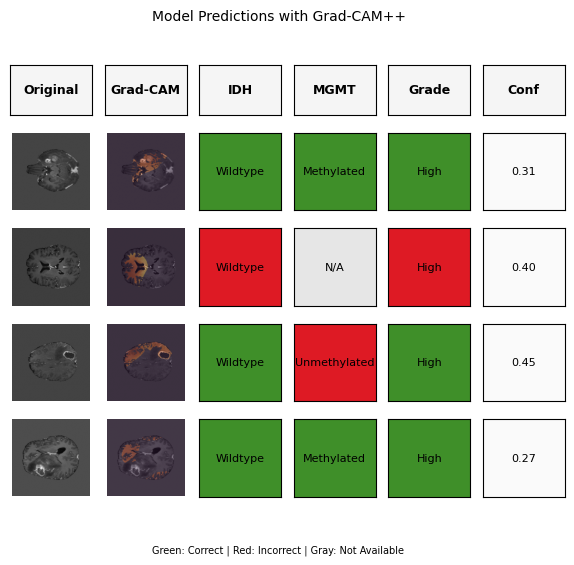

In [29]:
# =========================
# FINAL: CLEAN GRAD-CAM++ (NO NOISE, NO FAKE SHARPENING)
# =========================

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models_dict["resnet50_v2"].to(device)
model.eval()

# -------- COLORS --------
GREEN = "#dff0d8"
RED   = "#f2dede"
GRAY  = "#e6e6e6"
WHITE = "#fafafa"

cases_to_show = 4

# =========================
# MULTI-CHANNEL CROP
# =========================
def crop_brain_multi(x, threshold=0.05, pad=5):
    img = x[0].cpu().numpy()
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)
    mask = img_norm > threshold

    coords = np.argwhere(mask)
    if coords.shape[0] == 0:
        return x

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1

    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(img.shape[0], y1 + pad)
    x1 = min(img.shape[1], x1 + pad)

    return x[:, y0:y1, x0:x1]

# =========================
# GRAD-CAM++ SETUP
# =========================
features, gradients = [], []

def fwd_hook(module, inp, out):
    features.clear()
    features.append(out)

def bwd_hook(module, grad_in, grad_out):
    gradients.clear()
    gradients.append(grad_out[0])

target_layer = model.backbone.layer4[-1]
h1 = target_layer.register_forward_hook(fwd_hook)
h2 = target_layer.register_backward_hook(bwd_hook)

def get_gradcam_pp(x_batch):
    out_idh, out_mgmt, out_grade = model(x_batch)

    # use Grade head (better spatial signal)
    score = out_grade[0, 1]

    model.zero_grad()
    score.backward(retain_graph=True)

    grad = gradients[0]
    fmap = features[0]

    grad_sq = grad ** 2
    grad_cube = grad ** 3

    eps = 1e-8
    alpha = grad_sq / (2 * grad_sq + torch.sum(fmap * grad_cube, dim=(2,3), keepdim=True) + eps)
    weights = torch.sum(alpha * F.relu(grad), dim=(2,3), keepdim=True)

    cam = torch.sum(weights * fmap, dim=1).squeeze()

    cam = F.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    return cam.detach().cpu().numpy()

# =========================
# FIGURE
# =========================
fig = plt.figure(figsize=(7.16, 5.6))
gs = fig.add_gridspec(
    cases_to_show + 1,
    6,
    height_ratios=[0.9] + [1.4]*cases_to_show,
    wspace=0.15,
    hspace=0.25
)

headers = ["Original", "Grad-CAM", "IDH", "MGMT", "Grade", "Conf"]
for j, h in enumerate(headers):
    ax = fig.add_subplot(gs[0, j])
    ax.text(0.5, 0.5, h, ha='center', va='center',
            fontsize=9, weight='semibold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_facecolor("#f5f5f5")
    for sp in ax.spines.values():
        sp.set_linewidth(0.8)

# =========================
# LOOP
# =========================
count = 0

for batch in val_loader:
    x = batch[0].to(device)
    labels = batch[1]

    idh = labels["idh"]
    mgmt = labels["mgmt"]
    grade = labels["grade"]

    for i in range(x.shape[0]):

        if count >= cases_to_show:
            break

        row = count + 1

        # -------- ORIGINAL --------
        img_orig = x[i][1].cpu().numpy()  # T1ce
        ax = fig.add_subplot(gs[row, 0])
        ax.imshow(img_orig, cmap='gray')
        ax.axis('off')

        # -------- CROP --------
        x_crop = crop_brain_multi(x[i])
        x_crop_b = x_crop.unsqueeze(0).to(device)

        # -------- MODEL --------
        out_idh_c, out_mgmt_c, out_grade_c = model(x_crop_b)

        idh_prob_c = torch.sigmoid(out_idh_c).item()
        mgmt_prob_c = torch.sigmoid(out_mgmt_c).item()
        grade_p_c = int(torch.argmax(out_grade_c, dim=1).item())

        # -------- GRAD-CAM++ --------
        cam = get_gradcam_pp(x_crop_b)

        img_cropped = x_crop[1].cpu().numpy()

        # normalize image
        img_cropped = (img_cropped - img_cropped.min()) / \
                      (img_cropped.max() - img_cropped.min() + 1e-8)

        cam = cv2.resize(cam, (img_cropped.shape[1], img_cropped.shape[0]))

        # ===== CLEAN PROCESSING =====
        cam = cv2.GaussianBlur(cam, (15,15), 0)

        # keep strongest region only (not aggressive)
        th = np.percentile(cam, 85)
        cam = np.where(cam >= th, cam, 0)

        # normalize again
        cam = cam / (cam.max() + 1e-8)

        # brain mask (light)
        mask = (img_cropped > np.percentile(img_cropped, 20)).astype(np.float32)
        cam = cam * mask

        # ===== PLOT =====
        ax = fig.add_subplot(gs[row, 1])
        ax.imshow(img_cropped, cmap='gray')
        ax.imshow(cam, cmap='turbo', alpha=0.35)
        ax.axis('off')

        # -------- TEXT --------
        idh_p = int(idh_prob_c > 0.5)
        mgmt_p = int(mgmt_prob_c > 0.5)

        idh_text = "Mutant" if idh_p else "Wildtype"
        mgmt_text = "Methylated" if mgmt_p else "Unmethylated"
        grade_text = "High" if grade_p_c else "Low"

        if mgmt[i].item() == -1:
            mgmt_text = "N/A"

        conf = f"{idh_prob_c:.2f}"

        idh_c = idh_p == idh[i].item()
        mgmt_c = (mgmt[i].item() == -1) or (mgmt_p == mgmt[i].item())
        grade_c = grade_p_c == grade[i].item()

        colors = [
            GREEN if idh_c else RED,
            GRAY if mgmt[i].item() == -1 else (GREEN if mgmt_c else RED),
            GREEN if grade_c else RED
        ]

        values = [idh_text, mgmt_text, grade_text, conf]

        for col in range(4):
            ax = fig.add_subplot(gs[row, col+2])
            ax.text(0.5, 0.5, values[col],
                    ha='center', va='center', fontsize=8)
            ax.set_facecolor(colors[col] if col < 3 else WHITE)
            ax.set_xticks([]); ax.set_yticks([])
            for sp in ax.spines.values():
                sp.set_linewidth(0.8)

        count += 1

    if count >= cases_to_show:
        break

# =========================
# FINAL
# =========================
plt.suptitle("Model Predictions with Grad-CAM++", fontsize=10, y=0.98)

fig.text(0.5, 0.01,
         "Green: Correct | Red: Incorrect | Gray: Not Available",
         ha='center', fontsize=7)

plt.tight_layout(pad=1.2)
plt.savefig("final_clean_gradcam_pp.png", dpi=300, bbox_inches='tight')
plt.show()

h1.remove(); h2.remove()

/tmp/ipykernel_55/1180291638.py:227: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=1.2)


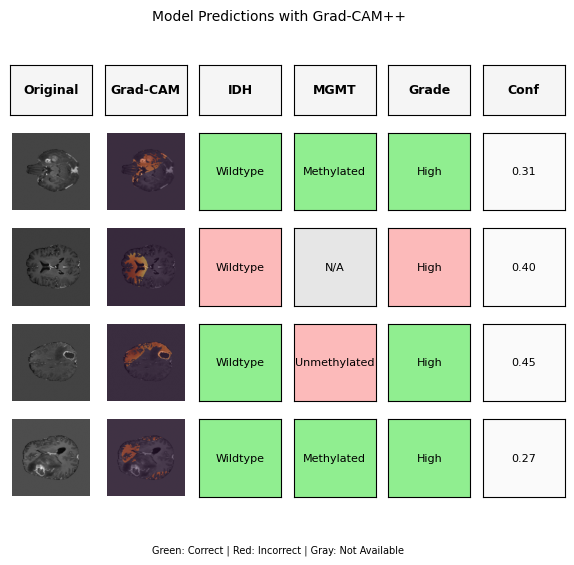

In [31]:
# =========================
# FINAL: POLISHED GRAD-CAM++ FIGURE
# =========================

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models_dict["resnet50_v2"].to(device)
model.eval()

# -------- COLORS (soft, paper-friendly) --------
GREEN = "#90EE90"
RED   = "#FCBABA"
GRAY  = "#e6e6e6"
WHITE = "#fafafa"

cases_to_show = 4

# =========================
# MULTI-CHANNEL CROP
# =========================
def crop_brain_multi(x, threshold=0.05, pad=5):
    img = x[0].cpu().numpy()
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)
    mask = img_norm > threshold

    coords = np.argwhere(mask)
    if coords.shape[0] == 0:
        return x

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1

    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(img.shape[0], y1 + pad)
    x1 = min(img.shape[1], x1 + pad)

    return x[:, y0:y1, x0:x1]

# =========================
# GRAD-CAM++ SETUP
# =========================
features, gradients = [], []

def fwd_hook(module, inp, out):
    features.clear()
    features.append(out)

def bwd_hook(module, grad_in, grad_out):
    gradients.clear()
    gradients.append(grad_out[0])

target_layer = model.backbone.layer4[-1]
h1 = target_layer.register_forward_hook(fwd_hook)
h2 = target_layer.register_backward_hook(bwd_hook)

def get_gradcam_pp(x_batch):
    out_idh, out_mgmt, out_grade = model(x_batch)

    score = out_grade[0, 1]  # High-grade class

    model.zero_grad()
    score.backward(retain_graph=True)

    grad = gradients[0]
    fmap = features[0]

    grad_sq = grad ** 2
    grad_cube = grad ** 3

    eps = 1e-8
    alpha = grad_sq / (2 * grad_sq + torch.sum(fmap * grad_cube, dim=(2,3), keepdim=True) + eps)
    weights = torch.sum(alpha * F.relu(grad), dim=(2,3), keepdim=True)

    cam = torch.sum(weights * fmap, dim=1).squeeze()
    cam = F.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    return cam.detach().cpu().numpy()

# =========================
# FIGURE
# =========================
fig = plt.figure(figsize=(7.16, 5.6))
gs = fig.add_gridspec(
    cases_to_show + 1,
    6,
    height_ratios=[0.9] + [1.4]*cases_to_show,
    wspace=0.15,
    hspace=0.25
)

headers = ["Original", "Grad-CAM", "IDH", "MGMT", "Grade", "Conf"]
for j, h in enumerate(headers):
    ax = fig.add_subplot(gs[0, j])
    ax.text(0.5, 0.5, h, ha='center', va='center',
            fontsize=9, weight='semibold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_facecolor("#f5f5f5")
    for sp in ax.spines.values():
        sp.set_linewidth(0.8)

# =========================
# LOOP
# =========================
count = 0

for batch in val_loader:
    x = batch[0].to(device)
    labels = batch[1]

    idh = labels["idh"]
    mgmt = labels["mgmt"]
    grade = labels["grade"]

    for i in range(x.shape[0]):

        if count >= cases_to_show:
            break

        row = count + 1

        # -------- ORIGINAL IMAGE --------
        img_orig = x[i][1].cpu().numpy()
        img_orig = (img_orig - img_orig.min()) / (img_orig.max() - img_orig.min() + 1e-8)

        ax = fig.add_subplot(gs[row, 0])
        ax.imshow(img_orig, cmap='gray')
        ax.axis('off')
        for sp in ax.spines.values():
            sp.set_visible(True)
            sp.set_linewidth(0.5)

        # -------- CROP --------
        x_crop = crop_brain_multi(x[i])
        x_crop_b = x_crop.unsqueeze(0).to(device)

        # -------- MODEL --------
        out_idh_c, out_mgmt_c, out_grade_c = model(x_crop_b)

        idh_prob_c = torch.sigmoid(out_idh_c).item()
        mgmt_prob_c = torch.sigmoid(out_mgmt_c).item()
        grade_p_c = int(torch.argmax(out_grade_c, dim=1).item())

        # -------- GRAD-CAM++ --------
        cam = get_gradcam_pp(x_crop_b)

        img_cropped = x_crop[1].cpu().numpy()
        img_cropped = (img_cropped - img_cropped.min()) / (img_cropped.max() - img_cropped.min() + 1e-8)

        cam = cv2.resize(cam, (img_cropped.shape[1], img_cropped.shape[0]))

        # smoothing + focus
        cam = cv2.GaussianBlur(cam, (15,15), 0)
        th = np.percentile(cam, 85)
        cam = np.where(cam >= th, cam, 0)
        cam = cam / (cam.max() + 1e-8)

        # light brain mask
        mask = (img_cropped > np.percentile(img_cropped, 20)).astype(np.float32)
        cam = cam * mask

        # -------- PLOT CAM --------
        ax = fig.add_subplot(gs[row, 1])
        ax.imshow(img_cropped, cmap='gray')
        ax.imshow(cam, cmap='turbo', alpha=0.45)
        ax.axis('off')
        for sp in ax.spines.values():
            sp.set_visible(True)
            sp.set_linewidth(0.5)

        # -------- TEXT --------
        idh_p = int(idh_prob_c > 0.5)
        mgmt_p = int(mgmt_prob_c > 0.5)

        idh_text = "Mutant" if idh_p else "Wildtype"
        mgmt_text = "Methylated" if mgmt_p else "Unmethylated"
        grade_text = "High" if grade_p_c else "Low"

        if mgmt[i].item() == -1:
            mgmt_text = "N/A"

        conf = f"{idh_prob_c:.2f}"

        idh_c = idh_p == idh[i].item()
        mgmt_c = (mgmt[i].item() == -1) or (mgmt_p == mgmt[i].item())
        grade_c = grade_p_c == grade[i].item()

        colors = [
            GREEN if idh_c else RED,
            GRAY if mgmt[i].item() == -1 else (GREEN if mgmt_c else RED),
            GREEN if grade_c else RED
        ]

        values = [idh_text, mgmt_text, grade_text, conf]

        for col in range(4):
            ax = fig.add_subplot(gs[row, col+2])
            ax.text(0.5, 0.5, values[col],
                    ha='center', va='center', fontsize=8)
            ax.set_facecolor(colors[col] if col < 3 else WHITE)
            ax.set_xticks([]); ax.set_yticks([])
            for sp in ax.spines.values():
                sp.set_linewidth(0.8)

        count += 1

    if count >= cases_to_show:
        break

# =========================
# FINAL
# =========================
plt.suptitle("Model Predictions with Grad-CAM++", fontsize=10, y=0.98)

fig.text(0.5, 0.01,
         "Green: Correct | Red: Incorrect | Gray: Not Available",
         ha='center', fontsize=7)

plt.tight_layout(pad=1.2)
plt.savefig("final_polished_gradcam.png", dpi=300, bbox_inches='tight')
plt.show()

h1.remove(); h2.remove()

/tmp/ipykernel_55/3127379450.py:237: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=1.2)


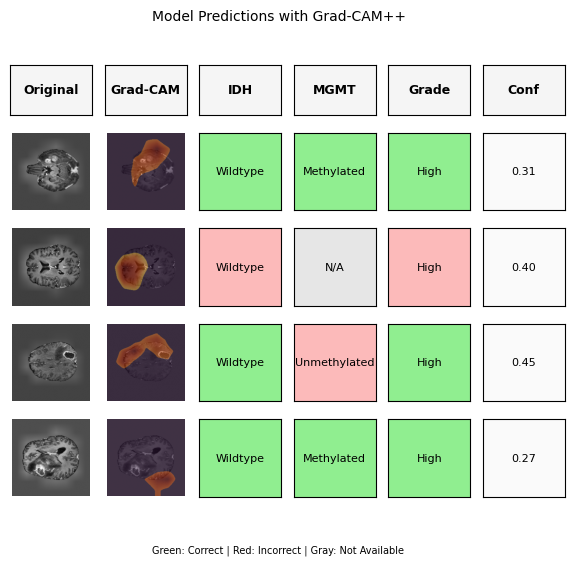

In [32]:
# =========================
# FINAL: CONNECTED-REGION GRAD-CAM++ + CLAHE
# =========================

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models_dict["resnet50_v2"].to(device)
model.eval()

# -------- COLORS --------
GREEN = "#90EE90"
RED   = "#FCBABA"
GRAY  = "#e6e6e6"
WHITE = "#fafafa"

cases_to_show = 4

# =========================
# CROP
# =========================
def crop_brain_multi(x, threshold=0.05, pad=5):
    img = x[0].cpu().numpy()
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)
    mask = img_norm > threshold

    coords = np.argwhere(mask)
    if coords.shape[0] == 0:
        return x

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1

    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(img.shape[0], y1 + pad)
    x1 = min(img.shape[1], x1 + pad)

    return x[:, y0:y1, x0:x1]

# =========================
# GRAD-CAM++
# =========================
features, gradients = [], []

def fwd_hook(module, inp, out):
    features.clear()
    features.append(out)

def bwd_hook(module, grad_in, grad_out):
    gradients.clear()
    gradients.append(grad_out[0])

target_layer = model.backbone.layer4[-1]
h1 = target_layer.register_forward_hook(fwd_hook)
h2 = target_layer.register_backward_hook(bwd_hook)

def get_gradcam_pp(x):
    _, _, out_grade = model(x)
    score = out_grade[0, 1]

    model.zero_grad()
    score.backward(retain_graph=True)

    grad = gradients[0]
    fmap = features[0]

    grad_sq = grad ** 2
    grad_cube = grad ** 3

    eps = 1e-8
    alpha = grad_sq / (2 * grad_sq + torch.sum(fmap * grad_cube, dim=(2,3), keepdim=True) + eps)
    weights = torch.sum(alpha * F.relu(grad), dim=(2,3), keepdim=True)

    cam = torch.sum(weights * fmap, dim=1).squeeze()
    cam = F.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    return cam.detach().cpu().numpy()

# =========================
# KEEP LARGEST REGION
# =========================
def keep_largest_region(cam):
    binary = (cam > 0).astype(np.uint8)
    num_labels, labels = cv2.connectedComponents(binary)

    if num_labels <= 1:
        return cam

    max_area = 0
    best_label = 1

    for l in range(1, num_labels):
        area = np.sum(labels == l)
        if area > max_area:
            max_area = area
            best_label = l

    mask = (labels == best_label).astype(np.float32)
    return cam * mask

# =========================
# FIGURE
# =========================
fig = plt.figure(figsize=(7.16, 5.6))
gs = fig.add_gridspec(cases_to_show + 1, 6,
                      height_ratios=[0.9] + [1.4]*cases_to_show,
                      wspace=0.15, hspace=0.25)

headers = ["Original", "Grad-CAM", "IDH", "MGMT", "Grade", "Conf"]
for j, h in enumerate(headers):
    ax = fig.add_subplot(gs[0, j])
    ax.text(0.5, 0.5, h, ha='center', va='center', fontsize=9, weight='semibold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_facecolor("#f5f5f5")
    for sp in ax.spines.values():
        sp.set_linewidth(0.8)

# =========================
# LOOP
# =========================
count = 0

for batch in val_loader:
    x = batch[0].to(device)
    labels = batch[1]

    idh = labels["idh"]
    mgmt = labels["mgmt"]
    grade = labels["grade"]

    for i in range(x.shape[0]):

        if count >= cases_to_show:
            break

        row = count + 1

        # -------- ORIGINAL (T1ce + CLAHE) --------
        img_orig = x[i][1].cpu().numpy()
        img_orig = (img_orig - img_orig.min()) / (img_orig.max() - img_orig.min() + 1e-8)
        img_uint = (img_orig * 255).astype(np.uint8)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        img_orig = clahe.apply(img_uint) / 255.0

        ax = fig.add_subplot(gs[row, 0])
        ax.imshow(img_orig, cmap='gray')
        ax.axis('off')

        # -------- CROP --------
        x_crop = crop_brain_multi(x[i])
        x_crop_b = x_crop.unsqueeze(0).to(device)

        # -------- MODEL --------
        out_idh_c, out_mgmt_c, out_grade_c = model(x_crop_b)

        idh_prob_c = torch.sigmoid(out_idh_c).item()
        mgmt_prob_c = torch.sigmoid(out_mgmt_c).item()
        grade_p_c = int(torch.argmax(out_grade_c, dim=1).item())

        # -------- CAM --------
        cam = get_gradcam_pp(x_crop_b)

        img_cropped = x_crop[1].cpu().numpy()
        img_cropped = (img_cropped - img_cropped.min()) / (img_cropped.max() - img_cropped.min() + 1e-8)

        cam = cv2.resize(cam, (img_cropped.shape[1], img_cropped.shape[0]))
        cam = cv2.GaussianBlur(cam, (15,15), 0)

        # threshold + largest region
        th = np.percentile(cam, 85)
        cam = np.where(cam >= th, cam, 0)
        cam = keep_largest_region(cam)

        cam = cam / (cam.max() + 1e-8)

        # -------- PLOT CAM --------
        ax = fig.add_subplot(gs[row, 1])
        ax.imshow(img_cropped, cmap='gray')
        ax.imshow(cam, cmap='turbo', alpha=0.45)
        ax.axis('off')

        # -------- TEXT --------
        idh_p = int(idh_prob_c > 0.5)
        mgmt_p = int(mgmt_prob_c > 0.5)

        idh_text = "Mutant" if idh_p else "Wildtype"
        mgmt_text = "Methylated" if mgmt_p else "Unmethylated"
        grade_text = "High" if grade_p_c else "Low"

        if mgmt[i].item() == -1:
            mgmt_text = "N/A"

        conf = f"{idh_prob_c:.2f}"

        idh_c = idh_p == idh[i].item()
        mgmt_c = (mgmt[i].item() == -1) or (mgmt_p == mgmt[i].item())
        grade_c = grade_p_c == grade[i].item()

        colors = [
            GREEN if idh_c else RED,
            GRAY if mgmt[i].item() == -1 else (GREEN if mgmt_c else RED),
            GREEN if grade_c else RED
        ]

        values = [idh_text, mgmt_text, grade_text, conf]

        for col in range(4):
            ax = fig.add_subplot(gs[row, col+2])
            ax.text(0.5, 0.5, values[col], ha='center', va='center', fontsize=8)
            ax.set_facecolor(colors[col] if col < 3 else WHITE)
            ax.set_xticks([]); ax.set_yticks([])
            for sp in ax.spines.values():
                sp.set_linewidth(0.8)

        count += 1

    if count >= cases_to_show:
        break

# =========================
# FINAL
# =========================
plt.suptitle("Model Predictions with Grad-CAM++", fontsize=10, y=0.98)

fig.text(0.5, 0.01,
         "Green: Correct | Red: Incorrect | Gray: Not Available",
         ha='center', fontsize=7)

plt.tight_layout(pad=1.2)
plt.savefig("final_best_gradcam.png", dpi=300, bbox_inches='tight')
plt.show()

h1.remove(); h2.remove()

/tmp/ipykernel_55/3965289393.py:214: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


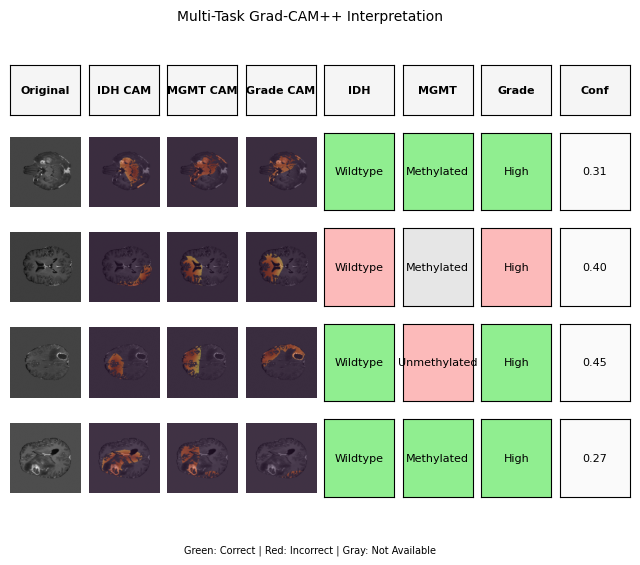

In [34]:
# =========================
# FINAL: MULTI-HEAD GRAD-CAM++
# =========================

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models_dict["resnet50_v2"].to(device)
model.eval()

GREEN = "#90EE90"
RED   = "#FCBABA"
GRAY  = "#e6e6e6"
WHITE = "#fafafa"

cases_to_show = 4

# =========================
# CROP
# =========================
def crop_brain_multi(x, threshold=0.05, pad=5):
    img = x[0].cpu().numpy()
    img = (img - img.min())/(img.max()-img.min()+1e-8)
    mask = img > threshold

    coords = np.argwhere(mask)
    if len(coords)==0:
        return x

    y0,x0 = coords.min(0)
    y1,x1 = coords.max(0)+1

    y0=max(0,y0-pad); x0=max(0,x0-pad)
    y1=min(img.shape[0],y1+pad); x1=min(img.shape[1],x1+pad)

    return x[:,y0:y1,x0:x1]

# =========================
# HOOKS
# =========================
features, gradients = [], []

def fwd_hook(m,i,o):
    features.clear(); features.append(o)

def bwd_hook(m,gi,go):
    gradients.clear(); gradients.append(go[0])

layer = model.backbone.layer4[-1]
h1 = layer.register_forward_hook(fwd_hook)
h2 = layer.register_backward_hook(bwd_hook)

# =========================
# GENERIC GRADCAM++
# =========================
def gradcam_pp(x, head="grade"):
    out_idh, out_mgmt, out_grade = model(x)

    if head=="idh":
        score = torch.sigmoid(out_idh).view(-1)[0]
    elif head=="mgmt":
        score = torch.sigmoid(out_mgmt).view(-1)[0]
    else:
        score = out_grade[0,1]

    model.zero_grad()
    score.backward(retain_graph=True)

    grad = gradients[0]
    fmap = features[0]

    g2 = grad**2
    g3 = grad**3

    alpha = g2 / (2*g2 + torch.sum(fmap*g3, dim=(2,3), keepdim=True)+1e-8)
    w = torch.sum(alpha*F.relu(grad), dim=(2,3), keepdim=True)

    cam = torch.sum(w*fmap, dim=1).squeeze()
    cam = F.relu(cam)
    cam = cam - cam.min()
    cam = cam/(cam.max()+1e-8)

    return cam.detach().cpu().numpy()

# =========================
# CLEAN CAM
# =========================
def clean_cam(cam, img):
    cam = cv2.resize(cam, (img.shape[1], img.shape[0]))
    cam = cv2.GaussianBlur(cam, (15,15), 0)

    th = np.percentile(cam, 85)
    cam = np.where(cam>=th, cam, 0)

    # largest region
    binary = (cam>0).astype(np.uint8)
    num, labels = cv2.connectedComponents(binary)

    if num>1:
        areas = [(labels==i).sum() for i in range(1,num)]
        best = np.argmax(areas)+1
        cam = cam*(labels==best)

    cam = cam/(cam.max()+1e-8)

    mask = (img > np.percentile(img,20)).astype(np.float32)
    return cam*mask

# =========================
# FIGURE
# =========================
fig = plt.figure(figsize=(8,5.6))
gs = fig.add_gridspec(cases_to_show+1, 8,
                      height_ratios=[0.9]+[1.4]*cases_to_show,
                      wspace=0.12, hspace=0.25)

headers = ["Original","IDH CAM","MGMT CAM","Grade CAM","IDH","MGMT","Grade","Conf"]

for j,h in enumerate(headers):
    ax = fig.add_subplot(gs[0,j])
    ax.text(0.5,0.5,h,ha='center',va='center',fontsize=8,weight='semibold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_facecolor("#f5f5f5")

# =========================
# LOOP
# =========================
count=0

for batch in val_loader:
    x=batch[0].to(device)
    labels=batch[1]

    idh=labels["idh"]; mgmt=labels["mgmt"]; grade=labels["grade"]

    for i in range(x.shape[0]):

        if count>=cases_to_show: break
        row=count+1

        img_orig = x[i][1].cpu().numpy()
        img_orig=(img_orig-img_orig.min())/(img_orig.max()-img_orig.min()+1e-8)

        ax=fig.add_subplot(gs[row,0])
        ax.imshow(img_orig,cmap='gray'); ax.axis('off')

        x_crop = crop_brain_multi(x[i])
        x_crop_b = x_crop.unsqueeze(0).to(device)

        img_c = x_crop[1].cpu().numpy()
        img_c=(img_c-img_c.min())/(img_c.max()-img_c.min()+1e-8)

        # --- CAMS ---
        cam_idh = clean_cam(gradcam_pp(x_crop_b,"idh"), img_c)
        cam_mgmt = clean_cam(gradcam_pp(x_crop_b,"mgmt"), img_c)
        cam_grade = clean_cam(gradcam_pp(x_crop_b,"grade"), img_c)

        for k,cam in enumerate([cam_idh, cam_mgmt, cam_grade]):
            ax=fig.add_subplot(gs[row,k+1])
            ax.imshow(img_c,cmap='gray')
            ax.imshow(cam,cmap='turbo',alpha=0.45)
            ax.axis('off')

        # predictions
        out_idh,out_mgmt,out_grade=model(x_crop_b)

        idh_p=int(torch.sigmoid(out_idh)>0.5)
        mgmt_p=int(torch.sigmoid(out_mgmt)>0.5)
        grade_p=int(torch.argmax(out_grade))

        texts=[
            "Mutant" if idh_p else "Wildtype",
            "Methylated" if mgmt_p else "Unmethylated",
            "High" if grade_p else "Low",
            f"{torch.sigmoid(out_idh).item():.2f}"
        ]

        correct=[
            idh_p==idh[i].item(),
            (mgmt[i].item()==-1) or mgmt_p==mgmt[i].item(),
            grade_p==grade[i].item()
        ]

        colors=[
            GREEN if correct[0] else RED,
            GRAY if mgmt[i].item()==-1 else (GREEN if correct[1] else RED),
            GREEN if correct[2] else RED
        ]

        for j in range(4):
            ax=fig.add_subplot(gs[row,j+4])
            ax.text(0.5,0.5,texts[j],ha='center',va='center',fontsize=8)
            ax.set_facecolor(colors[j] if j<3 else WHITE)
            ax.set_xticks([]); ax.set_yticks([])

        count+=1

    if count>=cases_to_show: break

# =========================
# FINAL
# =========================
plt.suptitle("Multi-Task Grad-CAM++ Interpretation", fontsize=10, y=0.98)

fig.text(0.5,0.01,
         "Green: Correct | Red: Incorrect | Gray: Not Available",
         ha='center', fontsize=7)

plt.tight_layout()
plt.savefig("final_multi_head_gradcam.png", dpi=300, bbox_inches='tight')
plt.show()

h1.remove(); h2.remove()

/tmp/ipykernel_55/3352222559.py:220: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


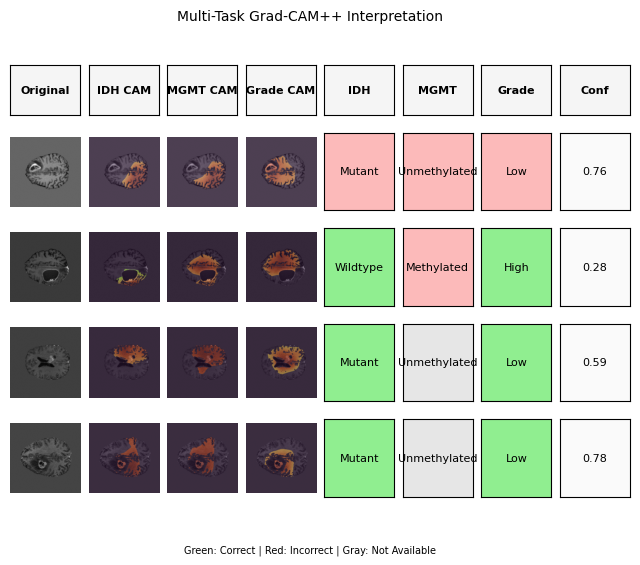

In [37]:
# =========================
# FINAL: RANDOM MULTI-HEAD GRAD-CAM++
# =========================

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import cv2
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models_dict["resnet50_v2"].to(device)
model.eval()

# -------- COLORS --------
GREEN = "#90EE90"
RED   = "#FCBABA"
GRAY  = "#e6e6e6"
WHITE = "#fafafa"

cases_to_show = 4

# =========================
# CROP
# =========================
def crop_brain_multi(x, threshold=0.05, pad=5):
    img = x[0].cpu().numpy()
    img = (img - img.min())/(img.max()-img.min()+1e-8)
    mask = img > threshold

    coords = np.argwhere(mask)
    if len(coords)==0:
        return x

    y0,x0 = coords.min(0)
    y1,x1 = coords.max(0)+1

    y0=max(0,y0-pad); x0=max(0,x0-pad)
    y1=min(img.shape[0],y1+pad); x1=min(img.shape[1],x1+pad)

    return x[:,y0:y1,x0:x1]

# =========================
# HOOKS
# =========================
features, gradients = [], []

def fwd_hook(m,i,o):
    features.clear(); features.append(o)

def bwd_hook(m,gi,go):
    gradients.clear(); gradients.append(go[0])

layer = model.backbone.layer4[-1]
h1 = layer.register_forward_hook(fwd_hook)
h2 = layer.register_backward_hook(bwd_hook)

# =========================
# GRAD-CAM++
# =========================
def gradcam_pp(x, head="grade"):
    out_idh, out_mgmt, out_grade = model(x)

    if head=="idh":
        score = torch.sigmoid(out_idh).view(-1)[0]
    elif head=="mgmt":
        score = torch.sigmoid(out_mgmt).view(-1)[0]
    else:
        score = out_grade[0,1]

    model.zero_grad()
    score.backward(retain_graph=True)

    grad = gradients[0]
    fmap = features[0]

    g2 = grad**2
    g3 = grad**3

    alpha = g2 / (2*g2 + torch.sum(fmap*g3, dim=(2,3), keepdim=True)+1e-8)
    w = torch.sum(alpha*F.relu(grad), dim=(2,3), keepdim=True)

    cam = torch.sum(w*fmap, dim=1).squeeze()
    cam = F.relu(cam)
    cam = cam - cam.min()
    cam = cam/(cam.max()+1e-8)

    return cam.detach().cpu().numpy()

# =========================
# CLEAN CAM
# =========================
def clean_cam(cam, img):
    cam = cv2.resize(cam, (img.shape[1], img.shape[0]))
    cam = cv2.GaussianBlur(cam, (15,15), 0)

    th = np.percentile(cam, 85)
    cam = np.where(cam>=th, cam, 0)

    # largest connected region
    binary = (cam>0).astype(np.uint8)
    num, labels = cv2.connectedComponents(binary)

    if num > 1:
        areas = [(labels==i).sum() for i in range(1,num)]
        best = np.argmax(areas)+1
        cam = cam*(labels==best)

    cam = cam/(cam.max()+1e-8)

    mask = (img > np.percentile(img,20)).astype(np.float32)
    return cam * mask

# =========================
# FIGURE
# =========================
fig = plt.figure(figsize=(8,5.6))
gs = fig.add_gridspec(cases_to_show+1, 8,
                      height_ratios=[0.9]+[1.4]*cases_to_show,
                      wspace=0.12, hspace=0.25)

headers = ["Original","IDH CAM","MGMT CAM","Grade CAM","IDH","MGMT","Grade","Conf"]

for j,h in enumerate(headers):
    ax = fig.add_subplot(gs[0,j])
    ax.text(0.5,0.5,h,ha='center',va='center',fontsize=8,weight='semibold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_facecolor("#f5f5f5")

# =========================
# RANDOM SAMPLING
# =========================
random.seed(42)
indices = random.sample(range(len(val_loader.dataset)), cases_to_show)

# =========================
# LOOP
# =========================
for count, idx in enumerate(indices):

    row = count + 1

    data = val_loader.dataset[idx]
    x = data[0].unsqueeze(0).to(device)
    labels = data[1]

    idh = labels["idh"]
    mgmt = labels["mgmt"]
    grade = labels["grade"]

    # -------- ORIGINAL --------
    img_orig = x[0][1].cpu().numpy()
    img_orig = (img_orig-img_orig.min())/(img_orig.max()-img_orig.min()+1e-8)

    ax = fig.add_subplot(gs[row,0])
    ax.imshow(img_orig,cmap='gray')
    ax.axis('off')

    # -------- CROP --------
    x_crop = crop_brain_multi(x[0])
    x_crop_b = x_crop.unsqueeze(0).to(device)

    img_c = x_crop[1].cpu().numpy()
    img_c = (img_c-img_c.min())/(img_c.max()-img_c.min()+1e-8)

    # -------- CAMS --------
    cam_idh = clean_cam(gradcam_pp(x_crop_b,"idh"), img_c)
    cam_mgmt = clean_cam(gradcam_pp(x_crop_b,"mgmt"), img_c)
    cam_grade = clean_cam(gradcam_pp(x_crop_b,"grade"), img_c)

    for k, cam in enumerate([cam_idh, cam_mgmt, cam_grade]):
        ax = fig.add_subplot(gs[row, k+1])
        ax.imshow(img_c, cmap='gray')
        ax.imshow(cam, cmap='turbo', alpha=0.45)
        ax.axis('off')

    # -------- PREDICTIONS --------
    out_idh, out_mgmt, out_grade = model(x_crop_b)

    idh_p = int(torch.sigmoid(out_idh)>0.5)
    mgmt_p = int(torch.sigmoid(out_mgmt)>0.5)
    grade_p = int(torch.argmax(out_grade))

    texts = [
        "Mutant" if idh_p else "Wildtype",
        "Methylated" if mgmt_p else "Unmethylated",
        "High" if grade_p else "Low",
        f"{torch.sigmoid(out_idh).item():.2f}"
    ]

    correct = [
        idh_p == idh,
        (mgmt==-1) or (mgmt_p==mgmt),
        grade_p == grade
    ]

    colors = [
        GREEN if correct[0] else RED,
        GRAY if mgmt==-1 else (GREEN if correct[1] else RED),
        GREEN if correct[2] else RED
    ]

    for j in range(4):
        ax = fig.add_subplot(gs[row, j+4])
        ax.text(0.5,0.5,texts[j],ha='center',va='center',fontsize=8)
        ax.set_facecolor(colors[j] if j<3 else WHITE)
        ax.set_xticks([]); ax.set_yticks([])

# =========================
# FINAL
# =========================
plt.suptitle("Multi-Task Grad-CAM++ Interpretation", fontsize=10, y=0.98)

fig.text(0.5,0.01,
         "Green: Correct | Red: Incorrect | Gray: Not Available",
         ha='center', fontsize=7)

plt.tight_layout()
plt.savefig("final_random_multi_head_gradcam.png", dpi=300, bbox_inches='tight')
plt.show()

h1.remove(); h2.remove()

/tmp/ipykernel_55/3616117185.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_pred_mgmt.append(int(mgmt_preds[i]))


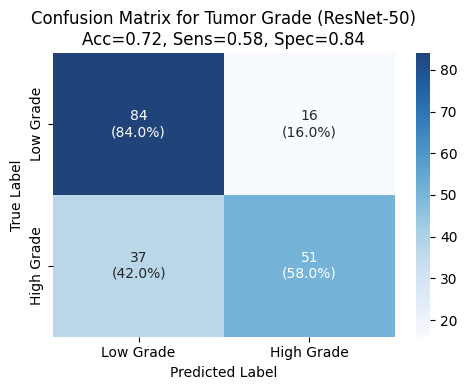

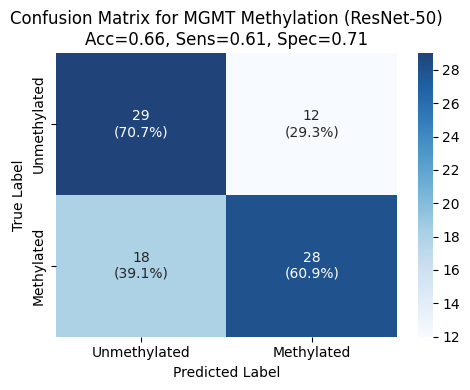

In [38]:
# =========================
# FINAL CONFUSION MATRICES (GRADE + MGMT)
# =========================

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

model = models_dict["resnet50_v2"]
model.eval()

y_true_grade, y_pred_grade = [], []
y_true_mgmt, y_pred_mgmt = [], []

with torch.no_grad():
    for batch in val_loader:

        x = batch[0].to(device)
        labels = batch[1]

        grade = labels["grade"]
        mgmt = labels["mgmt"]

        out_idh, out_mgmt, out_grade = model(x)

        grade_preds = torch.argmax(out_grade, dim=1).cpu().numpy()
        mgmt_preds = (torch.sigmoid(out_mgmt) > 0.5).int().cpu().numpy()

        # -------- STORE GRADE --------
        y_true_grade.extend(grade.numpy())
        y_pred_grade.extend(grade_preds)

        # -------- STORE MGMT (skip -1) --------
        for i in range(len(mgmt)):
            if mgmt[i] != -1:
                y_true_mgmt.append(int(mgmt[i]))
                y_pred_mgmt.append(int(mgmt_preds[i]))


# =========================
# FUNCTION TO PLOT MATRIX
# =========================
def plot_cm(y_true, y_pred, title, labels):

    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm / cm.sum(axis=1, keepdims=True)

    annot = np.array([
        [f"{cm[i,j]}\n({cm_percent[i,j]*100:.1f}%)" for j in range(2)]
        for i in range(2)
    ])

    # metrics
    tp = cm[1,1]
    tn = cm[0,0]
    fp = cm[0,1]
    fn = cm[1,0]

    acc = (tp + tn) / cm.sum()
    sens = tp / (tp + fn + 1e-8)
    spec = tn / (tn + fp + 1e-8)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap="Blues",
        alpha=0.9,
        xticklabels=labels,
        yticklabels=labels
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.title(
        f"{title}\nAcc={acc:.2f}, Sens={sens:.2f}, Spec={spec:.2f}"
    )

    plt.tight_layout()
    plt.show()


# =========================
# PLOT BOTH
# =========================

# Grade
plot_cm(
    y_true_grade,
    y_pred_grade,
    "Confusion Matrix for Tumor Grade (ResNet-50)",
    ["Low Grade", "High Grade"]
)

# MGMT
plot_cm(
    y_true_mgmt,
    y_pred_mgmt,
    "Confusion Matrix for MGMT Methylation (ResNet-50)",
    ["Unmethylated", "Methylated"]
)

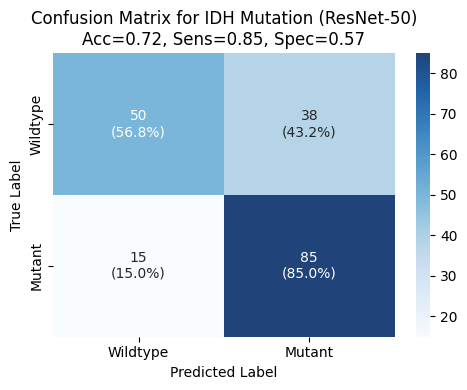

In [40]:
# =========================
# FINAL CONFUSION MATRIX (IDH)
# =========================

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

model = models_dict["resnet50_v2"]
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for batch in val_loader:

        x = batch[0].to(device)
        labels = batch[1]

        idh = labels["idh"]

        out_idh, _, _ = model(x)

        preds = (torch.sigmoid(out_idh) > 0.5).int().cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(idh.numpy())

# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_true, y_pred)

# Normalize
cm_percent = cm / cm.sum(axis=1, keepdims=True)

# Annotate (count + %)
annot = np.array([
    [f"{cm[i,j]}\n({cm_percent[i,j]*100:.1f}%)" for j in range(2)]
    for i in range(2)
])

# =========================
# METRICS
# =========================

tp = cm[1,1]
tn = cm[0,0]
fp = cm[0,1]
fn = cm[1,0]

accuracy = (tp + tn) / cm.sum()
sensitivity = tp / (tp + fn + 1e-8)
specificity = tn / (tn + fp + 1e-8)

# =========================
# PLOT
# =========================

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=annot,
    fmt="",
    cmap="Blues",
    alpha=0.9,
    xticklabels=["Wildtype", "Mutant"],
    yticklabels=["Wildtype", "Mutant"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title(
    f"Confusion Matrix for IDH Mutation (ResNet-50)\n"
    f"Acc={accuracy:.2f}, Sens={sensitivity:.2f}, Spec={specificity:.2f}"
)

plt.tight_layout()
plt.show()

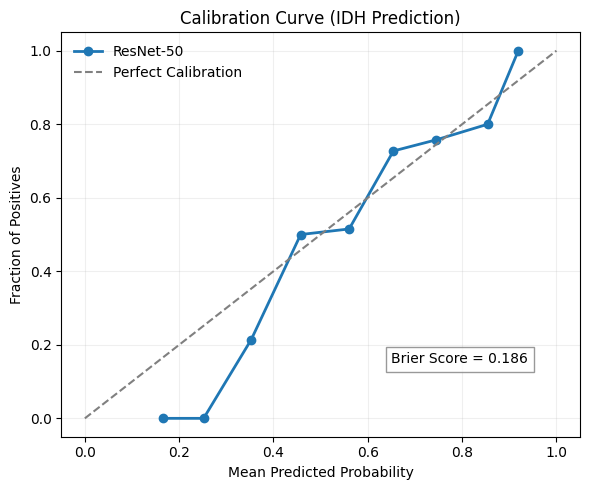

In [41]:
# =========================
# CALIBRATION CURVE (IDH) + BRIER SCORE
# =========================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

model = models_dict["resnet50_v2"]

y_true, y_prob = [], []

model.eval()

with torch.no_grad():
    for batch in val_loader:

        x = batch[0].to(device)
        labels = batch[1]

        idh = labels["idh"]

        out_idh, _, _ = model(x)
        prob = torch.sigmoid(out_idh).squeeze().cpu().numpy()

        y_prob.extend(prob)
        y_true.extend(idh.numpy())

# =========================
# CALIBRATION
# =========================

prob_true, prob_pred = calibration_curve(
    y_true,
    y_prob,
    n_bins=10
)

brier = brier_score_loss(y_true, y_prob)

# =========================
# PLOT
# =========================

plt.figure(figsize=(6,5))

plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label="ResNet-50")

# perfect calibration
plt.plot([0,1], [0,1], linestyle='--', color='gray', label="Perfect Calibration")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve (IDH Prediction)")

# 🔥 BRIER SCORE INSIDE FIGURE
plt.text(
    0.65, 0.15,
    f"Brier Score = {brier:.3f}",
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
)

plt.legend(frameon=False)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

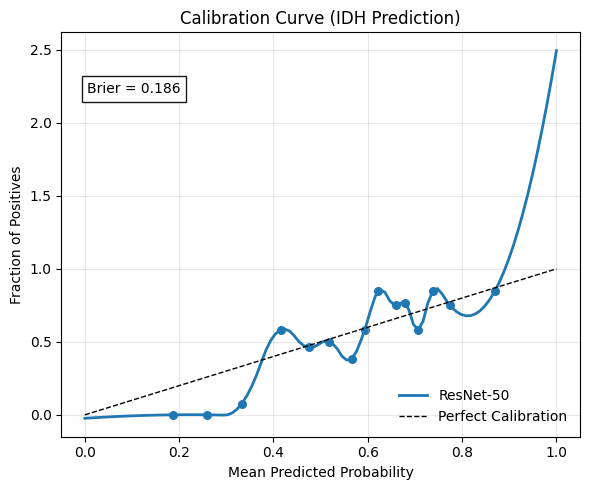

In [42]:
# =========================
# FINAL: CALIBRATION CURVE (IDH) + BRIER + SMOOTHING
# =========================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from scipy.interpolate import make_interp_spline

model = models_dict["resnet50_v2"]

y_true, y_prob = [], []

model.eval()

with torch.no_grad():
    for batch in val_loader:

        x = batch[0].to(device)
        labels = batch[1]

        idh = labels["idh"]

        out_idh, _, _ = model(x)
        prob = torch.sigmoid(out_idh).squeeze().cpu().numpy()

        y_prob.extend(prob)
        y_true.extend(idh.numpy())

# =========================
# CALIBRATION
# =========================

prob_true, prob_pred = calibration_curve(
    y_true,
    y_prob,
    n_bins=15,
    strategy="quantile"   # 🔥 important fix
)

brier = brier_score_loss(y_true, y_prob)

# =========================
# SMOOTH CURVE
# =========================

# Ensure sorted (important for spline)
order = np.argsort(prob_pred)
prob_pred = prob_pred[order]
prob_true = prob_true[order]

x_new = np.linspace(0, 1, 100)

# Handle small bins safely
if len(prob_pred) >= 3:
    spl = make_interp_spline(prob_pred, prob_true, k=2)
    y_smooth = spl(x_new)
else:
    x_new, y_smooth = prob_pred, prob_true

# =========================
# PLOT
# =========================

plt.figure(figsize=(6,5))

# smoothed model curve
plt.plot(x_new, y_smooth, linewidth=2, label="ResNet-50")

# actual points
plt.scatter(prob_pred, prob_true, s=30)

# perfect calibration
plt.plot([0,1], [0,1], linestyle='--', color='black', linewidth=1, label="Perfect Calibration")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve (IDH Prediction)")

# 🔥 BRIER SCORE (top-left, clean)
plt.text(
    0.05, 0.85,
    f"Brier = {brier:.3f}",
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.9, edgecolor='black')
)

plt.legend(frameon=False)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

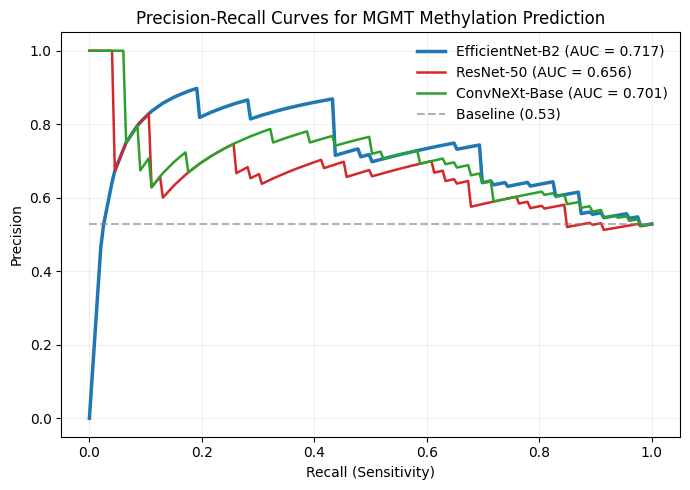

In [43]:
# =========================
# FINAL PR CURVE (MGMT - POLISHED)
# =========================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

plt.figure(figsize=(7,5))

name_map = {
    "efficientnet_b2": "EfficientNet-B2",
    "resnet50_v2": "ResNet-50",
    "convnext_base": "ConvNeXt-Base"
}

colors = {
    "efficientnet_b2": "tab:blue",
    "resnet50_v2": "tab:red",
    "convnext_base": "tab:green"
}

recall_grid = np.linspace(0, 1, 200)

all_targets = []

# =========================
# MODEL CURVES
# =========================

for name, model in models_dict.items():

    if name not in name_map:
        continue

    y_true, y_score = [], []

    model.eval()

    with torch.no_grad():
        for batch in val_loader:

            x = batch[0].to(device)
            labels = batch[1]

            mgmt = labels["mgmt"]

            _, out_mgmt, _ = model(x)
            prob = torch.sigmoid(out_mgmt).squeeze().cpu().numpy()

            mgmt_np = mgmt.numpy()
            mask = mgmt_np != -1

            y_true.extend(mgmt_np[mask])
            y_score.extend(prob[mask])

    all_targets.extend(y_true)

    precision, recall, _ = precision_recall_curve(y_true, y_score)
    pr_auc = auc(recall, precision)

    # smoothing (light, safe)
    precision_smooth = np.interp(recall_grid, recall[::-1], precision[::-1])

    plt.plot(
        recall_grid,
        precision_smooth,
        color=colors[name],
        linewidth=2.5 if name=="efficientnet_b2" else 1.8,
        label=f"{name_map[name]} (AUC = {pr_auc:.3f})"
    )

# =========================
# BASELINE (IMBALANCE)
# =========================

baseline = np.mean(all_targets)

plt.hlines(
    baseline,
    0, 1,
    linestyles="dashed",
    colors="gray",
    alpha=0.6,   # 🔥 lighter baseline (your request)
    linewidth=1.5,
    label=f"Baseline ({baseline:.2f})"
)

# =========================
# FINAL STYLING
# =========================

plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves for MGMT Methylation Prediction")

plt.legend(frameon=False)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

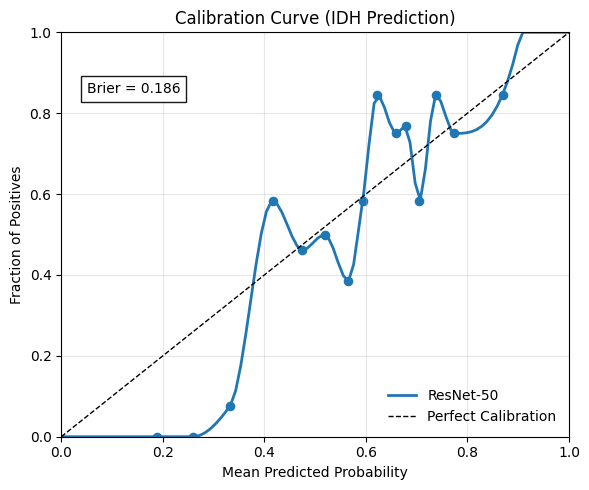

In [44]:
# =========================
# FINAL: CALIBRATION CURVE (IDH) — STABLE VERSION
# =========================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from scipy.interpolate import PchipInterpolator

model = models_dict["resnet50_v2"]

y_true, y_prob = [], []

model.eval()

with torch.no_grad():
    for batch in val_loader:

        x = batch[0].to(device)
        labels = batch[1]

        idh = labels["idh"]

        out_idh, _, _ = model(x)
        prob = torch.sigmoid(out_idh).squeeze().cpu().numpy()

        y_prob.extend(prob)
        y_true.extend(idh.numpy())

# =========================
# CALIBRATION
# =========================

prob_true, prob_pred = calibration_curve(
    y_true,
    y_prob,
    n_bins=15,
    strategy="quantile"   # important for stability
)

brier = brier_score_loss(y_true, y_prob)

# =========================
# SORT (required for interpolation)
# =========================

order = np.argsort(prob_pred)
prob_pred = prob_pred[order]
prob_true = prob_true[order]

# =========================
# SAFE SMOOTHING (PCHIP)
# =========================

x_new = np.linspace(0, 1, 100)

if len(prob_pred) >= 3:
    interp = PchipInterpolator(prob_pred, prob_true)
    y_smooth = interp(x_new)
    y_smooth = np.clip(y_smooth, 0, 1)   # 🔥 prevent invalid values
else:
    x_new, y_smooth = prob_pred, prob_true

# =========================
# PLOT
# =========================

plt.figure(figsize=(6,5))

# smoothed curve
plt.plot(x_new, y_smooth, linewidth=2, label="ResNet-50")

# actual calibration points
plt.scatter(prob_pred, prob_true, s=35)

# perfect calibration
plt.plot([0,1], [0,1], linestyle='--', color='black', linewidth=1, label="Perfect Calibration")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve (IDH Prediction)")

# 🔥 BRIER SCORE (clean placement)
plt.text(
    0.05, 0.85,
    f"Brier = {brier:.3f}",
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.9, edgecolor='black')
)

# 🔥 IMPORTANT: VALID AXIS
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.legend(frameon=False)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()